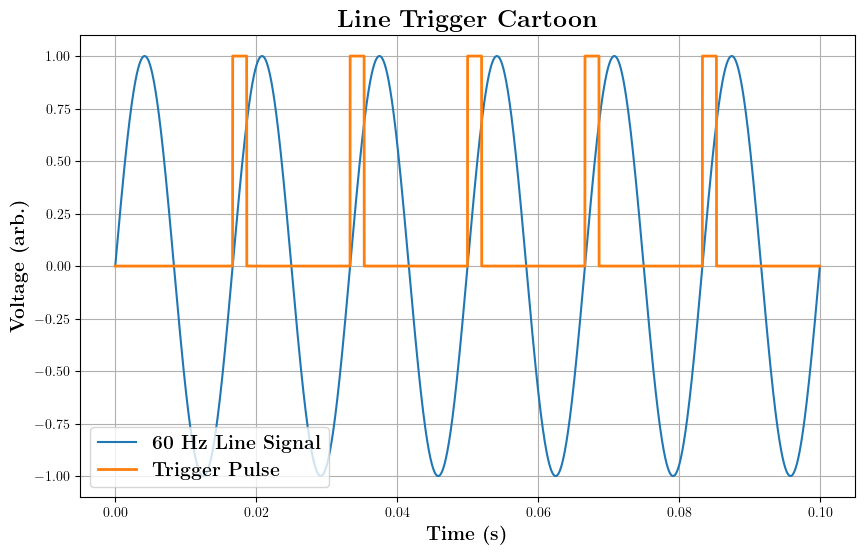

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import rcParams


rcParams['font.family'] = 'serif'
rcParams['font.serif'] = ['Computer Modern']
rcParams['text.usetex'] = True
rcParams['text.latex.preamble'] = r'\usepackage{amsmath}'

fs = 100000         
duration = 0.1  
f_line = 60         
pulse_width = 0.002  


t = np.linspace(0, duration, int(fs * duration), endpoint=False)

line_signal = np.sin(2 * np.pi * f_line * t)


zero_crossings = np.where(
    (line_signal[:-1] < 0) & (line_signal[1:] >= 0)
)[0]


trigger = np.zeros_like(t)
pulse_samples = int(pulse_width * fs)

for idx in zero_crossings:
    trigger[idx:idx + pulse_samples] = 1


plt.figure(figsize=(10, 6))

plt.plot(t, line_signal, label=r"\textbf{60 Hz Line Signal}")
plt.plot(t, trigger, label=r"\textbf{Trigger Pulse}", linewidth=2)

plt.xlabel(r"\textbf{Time (s)}", fontsize = 14)
plt.ylabel(r"\textbf{Voltage (arb.)}", fontsize = 14)
plt.title(r"\textbf{Line Trigger Cartoon}", fontsize = 18)
plt.legend(fontsize = 14)
plt.grid(True)

plt.show()


In [2]:
import numpy as np
import io

def load_line_fit_parameters(filename):
    B0_fit = None
    B0_err = None
    harmonic_lines = []
    with open(filename, "r") as f:
        for line in f:
            stripped = line.strip()
            if not stripped or stripped.startswith("#"):
                continue
            if B0_fit is None:
                vals = np.fromstring(stripped, sep=" ")
                B0_fit, B0_err = vals[0], vals[1]
            else:
                harmonic_lines.append(stripped)
    harmonics = np.loadtxt(io.StringIO("\n".join(harmonic_lines)))
    if harmonics.ndim == 1:
        harmonics = harmonics[None, :]
    freqs = harmonics[:, 0]
    A_vals = harmonics[:, 1]
    A_errs = harmonics[:, 2]
    phi_vals = harmonics[:, 3]
    phi_errs = harmonics[:, 4]
    return B0_fit, B0_err, freqs, A_vals, A_errs, phi_vals, phi_errs

def _get_line_params(param_file, B0, A60, phi60, A180, phi180):
    if param_file is not None:
        B0_fit, B0_err, freqs, A_vals, A_errs, phi_vals, phi_errs = load_line_fit_parameters(param_file)
        return B0_fit, freqs, A_vals, phi_vals
    freqs = np.array([60.0, 180.0], dtype=float)
    A_vals = np.array([A60, A180], dtype=float)
    phi_vals = np.array([phi60, phi180], dtype=float)
    return B0, freqs, A_vals, phi_vals
# B0 = 0.3350, A60 = -0.3204, phi60 = 0.7425, A180 = -0.0978, phi180 = -0.5812,
def B_line_mG(t, B0 = 0.3350, A60 = -0.3204, phi60 = 0.7425, A180 = -0.0978, phi180 = -0.5812, param_file = 'Z:\Lab Data\Line_signal_fitted_params\line_signal_fit_params.txt'):
    B0_use, freqs, A_vals, phi_vals = _get_line_params(param_file, B0, A60, phi60, A180, phi180)
    t_arr = np.asarray(t, dtype=float)
    y = np.full_like(t_arr, B0_use, dtype=float)
    for f, A, phi in zip(freqs, A_vals, phi_vals):
        y = y + A * np.cos(2.0 * np.pi * f * t_arr + phi)
    return y

def B_rel_line_mG(t):
    return B_line_mG(t) - B_line_mG(0)

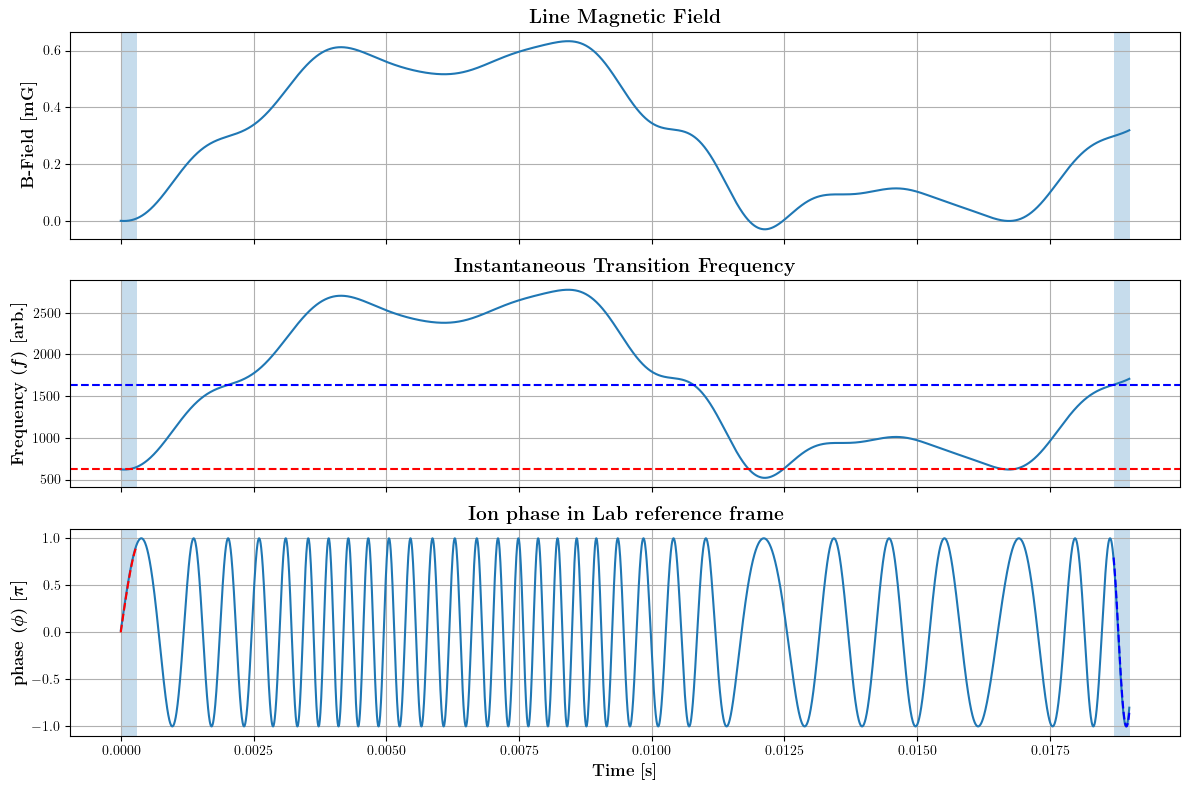

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import integrate
from matplotlib import rcParams

rcParams['font.family'] = 'serif'
rcParams['font.serif'] = ['Computer Modern']
rcParams['text.usetex'] = True
rcParams['text.latex.preamble'] = r'\usepackage{amsmath}'

fs = 200000
duration = 19000e-6
f0 = 623.3
gamma = 3.4e3
pulse_width = 300e-6
t = np.linspace(0, duration, int(fs * duration), endpoint=False)

B_t = B_rel_line_mG(t)
# B_t = 0*np.linspace(0, duration, int(fs * duration), endpoint=False)

delta_t = gamma * B_t
f_inst = f0 + delta_t


phase = 2 * np.pi * np.cumsum(f_inst) / fs
signal = np.sin(phase)


pulse1_start = 0
pulse1_end = pulse_width

pulse2_start = duration - pulse_width
pulse2_end = duration

f_LO1 = f_inst[0]                 
f_LO2 = f0 + gamma*B_rel_line_mG(pulse2_start)##f_inst[-1]             

LO1 = np.zeros_like(t)
LO2 = np.zeros_like(t)
LO_dummy = np.zeros_like(t)
mask1 = (t >= pulse1_start) & (t <= pulse1_end)
mask2 = (t >= pulse2_start) & (t <= pulse2_end)
mask_dummy1 = (t >= pulse1_end) & (t <= pulse2_start)
mask_dummy2 = (t >= 0) & (t <= pulse2_start)

# LO1[mask1] = np.sin(2 * np.pi * f_LO1 * t[mask1] + 0)
# LO2[mask2] = np.sin(2 * np.pi * f_LO2 * t[mask2] + 0*2*np.pi*integrate.quad(B_rel_line_mG, 0, pulse2_start)[0]*gamma - 2*np.pi*(f_LO2 - f_LO1)*pulse2_start)#2*np.pi*(f_LO2 - f_LO1)*pulse2_start - 2*np.pi*f_LO2*pulse2_start)
# LO_dummy[mask_dummy] = np.sin(2 * np.pi * f_LO1 * t[mask_dummy] + 0)

LO1 = np.sin(2 * np.pi * f_LO1 * t[mask1] + 0)
LO2 = np.sin(2 * np.pi * f_LO2 * t[mask2] + 2*np.pi*integrate.quad(B_rel_line_mG, 0, pulse2_start)[0]*gamma - 1*2*np.pi*(f_LO2 - f_LO1)*pulse2_start)#2*np.pi*(f_LO2 - f_LO1)*pulse2_start - 2*np.pi*f_LO2*pulse2_start)
LO_dummy1 = np.sin(2 * np.pi * f_LO1 * t[mask_dummy1] + 0)
LO_dummy2 = np.sin(2 * np.pi * f_LO2 * t[mask_dummy2] + 0)

fig, axs = plt.subplots(3, 1, figsize=(12, 8), sharex=True)


axs[0].plot(t, B_t)
axs[0].set_title(r"\textbf{Line Magnetic Field}", fontsize = 14)
axs[0].set_ylabel(r"\textbf{B-Field [mG]}", fontsize = 12)
axs[0].grid(True)

axs[1].plot(t, f_inst)
axs[1].axhline(f_LO1, linestyle='--', color = 'red')
axs[1].axhline(f_LO2, linestyle='--', color = 'blue')
axs[1].set_title(r"\textbf{Instantaneous Transition Frequency}", fontsize = 14)
axs[1].set_ylabel(r"\textbf{Frequency (\boldmath$f$) [arb.]}",  fontsize = 12)
axs[1].grid(True)

axs[2].plot(t, signal, label="Ion (Chirped)")
axs[2].plot(t[mask1], LO1, linestyle='--', label="LO @ first pulse", color = 'red')
axs[2].plot(t[mask2], LO2, linestyle='--', label="LO @ second pulse", color = 'blue')
# axs[2].plot(t[mask_dummy1], LO_dummy1, linestyle='--',  color = 'red', linewidth=0.75)
# axs[2].plot(t[mask_dummy2], LO_dummy2, linestyle='--',  color = 'blue', linewidth=0.75)
axs[2].set_title(r"\textbf{Ion phase in Lab reference frame}", fontsize = 14)
axs[2].set_xlabel(r"\textbf{Time [s]}", fontsize = 12)
axs[2].set_ylabel(r"\textbf{phase (\boldmath$\phi$) [\boldmath$\pi$]}", fontsize = 12)
axs[2].grid(True)
# axs[2].legend()


for ax in axs:
    ax.axvspan(pulse1_start, pulse1_end, alpha=0.25)
    ax.axvspan(pulse2_start, pulse2_end, alpha=0.25)

plt.tight_layout()
plt.show()


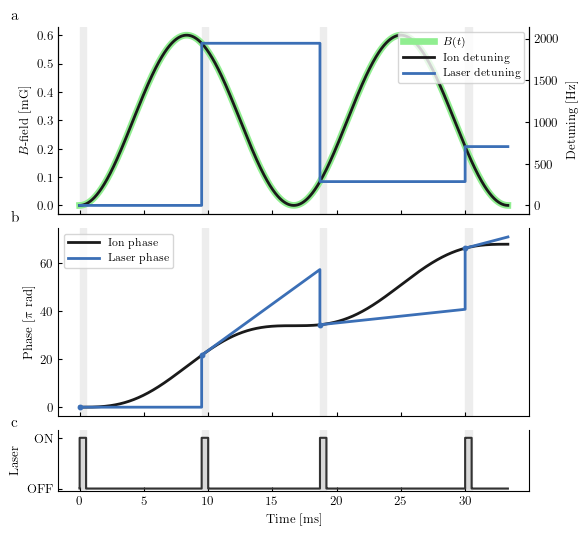

In [4]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import cumulative_trapezoid
from matplotlib import rcParams

rcParams.update({
    "font.family": "serif",
    "font.serif": ["Computer Modern Roman"],
    "text.usetex": True,
    "text.latex.preamble": r"\usepackage{amsmath}",
    "font.size": 9,
    "axes.linewidth": 0.8,
    "xtick.direction": "in",
    "ytick.direction": "in",
    "xtick.major.size": 3,
    "ytick.major.size": 3,
    "xtick.major.width": 0.8,
    "ytick.major.width": 0.8,
    "savefig.dpi": 300,
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
})


fs = 200000
duration = 33330e-6
f0 = 623.3
gamma = 3.4e3   # Hz / mG

pulse_times = np.array([
    0.01e-6,
    9500e-6,
    18700e-6,
    30000e-6,
], dtype=float)


pulse_width = 300e-6

pulse_width = np.array([500e-6, 500e-6, 500e-6, 500e-6], dtype=float)

first_update_index = 1

if np.isscalar(pulse_width):
    pulse_widths = np.full(len(pulse_times), pulse_width, dtype=float)
else:
    pulse_widths = np.asarray(pulse_width, dtype=float)
    if len(pulse_widths) != len(pulse_times):
        raise ValueError("pulse_width array must have the same length as pulse_times.")

pulse_ends = pulse_times + pulse_widths

if np.any(np.diff(pulse_times) < 0):
    raise ValueError("pulse_times must be sorted in increasing order.")

if np.any(pulse_ends > duration):
    raise ValueError("A pulse ends after the total sequence duration.")

t = np.linspace(0, duration, int(fs * duration), endpoint=False)
t_ms = 1e3 * t


B_t = B_rel_line_mG(t)          # [mG]
B_t = -0.3 * np.cos(2 * np.pi * 60 * t) + 0.3 
B_t = B_t - B_t[0]
delta_ion = gamma * B_t         # ion detuning [Hz]
phi_ion = 2 * np.pi * cumulative_trapezoid(delta_ion, t, initial=0)   # [rad]

delta_pulses = np.interp(pulse_times, t, delta_ion)
phi_pulses = np.interp(pulse_times, t, phi_ion)

laser_detuning = np.zeros_like(t)

for j in range(first_update_index, len(pulse_times)):
    t0 = pulse_times[j]
    t1 = pulse_times[j + 1] if j + 1 < len(pulse_times) else duration
    mask = (t >= t0) & (t < t1 if j + 1 < len(pulse_times) else t <= t1)
    laser_detuning[mask] = delta_pulses[j]

phase_t_plot = [0.0]
phase_laser_plot = [0.0]

current_t = 0.0
current_phi = 0.0
current_detuning = 0.0  

update_times = pulse_times[first_update_index:]

for k, t_update in enumerate(update_times):

    phi_before = current_phi + 2 * np.pi * current_detuning * (t_update - current_t)

    phase_t_plot.extend([t_update])
    phase_laser_plot.extend([phi_before])

    pulse_idx = first_update_index + k
    phi_snap = phi_pulses[pulse_idx]

    phase_t_plot.extend([t_update])
    phase_laser_plot.extend([phi_snap])

    current_t = t_update
    current_phi = phi_snap
    current_detuning = delta_pulses[pulse_idx]

phi_end = current_phi + 2 * np.pi * current_detuning * (duration - current_t)
phase_t_plot.extend([duration])
phase_laser_plot.extend([phi_end])

phase_t_plot = 1e3 * np.array(phase_t_plot)      # ms
phase_laser_plot = np.array(phase_laser_plot)    # rad

laser_on = np.zeros_like(t)
for t0, t1 in zip(pulse_times, pulse_ends):
    laser_on[(t >= t0) & (t < t1)] = 1

c_B = "0.65"
c_ion = "0.10"
c_laser = "#3B6FB6"


fig, axs = plt.subplots(
    3, 1,
    figsize=(6.2, 5.4),
    sharex=True,
    gridspec_kw={"height_ratios": [2.0, 2.0, 0.65]}
)

ax = axs[0]
ax_r = ax.twinx()

ax.plot(t_ms, B_t, color='lightgreen', lw=4.8, label=r"$B(t)$")
ax_r.plot(t_ms, delta_ion, color=c_ion, lw=2.0, label=r"Ion detuning")
ax_r.step(t_ms, laser_detuning, where="post", color=c_laser, lw=2.0, label=r"Laser detuning")

ax.set_ylabel(r"$B$-field [mG]")
ax_r.set_ylabel(r"Detuning [Hz]")

lines = ax.get_lines() + ax_r.get_lines()
labels = [line.get_label() for line in lines]
ax_r.legend(lines, labels, loc="upper right", frameon=True, fontsize=8, handlelength=2.8)

ax = axs[1]
ax.plot(t_ms, phi_ion / np.pi, color=c_ion, lw=2.0, label=r"Ion phase")
ax.plot(phase_t_plot, phase_laser_plot / np.pi, color=c_laser, lw=2.0, label=r"Laser phase")

ax.plot(1e3 * pulse_times, phi_pulses / np.pi, "o", color=c_laser, ms=3.2)

ax.set_ylabel(r"Phase [$\pi$ rad]")
ax.legend(loc="upper left", frameon=True, fontsize=8, handlelength=2.8)

ax = axs[2]
ax.step(t_ms, laser_on, where="post", color="0.2", lw=1.5)
ax.fill_between(t_ms, 0, laser_on, step="post", color="0.85")

ax.set_ylim(-0.05, 1.15)
ax.set_yticks([0, 1])
ax.set_yticklabels([r"OFF", r"ON"])
ax.set_ylabel(r"Laser")
ax.set_xlabel(r"Time [ms]")

for i, ax in enumerate(axs):
    for t0, t1 in zip(pulse_times, pulse_ends):
        ax.axvspan(1e3 * t0, 1e3 * t1, color="0.93", zorder=0)

    ax.spines["top"].set_visible(False)
    ax.text(
        -0.10, 1.02, chr(ord("a") + i),
        transform=ax.transAxes,
        fontsize=11,
        fontweight="bold",
        va="bottom"
    )

ax_r.spines["top"].set_visible(False)

plt.subplots_adjust(left=0.12, right=0.88, top=0.97, bottom=0.11, hspace=0.10)
plt.savefig("Line_signal_Compensation_Figure1_explanation.pdf")
plt.show()

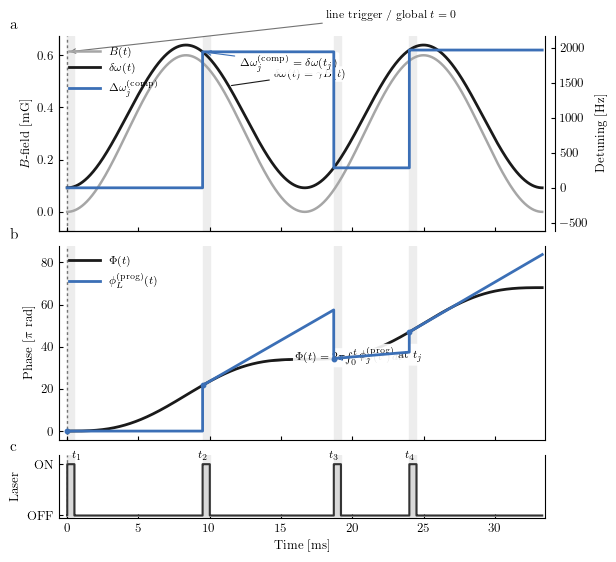

In [5]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import cumulative_trapezoid
from matplotlib import rcParams

rcParams.update({
    "font.family": "serif",
    "font.serif": ["Computer Modern Roman"],
    "text.usetex": True,
    "text.latex.preamble": r"\usepackage{amsmath}",
    "font.size": 9,
    "axes.linewidth": 0.8,
    "xtick.direction": "in",
    "ytick.direction": "in",
    "xtick.major.size": 3,
    "ytick.major.size": 3,
    "xtick.major.width": 0.8,
    "ytick.major.width": 0.8,
    "savefig.dpi": 300,
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
})

# -----------------------
# Parameters
# -----------------------
fs = 200000
duration = 33330e-6
f0 = 623.3
gamma = 3.4e3   # Hz / mG

pulse_times = np.array([
    0.01e-6,
    9500e-6,
    18700e-6,
    24000e-6,
], dtype=float)

pulse_width = np.array([500e-6, 500e-6, 500e-6, 500e-6], dtype=float)

# first pulse is reference; compensation updates start from next pulse
first_update_index = 1

# -----------------------
# Helpers
# -----------------------
def padded_limits(y, low_pad=0.10, high_pad=0.10):
    y = np.asarray(y)
    ymin = np.min(y)
    ymax = np.max(y)
    span = ymax - ymin
    if np.isclose(span, 0):
        span = max(abs(ymax), 1.0)
    return ymin - low_pad * span, ymax + high_pad * span

label_box = dict(boxstyle="round,pad=0.20", fc="white", ec="none", alpha=0.9)

# -----------------------
# Pulse checks
# -----------------------
if np.isscalar(pulse_width):
    pulse_widths = np.full(len(pulse_times), pulse_width, dtype=float)
else:
    pulse_widths = np.asarray(pulse_width, dtype=float)
    if len(pulse_widths) != len(pulse_times):
        raise ValueError("pulse_width array must have the same length as pulse_times.")

pulse_ends = pulse_times + pulse_widths

if np.any(np.diff(pulse_times) < 0):
    raise ValueError("pulse_times must be sorted in increasing order.")

if np.any(pulse_ends > duration):
    raise ValueError("A pulse ends after the total sequence duration.")

# -----------------------
# Time axis
# -----------------------
t = np.linspace(0, duration, int(fs * duration), endpoint=False)
t_ms = 1e3 * t

# -----------------------
# Field, detuning, phase
# -----------------------
# B_t = B_rel_line_mG(t)
B_t = -0.3 * np.cos(2 * np.pi * 60 * t) + 0.3
B_t = B_t - B_t[0]

delta_ion = gamma * B_t                                # Hz
phi_ion = 2 * np.pi * cumulative_trapezoid(delta_ion, t, initial=0)   # rad

delta_pulses = np.interp(pulse_times, t, delta_ion)
phi_pulses = np.interp(pulse_times, t, phi_ion)

# -----------------------
# Piecewise laser detuning
# -----------------------
laser_detuning = np.zeros_like(t)

for j in range(first_update_index, len(pulse_times)):
    t0 = pulse_times[j]
    t1 = pulse_times[j + 1] if j + 1 < len(pulse_times) else duration
    if j + 1 < len(pulse_times):
        mask = (t >= t0) & (t < t1)
    else:
        mask = (t >= t0) & (t <= t1)
    laser_detuning[mask] = delta_pulses[j]

# -----------------------
# Piecewise laser phase
# -----------------------
phase_t_plot = [0.0]
phase_laser_plot = [0.0]

current_t = 0.0
current_phi = 0.0
current_detuning = 0.0

update_times = pulse_times[first_update_index:]

for k, t_update in enumerate(update_times):
    phi_before = current_phi + 2 * np.pi * current_detuning * (t_update - current_t)

    phase_t_plot.extend([t_update])
    phase_laser_plot.extend([phi_before])

    pulse_idx = first_update_index + k
    phi_snap = phi_pulses[pulse_idx]

    phase_t_plot.extend([t_update])
    phase_laser_plot.extend([phi_snap])

    current_t = t_update
    current_phi = phi_snap
    current_detuning = delta_pulses[pulse_idx]

phi_end = current_phi + 2 * np.pi * current_detuning * (duration - current_t)
phase_t_plot.extend([duration])
phase_laser_plot.extend([phi_end])

phase_t_plot = 1e3 * np.array(phase_t_plot)   # ms
phase_laser_plot = np.array(phase_laser_plot) # rad

# -----------------------
# Laser ON/OFF
# -----------------------
laser_on = np.zeros_like(t)
for t0, t1 in zip(pulse_times, pulse_ends):
    laser_on[(t >= t0) & (t < t1)] = 1

# -----------------------
# Colors
# -----------------------
c_B = "0.65"
c_ion = "0.10"
c_laser = "#3B6FB6"
c_trigger = "0.45"

# -----------------------
# Plot
# -----------------------
fig, axs = plt.subplots(
    3, 1,
    figsize=(6.4, 5.6),
    sharex=True,
    gridspec_kw={"height_ratios": [2.0, 2.0, 0.65]}
)

# -------- Panel 1 --------
ax = axs[0]
ax_r = ax.twinx()

ax.plot(t_ms, B_t, color=c_B, lw=1.8, label=r"$B(t)$", zorder=2)
ax_r.plot(
    t_ms, delta_ion, color=c_ion, lw=2.0,
    label=r"$\delta\omega(t)$", zorder=3
)
ax_r.step(
    t_ms, laser_detuning, where="post", color=c_laser, lw=2.0,
    label=r"$\Delta\omega_j^{(\mathrm{comp})}$", zorder=4
)

# left axis: standard padding
ax.set_ylim(*padded_limits(B_t, low_pad=0.12, high_pad=0.12))

# right axis: asymmetric padding to visually separate proportional traces
ax_r.set_ylim(*padded_limits(delta_ion, low_pad=0.30, high_pad=0.06))
ax_r.spines["right"].set_position(("outward", 7))

ax.set_ylabel(r"$B$-field [mG]")
ax_r.set_ylabel(r"Detuning [Hz]")

lines = ax.get_lines() + ax_r.get_lines()
labels = [line.get_label() for line in lines]
ax_r.legend(lines, labels, loc="upper left", frameon=False, fontsize=8, handlelength=2.8)

# Representative annotations
idx_det = int(0.34 * len(t))
ax_r.annotate(
    r"$\delta\omega(t)=\gamma B(t)$",
    xy=(t_ms[idx_det], delta_ion[idx_det]),
    xytext=(t_ms[idx_det] + 3.2, delta_ion[idx_det] + 130),
    arrowprops=dict(arrowstyle="-", lw=0.8, color=c_ion),
    fontsize=8,
    bbox=label_box,
)

if first_update_index < len(pulse_times):
    j0 = first_update_index
    ax_r.annotate(
        r"$\Delta\omega_j^{(\mathrm{comp})}=\delta\omega(t_j)$",
        xy=(1e3 * pulse_times[j0], delta_pulses[j0]),
        xytext=(1e3 * pulse_times[j0] + 2.6, delta_pulses[j0] - 210),
        arrowprops=dict(arrowstyle="->", lw=0.8, color=c_laser),
        fontsize=8,
        bbox=label_box,
    )

# -------- Panel 2 --------
ax = axs[1]
ax.plot(
    t_ms, phi_ion / np.pi, color=c_ion, lw=2.0,
    label=r"$\Phi(t)$", zorder=3
)
ax.plot(
    phase_t_plot, phase_laser_plot / np.pi, color=c_laser, lw=2.0,
    label=r"$\phi_L^{(\mathrm{prog})}(t)$", zorder=4
)
ax.plot(1e3 * pulse_times, phi_pulses / np.pi, "o", color=c_laser, ms=3.2, zorder=5)

ax.set_ylabel(r"Phase [$\pi$ rad]")
ax.legend(loc="upper left", frameon=False, fontsize=8, handlelength=2.8)

idx_phi = int(0.42 * len(t))
ax.annotate(
    r"$\Phi(t)=2\pi\!\int_0^t \delta\omega(t')\,dt'$",
    xy=(t_ms[idx_phi], phi_ion[idx_phi] / np.pi),
    xytext=(t_ms[idx_phi] + 2.0, phi_ion[idx_phi] / np.pi + 0.10),
    arrowprops=dict(arrowstyle="-", lw=0.8, color=c_ion),
    fontsize=8,
    bbox=label_box,
)

if first_update_index < len(pulse_times):
    j1 = min(first_update_index + 1, len(pulse_times) - 1)
    ax.annotate(
        r"$\phi_j^{(\mathrm{prog})}$ at $t_j$",
        xy=(1e3 * pulse_times[j1], phi_pulses[j1] / np.pi),
        xytext=(1e3 * pulse_times[j1] + 1.8, phi_pulses[j1] / np.pi + 0.18),
        arrowprops=dict(arrowstyle="->", lw=0.8, color=c_laser),
        fontsize=8,
        bbox=label_box,
    )

# -------- Panel 3 --------
ax = axs[2]
ax.step(t_ms, laser_on, where="post", color="0.2", lw=1.5, zorder=3)
ax.fill_between(t_ms, 0, laser_on, step="post", color="0.85", zorder=2)

ax.set_ylim(-0.05, 1.18)
ax.set_yticks([0, 1])
ax.set_yticklabels([r"OFF", r"ON"])
ax.set_ylabel(r"Laser")
ax.set_xlabel(r"Time [ms]")

# pulse-time labels
for j, t0 in enumerate(pulse_times[1:], start=2):
    ax.text(1e3 * t0, 1.07, rf"$t_{{{j}}}$", ha="center", va="bottom", fontsize=8)

# keep first pulse label off to avoid overlap with trigger label
ax.text(1e3 * pulse_times[0] + 0.35, 1.07, r"$t_1$", ha="left", va="bottom", fontsize=8)

# -----------------------
# Shared styling
# -----------------------
for i, ax in enumerate(axs):
    for t0, t1 in zip(pulse_times, pulse_ends):
        ax.axvspan(1e3 * t0, 1e3 * t1, color="0.93", zorder=0)

    # global line-trigger reference
    ax.axvline(0.0, color=c_trigger, lw=1.0, linestyle=(0, (2, 2)), zorder=1)

    ax.spines["top"].set_visible(False)
    ax.text(
        -0.10, 1.02, chr(ord("a") + i),
        transform=ax.transAxes,
        fontsize=11,
        fontweight="bold",
        va="bottom"
    )

axs[0].annotate(
    r"line trigger / global $t=0$",
    xy=(0.0, 0.92),
    xycoords=("data", "axes fraction"),
    xytext=(0.55, 1.08),
    textcoords=("axes fraction", "axes fraction"),
    arrowprops=dict(arrowstyle="->", lw=0.8, color=c_trigger),
    fontsize=8,
    ha="left",
    va="bottom",
    bbox=label_box,
)

ax_r.spines["top"].set_visible(False)

# a little room to the left so the t=0 trigger is visually obvious
for ax in axs:
    ax.set_xlim(-0.6, t_ms[-1] + 0.2)

plt.subplots_adjust(left=0.12, right=0.88, top=0.97, bottom=0.11, hspace=0.10)
plt.savefig("Line_signal_Compensation_Figure1_explanation.pdf", bbox_inches="tight")
plt.show()

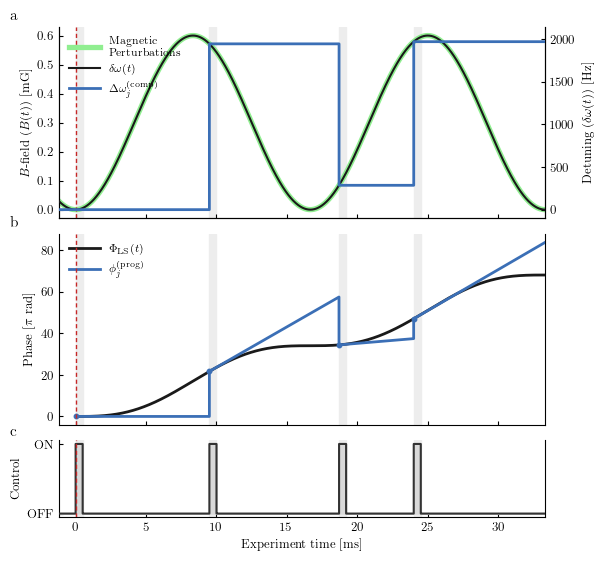

In [6]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import cumulative_trapezoid
from matplotlib import rcParams

rcParams.update({
    "font.family": "serif",
    "font.serif": ["Computer Modern Roman"],
    "text.usetex": True,
    "text.latex.preamble": r"\usepackage{amsmath}",
    "font.size": 9,
    "axes.linewidth": 0.8,
    "xtick.direction": "in",
    "ytick.direction": "in",
    "xtick.major.size": 3,
    "ytick.major.size": 3,
    "xtick.major.width": 0.8,
    "ytick.major.width": 0.8,
    "savefig.dpi": 300,
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
})

# =========================================================
# TOGGLES / USER SETTINGS
# =========================================================
SHOW_ANNOTATIONS = False   # set True to show theory labels / arrows
USE_TOY_BFIELD = True      # set False to use B_rel_line_mG(...)
SHOW_LINE_TRIGGER = False
# extra time shown before t=0 (for B-field + detuning + trigger only)
pre_trigger_duration = 1.2e-3   # [s]

# line trigger pulse shown in red in last panel
trigger_width = 0.35e-3         # [s]

# =========================================================
# PARAMETERS
# =========================================================
fs = 200000
duration = 33330e-6
f0 = 623.3
gamma = 3.4e3   # Hz / mG   (plays the role of \kappa in the theory text)

pulse_times = np.array([
    0.01e-6,
    9500e-6,
    18700e-6,
    24000e-6,
], dtype=float)

pulse_width = np.array([500e-6, 500e-6, 500e-6, 500e-6], dtype=float)

# first pulse is reference; compensation updates start from next pulse
first_update_index = 1

# =========================================================
# HELPERS
# =========================================================
def padded_limits(y, low_pad=0.10, high_pad=0.10):
    y = np.asarray(y)
    ymin = np.min(y)
    ymax = np.max(y)
    span = ymax - ymin
    if np.isclose(span, 0):
        span = max(abs(ymax), 1.0)
    return ymin - low_pad * span, ymax + high_pad * span

label_box = dict(boxstyle="round,pad=0.20", fc="white", ec="none", alpha=0.92)

# =========================================================
# PULSE CHECKS
# =========================================================
if np.isscalar(pulse_width):
    pulse_widths = np.full(len(pulse_times), pulse_width, dtype=float)
else:
    pulse_widths = np.asarray(pulse_width, dtype=float)
    if len(pulse_widths) != len(pulse_times):
        raise ValueError("pulse_width array must have the same length as pulse_times.")

pulse_ends = pulse_times + pulse_widths

if np.any(np.diff(pulse_times) < 0):
    raise ValueError("pulse_times must be sorted in increasing order.")

if np.any(pulse_ends > duration):
    raise ValueError("A pulse ends after the total sequence duration.")

# =========================================================
# TIME AXES
# =========================================================
# full axis includes negative pre-trigger time
t_full = np.linspace(
    -pre_trigger_duration,
    duration,
    int(fs * (duration + pre_trigger_duration)),
    endpoint=False
)
t_full_ms = 1e3 * t_full

# phase axis starts at t=0 only
t = np.linspace(0, duration, int(fs * duration), endpoint=False)
t_ms = 1e3 * t

# =========================================================
# FIELD / DETUNING
# =========================================================
if USE_TOY_BFIELD:
    B_t_full = -0.3 * np.cos(2 * np.pi * 60 * t_full) + 0.3
else:
    B_t_full = B_rel_line_mG(t_full)

# reference everything to the line trigger at t=0
B_t_full = B_t_full - np.interp(0.0, t_full, B_t_full)

delta_ion_full = gamma * B_t_full   # [Hz]

# use only t >= 0 for phase accumulation
B_t = np.interp(t, t_full, B_t_full)
delta_ion = gamma * B_t
phi_ion = 2 * np.pi * cumulative_trapezoid(delta_ion, t, initial=0)   # [rad]

# sampled values at pulse times
delta_pulses = np.interp(pulse_times, t, delta_ion)
phi_pulses = np.interp(pulse_times, t, phi_ion)

# =========================================================
# LASER DETUNING: piecewise constant, defined on full axis
# =========================================================
laser_detuning_full = np.zeros_like(t_full)

for j in range(first_update_index, len(pulse_times)):
    t0 = pulse_times[j]
    t1 = pulse_times[j + 1] if j + 1 < len(pulse_times) else duration
    if j + 1 < len(pulse_times):
        mask = (t_full >= t0) & (t_full < t1)
    else:
        mask = (t_full >= t0) & (t_full <= t1)
    laser_detuning_full[mask] = delta_pulses[j]

# =========================================================
# LASER PHASE: piecewise linear + snaps, plotted only for t >= 0
# =========================================================
phase_t_plot = [0.0]
phase_laser_plot = [0.0]

current_t = 0.0
current_phi = 0.0
current_detuning = 0.0

update_times = pulse_times[first_update_index:]

for k, t_update in enumerate(update_times):
    phi_before = current_phi + 2 * np.pi * current_detuning * (t_update - current_t)

    phase_t_plot.extend([t_update])
    phase_laser_plot.extend([phi_before])

    pulse_idx = first_update_index + k
    phi_snap = phi_pulses[pulse_idx]

    phase_t_plot.extend([t_update])
    phase_laser_plot.extend([phi_snap])

    current_t = t_update
    current_phi = phi_snap
    current_detuning = delta_pulses[pulse_idx]

phi_end = current_phi + 2 * np.pi * current_detuning * (duration - current_t)
phase_t_plot.extend([duration])
phase_laser_plot.extend([phi_end])

phase_t_plot = 1e3 * np.array(phase_t_plot)      # [ms]
phase_laser_plot = np.array(phase_laser_plot)    # [rad]

# =========================================================
# CONTROL PANEL SIGNALS
# =========================================================
laser_on_full = np.zeros_like(t_full)
for t0, t1 in zip(pulse_times, pulse_ends):
    laser_on_full[(t_full >= t0) & (t_full < t1)] = 1

# red line-trigger pulse before t=0
trigger_on_full = np.zeros_like(t_full)
trigger_on_full[(t_full >= -trigger_width) & (t_full < 0)] = 1

# =========================================================
# COLORS
# =========================================================
c_B = "0.65"
c_ion = "0.10"
c_laser = "#3B6FB6"
c_trigger = "#C62828"
c_trigger_fill = "#F3C7C7"

# =========================================================
# PLOT
# =========================================================
fig, axs = plt.subplots(
    3, 1,
    figsize=(6.4, 5.7),
    sharex=True,
    gridspec_kw={"height_ratios": [2.0, 2.0, 0.80]}
)

# ---------------------------------------------------------
# Panel 1: B-field + detuning
# ---------------------------------------------------------
ax = axs[0]
ax_r = ax.twinx()

ax.plot(t_full_ms, B_t_full, color='lightgreen', lw=3.8, label="Magnetic \n Perturbations", zorder=2, alpha = 1)

ax_r.plot(
    t_full_ms, delta_ion_full,
    color=c_ion, lw=1.5,
    label=r"$\delta\omega(t)$", zorder=3
)

ax_r.step(
    t_full_ms, laser_detuning_full,
    where="post",
    color=c_laser, lw=2.0,
    label=r"$\Delta\omega_j^{(\mathrm{comp})}$", zorder=4
)

# asymmetric axis padding so the proportional traces don't visually overlap
# ax.set_ylim(*padded_limits(B_t_full, low_pad=0.12, high_pad=0.14))
# ax_r.set_ylim(*padded_limits(delta_ion_full, low_pad=0.48, high_pad=0.08))
# ax_r.spines["right"].set_position(("outward", 8))

ax.set_ylabel(r"$B$-field ($B(t)$) [mG]")
ax_r.set_ylabel(r"Detuning ($\delta\omega(t)$) [Hz]")

lines = ax.get_lines() + ax_r.get_lines()
labels = [line.get_label() for line in lines]
ax_r.legend(lines, labels, loc="upper left", frameon=False, fontsize=8, handlelength=2.8)

# ---------------------------------------------------------
# Panel 2: phase (no negative-time phase shown)
# ---------------------------------------------------------
ax = axs[1]

ax.plot(
    t_ms, phi_ion / np.pi,
    color=c_ion, lw=2.0,
    label=r"$\Phi_{\mathrm{LS}}(t)$", zorder=3
)

ax.plot(
    phase_t_plot, phase_laser_plot / np.pi,
    color=c_laser, lw=2.0,
    label=r"$\phi_j^{(\mathrm{prog})}$", zorder=4
)

ax.plot(1e3 * pulse_times, phi_pulses / np.pi, "o", color=c_laser, ms=3.2, zorder=5)

ax.set_ylabel(r"Phase [$\pi$ rad]")
ax.legend(loc="upper left", frameon=False, fontsize=8, handlelength=2.8)

# ---------------------------------------------------------
# Panel 3: experiment time / trigger + laser
# ---------------------------------------------------------
ax = axs[2]

# laser pulses
ax.step(t_full_ms, laser_on_full, where="post", color="0.20", lw=1.5, zorder=3)
ax.fill_between(t_full_ms, 0, laser_on_full, step="post", color="0.85", zorder=2)

# red line trigger before t=0
if SHOW_LINE_TRIGGER:
    ax.step(t_full_ms, trigger_on_full, where="post", color=c_trigger, lw=1.6, zorder=4)
    ax.fill_between(t_full_ms, 0, trigger_on_full, step="post", color=c_trigger_fill, zorder=1)

# ax.set_ylim(-0.05, 1.15)
ax.set_yticks([0, 1])
ax.set_yticklabels([r"OFF", r"ON"])
ax.set_ylabel(r"Control")
ax.set_xlabel(r"Experiment time [ms]")

# =========================================================
# SHARED STYLING
# =========================================================
for i, ax in enumerate(axs):
    # pulse shading for experiment pulses
    for t0, t1 in zip(pulse_times, pulse_ends):
        ax.axvspan(1e3 * t0, 1e3 * t1, color="0.93", zorder=0)

    # red dashed t = 0 reference
    ax.axvline(0.0, color=c_trigger, lw=1.0, linestyle=(0, (3, 2)), zorder=6)

    ax.spines["top"].set_visible(False)
    ax.text(
        -0.10, 1.02, chr(ord("a") + i),
        transform=ax.transAxes,
        fontsize=11,
        fontweight="bold",
        va="bottom"
    )

ax_r.spines["top"].set_visible(False)

# leave visible room before t=0
for ax in axs:
    ax.set_xlim(t_full_ms[0], t_full_ms[-1])

# =========================================================
# OPTIONAL THEORY ANNOTATIONS
# =========================================================
if SHOW_ANNOTATIONS:
    # Panel 1
    idx1 = int(0.22 * len(t_full))
    axs[0].annotate(
        r"$B(t)$",
        xy=(t_full_ms[idx1], B_t_full[idx1]),
        xytext=(t_full_ms[idx1] + 2.0, B_t_full[idx1] + 0.05),
        arrowprops=dict(arrowstyle="-", lw=0.8, color=c_B),
        fontsize=8,
        bbox=label_box,
    )

    idx2 = int(0.35 * len(t_full))
    ax_r.annotate(
        r"$\delta\omega(t)=\gamma B(t)$",
        xy=(t_full_ms[idx2], delta_ion_full[idx2]),
        xytext=(t_full_ms[idx2] + 2.5, delta_ion_full[idx2] + 130),
        arrowprops=dict(arrowstyle="-", lw=0.8, color=c_ion),
        fontsize=8,
        bbox=label_box,
    )

    if first_update_index < len(pulse_times):
        j0 = first_update_index
        ax_r.annotate(
            r"$\Delta\omega_j^{(\mathrm{comp})}=\delta\omega(t_j)$",
            xy=(1e3 * pulse_times[j0], delta_pulses[j0]),
            xytext=(1e3 * pulse_times[j0] + 2.0, delta_pulses[j0] - 180),
            arrowprops=dict(arrowstyle="->", lw=0.8, color=c_laser),
            fontsize=8,
            bbox=label_box,
        )

    # Panel 2
    idx3 = int(0.45 * len(t))
    axs[1].annotate(
        r"$\Phi_{\mathrm{LS}}(t)=2\pi \!\int_0^t \delta\omega(t')\,dt'$",
        xy=(t_ms[idx3], phi_ion[idx3] / np.pi),
        xytext=(t_ms[idx3] + 1.5, phi_ion[idx3] / np.pi + 0.10),
        arrowprops=dict(arrowstyle="-", lw=0.8, color=c_ion),
        fontsize=8,
        bbox=label_box,
    )

    if len(pulse_times) > first_update_index:
        j1 = min(first_update_index + 1, len(pulse_times) - 1)
        axs[1].annotate(
            r"$\phi_j^{(\mathrm{prog})}$ at $t_j$",
            xy=(1e3 * pulse_times[j1], phi_pulses[j1] / np.pi),
            xytext=(1e3 * pulse_times[j1] + 1.5, phi_pulses[j1] / np.pi + 0.15),
            arrowprops=dict(arrowstyle="->", lw=0.8, color=c_laser),
            fontsize=8,
            bbox=label_box,
        )

    # Panel 3
    axs[2].annotate(
        r"line trigger",
        xy=(-0.5 * 1e3 * trigger_width, 1.0),
        xytext=(0.7, 0.72),
        textcoords="axes fraction",
        arrowprops=dict(arrowstyle="->", lw=0.8, color=c_trigger),
        fontsize=8,
        color=c_trigger,
        bbox=label_box,
    )

    axs[2].annotate(
        r"global reference $t=0$",
        xy=(0.0, 1.02),
        xycoords=("data", "axes fraction"),
        xytext=(0.20, 1.18),
        textcoords="axes fraction",
        arrowprops=dict(arrowstyle="->", lw=0.8, color=c_trigger),
        fontsize=8,
        color=c_trigger,
        bbox=label_box,
    )

plt.subplots_adjust(left=0.12, right=0.88, top=0.97, bottom=0.11, hspace=0.10)
plt.savefig("Line_signal_Compensation_Figure1_explanation.pdf", bbox_inches="tight")
plt.show()

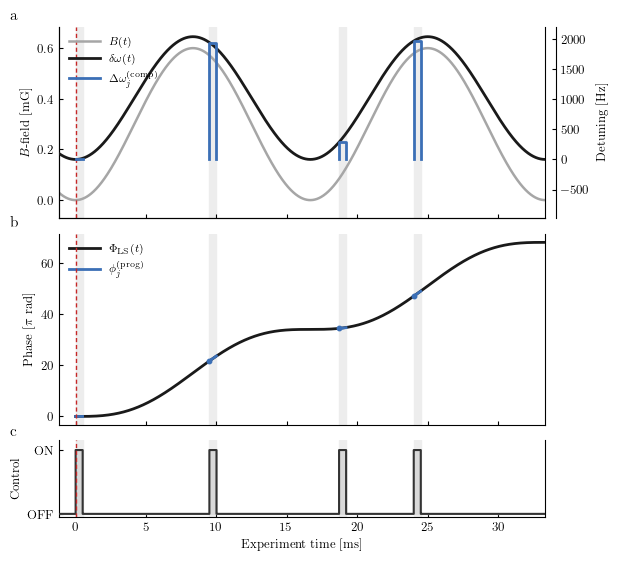

In [37]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import cumulative_trapezoid
from matplotlib import rcParams

# =========================================================
# STYLE
# =========================================================
rcParams.update({
    "font.family": "serif",
    "font.serif": ["Computer Modern Roman"],
    "text.usetex": True,
    "text.latex.preamble": r"\usepackage{amsmath}",
    "font.size": 9,
    "axes.linewidth": 0.8,
    "xtick.direction": "in",
    "ytick.direction": "in",
    "xtick.major.size": 3,
    "ytick.major.size": 3,
    "xtick.major.width": 0.8,
    "ytick.major.width": 0.8,
    "savefig.dpi": 300,
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
})

# =========================================================
# USER TOGGLES
# =========================================================
SHOW_ANNOTATIONS = False
SHOW_TRIGGER_SQUARE_WAVE = False
LASER_TRACE_ONLY_DURING_PULSES = True
USE_TOY_BFIELD = True

# Extra time shown before t=0 (only for B-field, detuning, trigger panel)
pre_trigger_duration = 1.2e-3   # [s]

# Width of red line-trigger pulse before t=0
trigger_width = 0.35e-3         # [s]

# =========================================================
# PARAMETERS
# =========================================================
fs = 200000
duration = 33330e-6
f0 = 623.3
gamma = 3.4e3   # Hz / mG

pulse_times = np.array([
    0.01e-6,
    9500e-6,
    18700e-6,
    24000e-6,
], dtype=float)

# Either scalar or array
pulse_width = np.array([500e-6, 500e-6, 500e-6, 500e-6], dtype=float)

# First pulse is reference; updates start from the next pulse
first_update_index = 1

# =========================================================
# HELPERS
# =========================================================
def padded_limits(y, low_pad=0.10, high_pad=0.10):
    y = np.asarray(y)
    ymin = np.min(y)
    ymax = np.max(y)
    span = ymax - ymin
    if np.isclose(span, 0):
        span = max(abs(ymax), 1.0)
    return ymin - low_pad * span, ymax + high_pad * span

label_box = dict(boxstyle="round,pad=0.20", fc="white", ec="none", alpha=0.92)

# =========================================================
# PULSE CHECKS
# =========================================================
if np.isscalar(pulse_width):
    pulse_widths = np.full(len(pulse_times), pulse_width, dtype=float)
else:
    pulse_widths = np.asarray(pulse_width, dtype=float)
    if len(pulse_widths) != len(pulse_times):
        raise ValueError("pulse_width array must have same length as pulse_times")

pulse_ends = pulse_times + pulse_widths

if np.any(np.diff(pulse_times) < 0):
    raise ValueError("pulse_times must be sorted in increasing order")

if np.any(pulse_ends > duration):
    raise ValueError("A pulse ends after the total sequence duration")

# =========================================================
# TIME AXES
# =========================================================
# Full time axis includes negative pre-trigger time
t_full = np.linspace(
    -pre_trigger_duration,
    duration,
    int(fs * (duration + pre_trigger_duration)),
    endpoint=False
)
t_full_ms = 1e3 * t_full

# Phase is only shown for t >= 0
t = np.linspace(0, duration, int(fs * duration), endpoint=False)
t_ms = 1e3 * t

# =========================================================
# FIELD / DETUNING / PHASE
# =========================================================
if USE_TOY_BFIELD:
    B_t_full = -0.3 * np.cos(2 * np.pi * 60 * t_full) + 0.3
else:
    B_t_full = B_rel_line_mG(t_full)

# Reference everything to the line trigger at t = 0
B_t_full = B_t_full - np.interp(0.0, t_full, B_t_full)

delta_ion_full = gamma * B_t_full   # [Hz]

# Use only t >= 0 for accumulated phase
B_t = np.interp(t, t_full, B_t_full)
delta_ion = gamma * B_t
phi_ion = 2 * np.pi * cumulative_trapezoid(delta_ion, t, initial=0)  # [rad]

# Sample at pulse times
delta_pulses = np.interp(pulse_times, t, delta_ion)
phi_pulses = np.interp(pulse_times, t, phi_ion)

# =========================================================
# LASER DETUNING DISPLAY
# =========================================================
# Base "held-between-updates" detuning
laser_detuning_full_hold = np.zeros_like(t_full)

for j in range(first_update_index, len(pulse_times)):
    t0 = pulse_times[j]
    t1 = pulse_times[j + 1] if j + 1 < len(pulse_times) else duration
    if j + 1 < len(pulse_times):
        mask = (t_full >= t0) & (t_full < t1)
    else:
        mask = (t_full >= t0) & (t_full <= t1)
    laser_detuning_full_hold[mask] = delta_pulses[j]

if LASER_TRACE_ONLY_DURING_PULSES:
    detuning_t_plot = []
    detuning_y_plot = []

    for j, (t0, w) in enumerate(zip(pulse_times, pulse_widths)):
        t1 = min(t0 + w, duration)
        det = 0.0 if j < first_update_index else delta_pulses[j]

        # Only show during pulse window
        detuning_t_plot.extend([t0, t0, t1, t1, np.nan])
        detuning_y_plot.extend([0.0, det, det, 0.0, np.nan])

    detuning_t_plot = 1e3 * np.array(detuning_t_plot)
    detuning_y_plot = np.array(detuning_y_plot)
else:
    laser_detuning_full = laser_detuning_full_hold

# =========================================================
# LASER PHASE DISPLAY
# =========================================================
marker_mask = np.arange(len(pulse_times)) >= first_update_index
laser_phase_marker_times_ms = 1e3 * pulse_times[marker_mask]
laser_phase_marker_vals = phi_pulses[marker_mask]

if LASER_TRACE_ONLY_DURING_PULSES:
    phase_t_plot = []
    phase_laser_plot = []

    for j, (t0, w) in enumerate(zip(pulse_times, pulse_widths)):
        t1 = min(t0 + w, duration)

        phi_start = 0.0 if j < first_update_index else phi_pulses[j]
        det = 0.0 if j < first_update_index else delta_pulses[j]
        phi_end = phi_start + 2 * np.pi * det * (t1 - t0)

        # Only show phase while laser is on
        phase_t_plot.extend([t0, t1, np.nan])
        phase_laser_plot.extend([phi_start, phi_end, np.nan])

    phase_t_plot = 1e3 * np.array(phase_t_plot)
    phase_laser_plot = np.array(phase_laser_plot)

else:
    # Continuous piecewise-linear phase + snaps
    phase_t_plot = [0.0]
    phase_laser_plot = [0.0]

    current_t = 0.0
    current_phi = 0.0
    current_detuning = 0.0

    update_times = pulse_times[first_update_index:]

    for k, t_update in enumerate(update_times):
        phi_before = current_phi + 2 * np.pi * current_detuning * (t_update - current_t)

        phase_t_plot.extend([t_update])
        phase_laser_plot.extend([phi_before])

        pulse_idx = first_update_index + k
        phi_snap = phi_pulses[pulse_idx]

        phase_t_plot.extend([t_update])
        phase_laser_plot.extend([phi_snap])

        current_t = t_update
        current_phi = phi_snap
        current_detuning = delta_pulses[pulse_idx]

    phi_end = current_phi + 2 * np.pi * current_detuning * (duration - current_t)
    phase_t_plot.extend([duration])
    phase_laser_plot.extend([phi_end])

    phase_t_plot = 1e3 * np.array(phase_t_plot)
    phase_laser_plot = np.array(phase_laser_plot)

# =========================================================
# CONTROL PANEL SIGNALS
# =========================================================
laser_on_full = np.zeros_like(t_full)
for t0, t1 in zip(pulse_times, pulse_ends):
    laser_on_full[(t_full >= t0) & (t_full < t1)] = 1

trigger_on_full = np.zeros_like(t_full)
trigger_on_full[(t_full >= -trigger_width) & (t_full < 0)] = 1

# =========================================================
# COLORS
# =========================================================
c_B = "0.65"
c_ion = "0.10"
c_laser = "#3B6FB6"
c_trigger = "#C62828"
c_trigger_fill = "#F3C7C7"

# =========================================================
# PLOT
# =========================================================
fig, axs = plt.subplots(
    3, 1,
    figsize=(6.4, 5.7),
    sharex=True,
    gridspec_kw={"height_ratios": [2.0, 2.0, 0.80]}
)

# ---------------------------------------------------------
# Panel 1: B-field + detuning
# ---------------------------------------------------------
ax = axs[0]
ax_r = ax.twinx()

ax.plot(t_full_ms, B_t_full, color=c_B, lw=1.8, label=r"$B(t)$", zorder=2)

ax_r.plot(
    t_full_ms, delta_ion_full,
    color=c_ion, lw=2.0,
    label=r"$\delta\omega(t)$", zorder=3
)

if LASER_TRACE_ONLY_DURING_PULSES:
    ax_r.plot(
        detuning_t_plot, detuning_y_plot,
        color=c_laser, lw=2.0,
        label=r"$\Delta\omega_j^{(\mathrm{comp})}$", zorder=4
    )
else:
    ax_r.step(
        t_full_ms, laser_detuning_full,
        where="post",
        color=c_laser, lw=2.0,
        label=r"$\Delta\omega_j^{(\mathrm{comp})}$", zorder=4
    )

# Asymmetric padding so proportional traces don't sit on top of each other
ax.set_ylim(*padded_limits(B_t_full, low_pad=0.12, high_pad=0.14))
ax_r.set_ylim(*padded_limits(delta_ion_full, low_pad=0.48, high_pad=0.08))
ax_r.spines["right"].set_position(("outward", 8))

ax.set_ylabel(r"$B$-field [mG]")
ax_r.set_ylabel(r"Detuning [Hz]")

lines = ax.get_lines() + ax_r.get_lines()
labels = [line.get_label() for line in lines]
ax_r.legend(lines, labels, loc="upper left", frameon=False, fontsize=8, handlelength=2.8)

# ---------------------------------------------------------
# Panel 2: phase
# ---------------------------------------------------------
ax = axs[1]

ax.plot(
    t_ms, phi_ion / np.pi,
    color=c_ion, lw=2.0,
    label=r"$\Phi_{\mathrm{LS}}(t)$", zorder=3
)

ax.plot(
    phase_t_plot, phase_laser_plot / np.pi,
    color=c_laser, lw=2.0,
    label=r"$\phi_j^{(\mathrm{prog})}$", zorder=4
)

if len(laser_phase_marker_times_ms) > 0:
    ax.plot(
        laser_phase_marker_times_ms,
        laser_phase_marker_vals / np.pi,
        "o", color=c_laser, ms=3.2, zorder=5
    )

ax.set_ylabel(r"Phase [$\pi$ rad]")
ax.legend(loc="upper left", frameon=False, fontsize=8, handlelength=2.8)

# ---------------------------------------------------------
# Panel 3: experiment time / trigger + laser
# ---------------------------------------------------------
ax = axs[2]

# Laser pulses
ax.step(t_full_ms, laser_on_full, where="post", color="0.20", lw=1.5, zorder=3)
ax.fill_between(t_full_ms, 0, laser_on_full, step="post", color="0.85", zorder=2)

# Optional trigger square wave before t=0
if SHOW_TRIGGER_SQUARE_WAVE:
    ax.step(t_full_ms, trigger_on_full, where="post", color=c_trigger, lw=1.6, zorder=4)
    ax.fill_between(t_full_ms, 0, trigger_on_full, step="post", color=c_trigger_fill, zorder=1)

ax.set_ylim(-0.05, 1.15)
ax.set_yticks([0, 1])
ax.set_yticklabels([r"OFF", r"ON"])
ax.set_ylabel(r"Control")
ax.set_xlabel(r"Experiment time [ms]")

# =========================================================
# SHARED STYLING
# =========================================================
for i, ax in enumerate(axs):
    # Pulse shading
    for t0, t1 in zip(pulse_times, pulse_ends):
        ax.axvspan(1e3 * t0, 1e3 * t1, color="0.93", zorder=0)

    # Red dashed t = 0 reference
    ax.axvline(0.0, color=c_trigger, lw=1.0, linestyle=(0, (3, 2)), zorder=6)

    ax.spines["top"].set_visible(False)
    ax.text(
        -0.10, 1.02, chr(ord("a") + i),
        transform=ax.transAxes,
        fontsize=11,
        fontweight="bold",
        va="bottom"
    )

ax_r.spines["top"].set_visible(False)

for ax in axs:
    ax.set_xlim(t_full_ms[0], t_full_ms[-1])

# =========================================================
# OPTIONAL ANNOTATIONS
# =========================================================
if SHOW_ANNOTATIONS:
    idx1 = int(0.22 * len(t_full))
    axs[0].annotate(
        r"$B(t)$",
        xy=(t_full_ms[idx1], B_t_full[idx1]),
        xytext=(t_full_ms[idx1] + 2.0, B_t_full[idx1] + 0.05),
        arrowprops=dict(arrowstyle="-", lw=0.8, color=c_B),
        fontsize=8,
        bbox=label_box,
    )

    idx2 = int(0.35 * len(t_full))
    ax_r.annotate(
        r"$\delta\omega(t)=\gamma B(t)$",
        xy=(t_full_ms[idx2], delta_ion_full[idx2]),
        xytext=(t_full_ms[idx2] + 2.5, delta_ion_full[idx2] + 130),
        arrowprops=dict(arrowstyle="-", lw=0.8, color=c_ion),
        fontsize=8,
        bbox=label_box,
    )

    if first_update_index < len(pulse_times):
        j0 = first_update_index
        ax_r.annotate(
            r"$\Delta\omega_j^{(\mathrm{comp})}=\delta\omega(t_j)$",
            xy=(1e3 * pulse_times[j0], delta_pulses[j0]),
            xytext=(1e3 * pulse_times[j0] + 2.0, delta_pulses[j0] - 180),
            arrowprops=dict(arrowstyle="->", lw=0.8, color=c_laser),
            fontsize=8,
            bbox=label_box,
        )

    idx3 = int(0.45 * len(t))
    axs[1].annotate(
        r"$\Phi_{\mathrm{LS}}(t)=2\pi \!\int_0^t \delta\omega(t')\,dt'$",
        xy=(t_ms[idx3], phi_ion[idx3] / np.pi),
        xytext=(t_ms[idx3] + 1.5, phi_ion[idx3] / np.pi + 0.10),
        arrowprops=dict(arrowstyle="-", lw=0.8, color=c_ion),
        fontsize=8,
        bbox=label_box,
    )

    if len(pulse_times) > first_update_index:
        j1 = min(first_update_index + 1, len(pulse_times) - 1)
        axs[1].annotate(
            r"$\phi_j^{(\mathrm{prog})}$ at $t_j$",
            xy=(1e3 * pulse_times[j1], phi_pulses[j1] / np.pi),
            xytext=(1e3 * pulse_times[j1] + 1.5, phi_pulses[j1] / np.pi + 0.15),
            arrowprops=dict(arrowstyle="->", lw=0.8, color=c_laser),
            fontsize=8,
            bbox=label_box,
        )

    if SHOW_TRIGGER_SQUARE_WAVE:
        axs[2].annotate(
            r"line trigger",
            xy=(-0.5 * 1e3 * trigger_width, 1.0),
            xytext=(0.70, 0.72),
            textcoords="axes fraction",
            arrowprops=dict(arrowstyle="->", lw=0.8, color=c_trigger),
            fontsize=8,
            color=c_trigger,
            bbox=label_box,
        )

    axs[2].annotate(
        r"global reference $t=0$",
        xy=(0.0, 1.02),
        xycoords=("data", "axes fraction"),
        xytext=(0.20, 1.18),
        textcoords="axes fraction",
        arrowprops=dict(arrowstyle="->", lw=0.8, color=c_trigger),
        fontsize=8,
        color=c_trigger,
        bbox=label_box,
    )

plt.subplots_adjust(left=0.12, right=0.88, top=0.97, bottom=0.11, hspace=0.10)
plt.savefig("Line_signal_Compensation_Figure1_explanation.pdf", bbox_inches="tight")
plt.show()

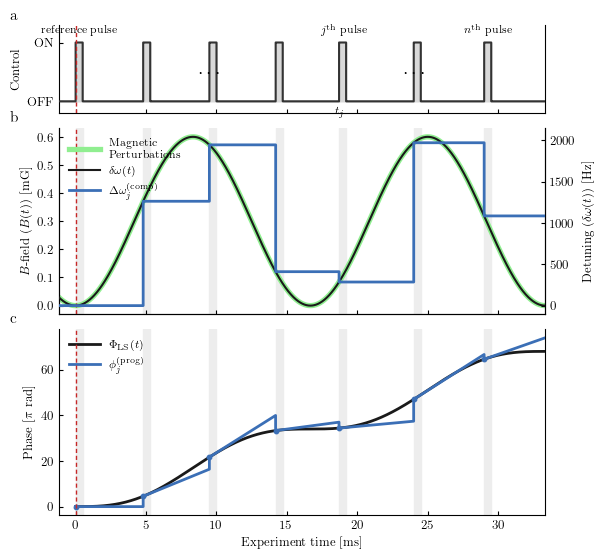

In [12]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import cumulative_trapezoid
from matplotlib import rcParams

rcParams.update({
    "font.family": "serif",
    "font.serif": ["Computer Modern Roman"],
    "text.usetex": True,
    "text.latex.preamble": r"\usepackage{amsmath}",
    "font.size": 9,
    "axes.linewidth": 0.8,
    "xtick.direction": "in",
    "ytick.direction": "in",
    "xtick.major.size": 3,
    "ytick.major.size": 3,
    "xtick.major.width": 0.8,
    "ytick.major.width": 0.8,
    "savefig.dpi": 300,
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
})

# =========================================================
# TOGGLES / USER SETTINGS
# =========================================================
SHOW_ANNOTATIONS = False
USE_TOY_BFIELD = True
SHOW_LINE_TRIGGER = False

# extra time shown before t=0 (for B-field + detuning + trigger only)
pre_trigger_duration = 1.2e-3   # [s]

# optional trigger pulse shown in red before t=0
trigger_width = 0.35e-3         # [s]

# =========================================================
# PARAMETERS
# =========================================================
fs = 200000
duration = 33330e-6
f0 = 623.3
gamma = 3.4e3   # Hz / mG   (plays the role of \kappa in the theory text)

# Expanded pulse sequence so the control panel can show:
# reference pulse ... jth pulse ... nth pulse
pulse_times = np.array([
    0.01e-6,   # reference pulse, effectively at t = 0
    4.8e-3,
    9.5e-3,
    14.2e-3,
    18.7e-3,   # jth pulse
    24.0e-3,
    29.0e-3,   # nth pulse
], dtype=float)

pulse_width = np.full(len(pulse_times), 500e-6, dtype=float)

# first pulse is reference; compensation updates start from next pulse
first_update_index = 1

# indices used only for figure labeling
ref_pulse_index = 0
j_pulse_index = 4
n_pulse_index = len(pulse_times) - 1

# =========================================================
# HELPERS
# =========================================================
def padded_limits(y, low_pad=0.10, high_pad=0.10):
    y = np.asarray(y)
    ymin = np.min(y)
    ymax = np.max(y)
    span = ymax - ymin
    if np.isclose(span, 0):
        span = max(abs(ymax), 1.0)
    return ymin - low_pad * span, ymax + high_pad * span

label_box = dict(boxstyle="round,pad=0.20", fc="white", ec="none", alpha=0.92)

# =========================================================
# PULSE CHECKS
# =========================================================
if np.isscalar(pulse_width):
    pulse_widths = np.full(len(pulse_times), pulse_width, dtype=float)
else:
    pulse_widths = np.asarray(pulse_width, dtype=float)
    if len(pulse_widths) != len(pulse_times):
        raise ValueError("pulse_width array must have the same length as pulse_times.")

pulse_ends = pulse_times + pulse_widths

if np.any(np.diff(pulse_times) < 0):
    raise ValueError("pulse_times must be sorted in increasing order.")

if np.any(pulse_ends > duration):
    raise ValueError("A pulse ends after the total sequence duration.")

# =========================================================
# TIME AXES
# =========================================================
# full axis includes negative pre-trigger time
t_full = np.linspace(
    -pre_trigger_duration,
    duration,
    int(fs * (duration + pre_trigger_duration)),
    endpoint=False
)
t_full_ms = 1e3 * t_full

# phase axis starts at t=0 only
t = np.linspace(0, duration, int(fs * duration), endpoint=False)
t_ms = 1e3 * t

# =========================================================
# FIELD / DETUNING
# =========================================================
if USE_TOY_BFIELD:
    B_t_full = -0.3 * np.cos(2 * np.pi * 60 * t_full) + 0.3
else:
    B_t_full = B_rel_line_mG(t_full)

# reference everything to the line trigger at t=0
B_t_full = B_t_full - np.interp(0.0, t_full, B_t_full)

delta_ion_full = gamma * B_t_full   # [Hz]

# use only t >= 0 for phase accumulation
B_t = np.interp(t, t_full, B_t_full)
delta_ion = gamma * B_t
phi_ion = 2 * np.pi * cumulative_trapezoid(delta_ion, t, initial=0)   # [rad]

# sampled values at pulse times
delta_pulses = np.interp(pulse_times, t, delta_ion)
phi_pulses = np.interp(pulse_times, t, phi_ion)

# =========================================================
# LASER DETUNING: piecewise constant, defined on full axis
# =========================================================
laser_detuning_full = np.zeros_like(t_full)

for j in range(first_update_index, len(pulse_times)):
    t0 = pulse_times[j]
    t1 = pulse_times[j + 1] if j + 1 < len(pulse_times) else duration
    if j + 1 < len(pulse_times):
        mask = (t_full >= t0) & (t_full < t1)
    else:
        mask = (t_full >= t0) & (t_full <= t1)
    laser_detuning_full[mask] = delta_pulses[j]

# =========================================================
# LASER PHASE: piecewise linear + snaps, plotted only for t >= 0
# =========================================================
phase_t_plot = [0.0]
phase_laser_plot = [0.0]

current_t = 0.0
current_phi = 0.0
current_detuning = 0.0

update_times = pulse_times[first_update_index:]

for k, t_update in enumerate(update_times):
    phi_before = current_phi + 2 * np.pi * current_detuning * (t_update - current_t)

    phase_t_plot.extend([t_update])
    phase_laser_plot.extend([phi_before])

    pulse_idx = first_update_index + k
    phi_snap = phi_pulses[pulse_idx]

    phase_t_plot.extend([t_update])
    phase_laser_plot.extend([phi_snap])

    current_t = t_update
    current_phi = phi_snap
    current_detuning = delta_pulses[pulse_idx]

phi_end = current_phi + 2 * np.pi * current_detuning * (duration - current_t)
phase_t_plot.extend([duration])
phase_laser_plot.extend([phi_end])

phase_t_plot = 1e3 * np.array(phase_t_plot)      # [ms]
phase_laser_plot = np.array(phase_laser_plot)    # [rad]

# =========================================================
# CONTROL PANEL SIGNALS
# =========================================================
laser_on_full = np.zeros_like(t_full)
for t0, t1 in zip(pulse_times, pulse_ends):
    laser_on_full[(t_full >= t0) & (t_full < t1)] = 1

# optional red line-trigger pulse before t=0
trigger_on_full = np.zeros_like(t_full)
trigger_on_full[(t_full >= -trigger_width) & (t_full < 0)] = 1

# =========================================================
# COLORS
# =========================================================
c_B = "0.65"
c_ion = "0.10"
c_laser = "#3B6FB6"
c_trigger = "#C62828"
c_trigger_fill = "#F3C7C7"

# =========================================================
# PLOT
# =========================================================
fig, axs = plt.subplots(
    3, 1,
    figsize=(6.4, 5.7),
    sharex=True,
    gridspec_kw={"height_ratios": [0.95, 2.0, 2.0]}
)

# ---------------------------------------------------------
# Panel 1: control sequence
# ---------------------------------------------------------
ax = axs[0]

ax.step(t_full_ms, laser_on_full, where="post", color="0.20", lw=1.5, zorder=3)
ax.fill_between(t_full_ms, 0, laser_on_full, step="post", color="0.85", zorder=2)

if SHOW_LINE_TRIGGER:
    ax.step(t_full_ms, trigger_on_full, where="post", color=c_trigger, lw=1.6, zorder=4)
    ax.fill_between(t_full_ms, 0, trigger_on_full, step="post", color=c_trigger_fill, zorder=1)

ax.set_ylim(-0.20, 1.30)
ax.set_yticks([0, 1])
ax.set_yticklabels([r"OFF", r"ON"])
ax.set_ylabel(r"Control")

# pulse labels
pulse_labels = {
    ref_pulse_index: r"reference pulse",
    j_pulse_index: r"$j^{\mathrm{th}}$ pulse",
    n_pulse_index: r"$n^{\mathrm{th}}$ pulse",
}

for idx, txt in pulse_labels.items():
    x_center = 1e3 * (pulse_times[idx] + 0.5 * pulse_widths[idx])
    ax.text(x_center, 1.12, txt, ha="center", va="bottom", fontsize=8)

# mark t_j at the start of the jth pulse
ax.text(1e3 * pulse_times[j_pulse_index], -0.10, r"$t_j$", ha="center", va="top", fontsize=8)

# ellipses between reference -> jth and jth -> nth
x_ell_1 = 1e3 * 0.5 * (pulse_ends[ref_pulse_index] + pulse_times[j_pulse_index])
x_ell_2 = 1e3 * 0.5 * (pulse_ends[j_pulse_index] + pulse_times[n_pulse_index])

ax.text(x_ell_1, 0.52, r"$\cdots$", ha="center", va="center", fontsize=14)
ax.text(x_ell_2, 0.52, r"$\cdots$", ha="center", va="center", fontsize=14)

# ---------------------------------------------------------
# Panel 2: B-field + detuning
# ---------------------------------------------------------
ax = axs[1]
ax_r = ax.twinx()

ax.plot(
    t_full_ms, B_t_full,
    color="lightgreen", lw=3.8,
    label="Magnetic \n Perturbations", zorder=2, alpha=1
)

ax_r.plot(
    t_full_ms, delta_ion_full,
    color=c_ion, lw=1.5,
    label=r"$\delta\omega(t)$", zorder=3
)

ax_r.step(
    t_full_ms, laser_detuning_full,
    where="post",
    color=c_laser, lw=2.0,
    label=r"$\Delta\omega_j^{(\mathrm{comp})}$", zorder=4
)

ax.set_ylabel(r"$B$-field ($B(t)$) [mG]")
ax_r.set_ylabel(r"Detuning ($\delta\omega(t)$) [Hz]")

lines = ax.get_lines() + ax_r.get_lines()
labels = [line.get_label() for line in lines]
ax_r.legend(lines, labels, loc="upper left", frameon=False, fontsize=8, handlelength=2.8)

# ---------------------------------------------------------
# Panel 3: phase
# ---------------------------------------------------------
ax = axs[2]

ax.plot(
    t_ms, phi_ion / np.pi,
    color=c_ion, lw=2.0,
    label=r"$\Phi_{\mathrm{LS}}(t)$", zorder=3
)

ax.plot(
    phase_t_plot, phase_laser_plot / np.pi,
    color=c_laser, lw=2.0,
    label=r"$\phi_j^{(\mathrm{prog})}$", zorder=4
)

ax.plot(1e3 * pulse_times, phi_pulses / np.pi, "o", color=c_laser, ms=3.2, zorder=5)

ax.set_ylabel(r"Phase [$\pi$ rad]")
ax.set_xlabel(r"Experiment time [ms]")
ax.legend(loc="upper left", frameon=False, fontsize=8, handlelength=2.8)

# =========================================================
# SHARED STYLING
# =========================================================
for i, ax in enumerate(axs):
    # shade pulse windows only on lower panels
    if i > 0:
        for t0, t1 in zip(pulse_times, pulse_ends):
            ax.axvspan(1e3 * t0, 1e3 * t1, color="0.93", zorder=0)

    # global t = 0 reference
    ax.axvline(0.0, color=c_trigger, lw=1.0, linestyle=(0, (3, 2)), zorder=6)

    ax.spines["top"].set_visible(False)
    ax.text(
        -0.10, 1.02, chr(ord("a") + i),
        transform=ax.transAxes,
        fontsize=11,
        fontweight="bold",
        va="bottom"
    )

ax_r.spines["top"].set_visible(False)

for ax in axs:
    ax.set_xlim(t_full_ms[0], t_full_ms[-1])

# =========================================================
# OPTIONAL THEORY ANNOTATIONS
# =========================================================
if SHOW_ANNOTATIONS:
    # Panel 1 annotations
    axs[0].annotate(
        r"global reference $t=0$",
        xy=(0.0, 1.02),
        xycoords=("data", "axes fraction"),
        xytext=(0.18, 1.18),
        textcoords="axes fraction",
        arrowprops=dict(arrowstyle="->", lw=0.8, color=c_trigger),
        fontsize=8,
        color=c_trigger,
        bbox=label_box,
    )

    # Panel 2 annotations
    idx1 = int(0.22 * len(t_full))
    axs[1].annotate(
        r"$B(t)$",
        xy=(t_full_ms[idx1], B_t_full[idx1]),
        xytext=(t_full_ms[idx1] + 2.0, B_t_full[idx1] + 0.05),
        arrowprops=dict(arrowstyle="-", lw=0.8, color=c_B),
        fontsize=8,
        bbox=label_box,
    )

    idx2 = int(0.35 * len(t_full))
    ax_r.annotate(
        r"$\delta\omega(t)=\gamma B(t)$",
        xy=(t_full_ms[idx2], delta_ion_full[idx2]),
        xytext=(t_full_ms[idx2] + 2.5, delta_ion_full[idx2] + 130),
        arrowprops=dict(arrowstyle="-", lw=0.8, color=c_ion),
        fontsize=8,
        bbox=label_box,
    )

    if first_update_index < len(pulse_times):
        j0 = first_update_index
        ax_r.annotate(
            r"$\Delta\omega_j^{(\mathrm{comp})}=\delta\omega(t_j)$",
            xy=(1e3 * pulse_times[j0], delta_pulses[j0]),
            xytext=(1e3 * pulse_times[j0] + 2.0, delta_pulses[j0] - 180),
            arrowprops=dict(arrowstyle="->", lw=0.8, color=c_laser),
            fontsize=8,
            bbox=label_box,
        )

    # Panel 3 annotations
    idx3 = int(0.45 * len(t))
    axs[2].annotate(
        r"$\Phi_{\mathrm{LS}}(t)=2\pi \!\int_0^t \delta\omega(t')\,dt'$",
        xy=(t_ms[idx3], phi_ion[idx3] / np.pi),
        xytext=(t_ms[idx3] + 1.5, phi_ion[idx3] / np.pi + 0.10),
        arrowprops=dict(arrowstyle="-", lw=0.8, color=c_ion),
        fontsize=8,
        bbox=label_box,
    )

    if len(pulse_times) > first_update_index:
        j1 = min(first_update_index + 1, len(pulse_times) - 1)
        axs[2].annotate(
            r"$\phi_j^{(\mathrm{prog})}$ at $t_j$",
            xy=(1e3 * pulse_times[j1], phi_pulses[j1] / np.pi),
            xytext=(1e3 * pulse_times[j1] + 1.5, phi_pulses[j1] / np.pi + 0.15),
            arrowprops=dict(arrowstyle="->", lw=0.8, color=c_laser),
            fontsize=8,
            bbox=label_box,
        )

plt.subplots_adjust(left=0.12, right=0.88, top=0.97, bottom=0.11, hspace=0.10)
plt.savefig("Line_signal_Compensation_Figure1_explanation.pdf", bbox_inches="tight")
plt.show()

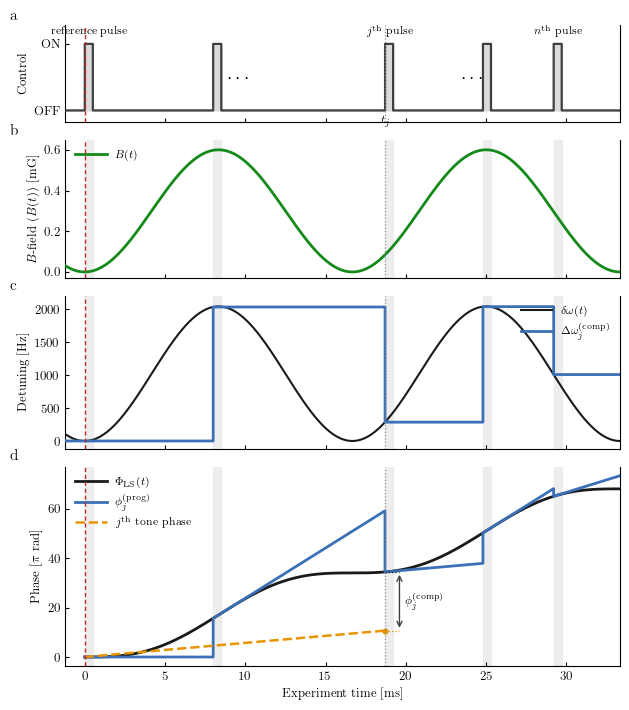

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import cumulative_trapezoid
from matplotlib import rcParams

rcParams.update({
    "font.family": "serif",
    "font.serif": ["Computer Modern Roman"],
    "text.usetex": True,
    "text.latex.preamble": r"\usepackage{amsmath}",
    "font.size": 9,
    "axes.linewidth": 0.8,
    "xtick.direction": "in",
    "ytick.direction": "in",
    "xtick.major.size": 3,
    "ytick.major.size": 3,
    "xtick.major.width": 0.8,
    "ytick.major.width": 0.8,
    "savefig.dpi": 300,
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
})

# =========================================================
# TOGGLES / USER SETTINGS
# =========================================================
SHOW_ANNOTATIONS = False
USE_TOY_BFIELD = True
SHOW_LINE_TRIGGER = False

# extra time shown before t=0
pre_trigger_duration = 1.2e-3   # [s]

# optional trigger pulse shown in red before t=0
trigger_width = 0.35e-3         # [s]

# =========================================================
# PARAMETERS
# =========================================================
fs = 200000
duration = 33330e-6
gamma = 3.4e3   # Hz / mG


# Pulse train used for the schematic:
# reference pulse ... jth pulse ... nth pulse
pulse_times = np.array([
    0.01e-6,   # reference pulse
    4.0e-3,
    8.7e-3,   # jth pulse
    24.8e-3,
    29.2e-3,   # nth pulse
], dtype=float)

pulse_width = np.full(len(pulse_times), 500e-6, dtype=float)

first_update_index = 1

# indices used for labeling in the schematic
ref_pulse_index = 0
j_pulse_index = 2
n_pulse_index = len(pulse_times) - 1

# =========================================================
# HELPERS
# =========================================================
def padded_limits(y, low_pad=0.08, high_pad=0.08):
    y = np.asarray(y)
    ymin = np.min(y)
    ymax = np.max(y)
    span = ymax - ymin
    if np.isclose(span, 0):
        span = max(abs(ymax), 1.0)
    return ymin - low_pad * span, ymax + high_pad * span

label_box = dict(boxstyle="round,pad=0.20", fc="white", ec="none", alpha=0.92)

# =========================================================
# PULSE CHECKS
# =========================================================
pulse_widths = np.asarray(pulse_width, dtype=float)
if len(pulse_widths) != len(pulse_times):
    raise ValueError("pulse_width array must have the same length as pulse_times.")

pulse_ends = pulse_times + pulse_widths

if np.any(np.diff(pulse_times) < 0):
    raise ValueError("pulse_times must be sorted in increasing order.")

if np.any(pulse_ends > duration):
    raise ValueError("A pulse ends after the total sequence duration.")

# =========================================================
# TIME AXES
# =========================================================
# full axis includes negative pre-trigger time
t_full = np.linspace(
    -pre_trigger_duration,
    duration,
    int(fs * (duration + pre_trigger_duration)),
    endpoint=False
)
t_full_ms = 1e3 * t_full

# phase axis starts at t=0 only
t = np.linspace(0, duration, int(fs * duration), endpoint=False)
t_ms = 1e3 * t

# =========================================================
# FIELD / DETUNING
# =========================================================
if USE_TOY_BFIELD:
    B_t_full = -0.3 * np.cos(2 * np.pi * 60 * t_full) + 0.3
else:
    B_t_full = B_rel_line_mG(t_full)

# reference everything to the line trigger at t=0
B_t_full = B_t_full - np.interp(0.0, t_full, B_t_full)

# detuning in Hz
delta_ion_full = gamma * B_t_full

# use only t >= 0 for phase accumulation
B_t = np.interp(t, t_full, B_t_full)
delta_ion = gamma * B_t
phi_ion = 2 * np.pi * cumulative_trapezoid(delta_ion, t, initial=0)   # [rad]

# sampled values at pulse times
delta_pulses = np.interp(pulse_times, t, delta_ion)
phi_pulses = np.interp(pulse_times, t, phi_ion)

# =========================================================
# COMPENSATED LASER DETUNING: piecewise constant, full axis
# =========================================================
laser_detuning_full = np.zeros_like(t_full)

for j in range(first_update_index, len(pulse_times)):
    t0 = pulse_times[j]
    t1 = pulse_times[j + 1] if j + 1 < len(pulse_times) else duration
    if j + 1 < len(pulse_times):
        mask = (t_full >= t0) & (t_full < t1)
    else:
        mask = (t_full >= t0) & (t_full <= t1)
    laser_detuning_full[mask] = delta_pulses[j]

# =========================================================
# PROGRAMMED PHASE: piecewise linear + snaps, plotted for t >= 0
# =========================================================
phase_t_plot = [0.0]
phase_laser_plot = [0.0]

current_t = 0.0
current_phi = 0.0
current_detuning = 0.0

update_times = pulse_times[first_update_index:]

for k, t_update in enumerate(update_times):
    phi_before = current_phi + 2 * np.pi * current_detuning * (t_update - current_t)

    phase_t_plot.extend([t_update])
    phase_laser_plot.extend([phi_before])

    pulse_idx = first_update_index + k
    phi_snap = phi_pulses[pulse_idx]

    phase_t_plot.extend([t_update])
    phase_laser_plot.extend([phi_snap])

    current_t = t_update
    current_phi = phi_snap
    current_detuning = delta_pulses[pulse_idx]

phi_end = current_phi + 2 * np.pi * current_detuning * (duration - current_t)
phase_t_plot.extend([duration])
phase_laser_plot.extend([phi_end])

phase_t_plot = 1e3 * np.array(phase_t_plot)      # [ms]
phase_laser_plot = np.array(phase_laser_plot)    # [rad]

# =========================================================
# JTH-TONE LINEAR PHASE IN THE REFERENCE FRAME
# This is the phase implied by using the jth compensated frequency,
# referenced back to t = 0.
# =========================================================
t_j = pulse_times[j_pulse_index]
t_j_ms = 1e3 * t_j
delta_j = delta_pulses[j_pulse_index]

mask_j = t <= t_j
t_for_j_phase = t[mask_j]
phi_j_linear = 2 * np.pi * delta_j * t_for_j_phase   # [rad]

# =========================================================
# CONTROL PANEL SIGNALS
# =========================================================
laser_on_full = np.zeros_like(t_full)
for t0, t1 in zip(pulse_times, pulse_ends):
    laser_on_full[(t_full >= t0) & (t_full < t1)] = 1

# optional red trigger pulse before t=0
trigger_on_full = np.zeros_like(t_full)
trigger_on_full[(t_full >= -trigger_width) & (t_full < 0)] = 1

# =========================================================
# COLORS
# =========================================================
c_B = "#138A1A"
c_ion = "0.10"
c_laser = "#3B6FB6"
c_jphase = "#E69500"
c_trigger = "#C62828"
c_trigger_fill = "#F3C7C7"
c_tj = "0.55"

# =========================================================
# PLOT
# =========================================================
fig, axs = plt.subplots(
    4, 1,
    figsize=(6.6, 7.2),
    sharex=True,
    gridspec_kw={"height_ratios": [0.95, 1.35, 1.50, 1.95]}
)

# ---------------------------------------------------------
# Panel 1: control sequence
# ---------------------------------------------------------
ax = axs[0]

ax.step(t_full_ms, laser_on_full, where="post", color="0.25", lw=1.6, zorder=3)
ax.fill_between(t_full_ms, 0, laser_on_full, step="post", color="0.86", zorder=2)

if SHOW_LINE_TRIGGER:
    ax.step(t_full_ms, trigger_on_full, where="post", color=c_trigger, lw=1.5, zorder=4)
    ax.fill_between(t_full_ms, 0, trigger_on_full, step="post", color=c_trigger_fill, zorder=1)

ax.set_ylim(-0.18, 1.28)
ax.set_yticks([0, 1])
ax.set_yticklabels([r"OFF", r"ON"])
ax.set_ylabel(r"Control")

# pulse labels
pulse_labels = {
    ref_pulse_index: r"reference pulse",
    j_pulse_index: r"$j^{\mathrm{th}}$ pulse",
    n_pulse_index: r"$n^{\mathrm{th}}$ pulse",
}

for idx, txt in pulse_labels.items():
    x_center = 1e3 * (pulse_times[idx] + 0.5 * pulse_widths[idx])
    ax.text(x_center, 1.10, txt, ha="center", va="bottom", fontsize=8)

# mark t_j at the start of the jth pulse
ax.text(1e3 * pulse_times[j_pulse_index], -0.10, r"$t_j$", ha="center", va="top", fontsize=8)

# ellipses between reference -> jth and jth -> nth
x_ell_1 = 1e3 * 0.5 * (pulse_ends[ref_pulse_index] + pulse_times[j_pulse_index])
x_ell_2 = 1e3 * 0.5 * (pulse_ends[j_pulse_index] + pulse_times[n_pulse_index])
ax.text(x_ell_1, 0.52, r"$\cdots$", ha="center", va="center", fontsize=14)
ax.text(x_ell_2, 0.52, r"$\cdots$", ha="center", va="center", fontsize=14)

# ---------------------------------------------------------
# Panel 2: B field only
# ---------------------------------------------------------
ax = axs[1]

ax.plot(
    t_full_ms, B_t_full,
    color=c_B, lw=2.0,
    label=r"$B(t)$", zorder=3
)

ax.set_ylabel(r"$B$-field ($B(t)$) [mG]")
ax.set_ylim(*padded_limits(B_t_full, low_pad=0.05, high_pad=0.08))
ax.legend(loc="upper left", frameon=False, fontsize=8, handlelength=2.8)

# ---------------------------------------------------------
# Panel 3: detuning only
# ---------------------------------------------------------
ax = axs[2]

ax.plot(
    t_full_ms, delta_ion_full,
    color=c_ion, lw=1.5,
    label=r"$\delta\omega(t)$", zorder=3
)

ax.step(
    t_full_ms, laser_detuning_full,
    where="post",
    color=c_laser, lw=2.0,
    label=r"$\Delta\omega_j^{(\mathrm{comp})}$", zorder=4
)

ax.set_ylabel(r"Detuning [Hz]")
ax.set_ylim(*padded_limits(np.r_[delta_ion_full, laser_detuning_full], low_pad=0.06, high_pad=0.08))
ax.legend(loc="upper right", frameon=False, fontsize=8, handlelength=2.8)

# ---------------------------------------------------------
# Panel 4: phase
# ---------------------------------------------------------
ax = axs[3]

ax.plot(
    t_ms, phi_ion / np.pi,
    color=c_ion, lw=2.0,
    label=r"$\Phi_{\mathrm{LS}}(t)$", zorder=3
)

ax.plot(
    phase_t_plot, phase_laser_plot / np.pi,
    color=c_laser, lw=2.0,
    label=r"$\phi_j^{(\mathrm{prog})}$", zorder=4
)

# linear phase of the jth compensated tone, referenced to t = 0
ax.plot(
    1e3 * t_for_j_phase, phi_j_linear / np.pi,
    color=c_jphase, lw=1.8, linestyle="--",
    label=r"$j^{\mathrm{th}}$ tone phase", zorder=5
)

# marker at t_j
ax.plot(
    [t_j_ms],
    [2 * np.pi * delta_j * t_j / np.pi],
    marker="o", ms=3.4, color=c_jphase, zorder=6
)

# values at t_j
phi_ls_tj = np.interp(t_j, t, phi_ion)                 # [rad]
phi_j_tone_tj = 2 * np.pi * delta_j * t_j              # [rad]

# slightly offset the arrow to the right of t_j so it does not sit on top of the vertical guide
x_arrow = t_j_ms + 0.9

# dotted horizontal guides from the two phase values to the arrow
ax.plot(
    [t_j_ms, x_arrow],
    [phi_ls_tj / np.pi, phi_ls_tj / np.pi],
    linestyle=":", lw=0.9, color=c_ion, zorder=6
)
ax.plot(
    [t_j_ms, x_arrow],
    [phi_j_tone_tj / np.pi, phi_j_tone_tj / np.pi],
    linestyle=":", lw=0.9, color=c_jphase, zorder=6
)

# double arrow showing the phase compensation
ax.annotate(
    "",
    xy=(x_arrow, phi_ls_tj / np.pi),
    xytext=(x_arrow, phi_j_tone_tj / np.pi),
    arrowprops=dict(arrowstyle="<->", lw=1.0, color="0.25"),
    zorder=7,
)

# label for the phase correction
ax.text(
    x_arrow + 0.35,
    0.5 * (phi_ls_tj + phi_j_tone_tj) / np.pi,
    r"$\phi_j^{(\mathrm{comp})}$",
    ha="left",
    va="center",
    fontsize=8,
)

ax.set_ylabel(r"Phase [$\pi$ rad]")
ax.set_xlabel(r"Experiment time [ms]")
ax.legend(loc="upper left", frameon=False, fontsize=8, handlelength=2.8)

# =========================================================
# SHARED STYLING
# =========================================================
for i, ax in enumerate(axs):
    # shade pulse windows only on the lower three panels
    if i > 0:
        for t0, t1 in zip(pulse_times, pulse_ends):
            ax.axvspan(1e3 * t0, 1e3 * t1, color="0.93", zorder=0)

    # global t = 0 reference
    ax.axvline(0.0, color=c_trigger, lw=1.0, linestyle=(0, (3, 2)), zorder=6)

    # vertical guide at t_j
    ax.axvline(t_j_ms, color=c_tj, lw=0.9, linestyle=":", zorder=6)

    ax.spines["top"].set_visible(False)
    ax.text(
        -0.10, 1.02, chr(ord("a") + i),
        transform=ax.transAxes,
        fontsize=11,
        fontweight="bold",
        va="bottom"
    )

for ax in axs:
    ax.set_xlim(t_full_ms[0], t_full_ms[-1])

# =========================================================
# OPTIONAL THEORY ANNOTATIONS
# =========================================================
if SHOW_ANNOTATIONS:
    axs[0].annotate(
        r"global reference $t=0$",
        xy=(0.0, 1.02),
        xycoords=("data", "axes fraction"),
        xytext=(0.18, 1.18),
        textcoords="axes fraction",
        arrowprops=dict(arrowstyle="->", lw=0.8, color=c_trigger),
        fontsize=8,
        color=c_trigger,
        bbox=label_box,
    )

    idxB = int(0.35 * len(t_full))
    axs[1].annotate(
        r"$B(t)$",
        xy=(t_full_ms[idxB], B_t_full[idxB]),
        xytext=(t_full_ms[idxB] + 2.0, B_t_full[idxB] + 0.05),
        arrowprops=dict(arrowstyle="-", lw=0.8, color=c_B),
        fontsize=8,
        bbox=label_box,
    )

    idxD = int(0.32 * len(t_full))
    axs[2].annotate(
        r"$\delta\omega(t)$",
        xy=(t_full_ms[idxD], delta_ion_full[idxD]),
        xytext=(t_full_ms[idxD] + 2.0, delta_ion_full[idxD] + 180),
        arrowprops=dict(arrowstyle="-", lw=0.8, color=c_ion),
        fontsize=8,
        bbox=label_box,
    )

    axs[2].annotate(
        r"$\Delta\omega_j^{(\mathrm{comp})}=\delta\omega(t_j)$",
        xy=(t_j_ms, delta_j),
        xytext=(t_j_ms + 1.2, delta_j + 180),
        arrowprops=dict(arrowstyle="->", lw=0.8, color=c_laser),
        fontsize=8,
        bbox=label_box,
    )

    axs[3].annotate(
        r"$\Phi_{\mathrm{LS}}(t)$",
        xy=(t_j_ms, np.interp(t_j, t, phi_ion) / np.pi),
        xytext=(t_j_ms + 1.0, np.interp(t_j, t, phi_ion) / np.pi + 8),
        arrowprops=dict(arrowstyle="-", lw=0.8, color=c_ion),
        fontsize=8,
        bbox=label_box,
    )

    axs[3].annotate(
        r"$t\,\delta\omega(t_j)$ in the $\omega_0$ frame",
        xy=(t_j_ms, (2 * np.pi * delta_j * t_j) / np.pi),
        xytext=(t_j_ms - 9.0, (2 * np.pi * delta_j * t_j) / np.pi - 10),
        arrowprops=dict(arrowstyle="->", lw=0.8, color=c_jphase),
        fontsize=8,
        bbox=label_box,
    )

plt.subplots_adjust(left=0.13, right=0.97, top=0.98, bottom=0.09, hspace=0.12)
plt.savefig("Line_signal_Compensation_Figure1_explanation.pdf", bbox_inches="tight")
plt.show()

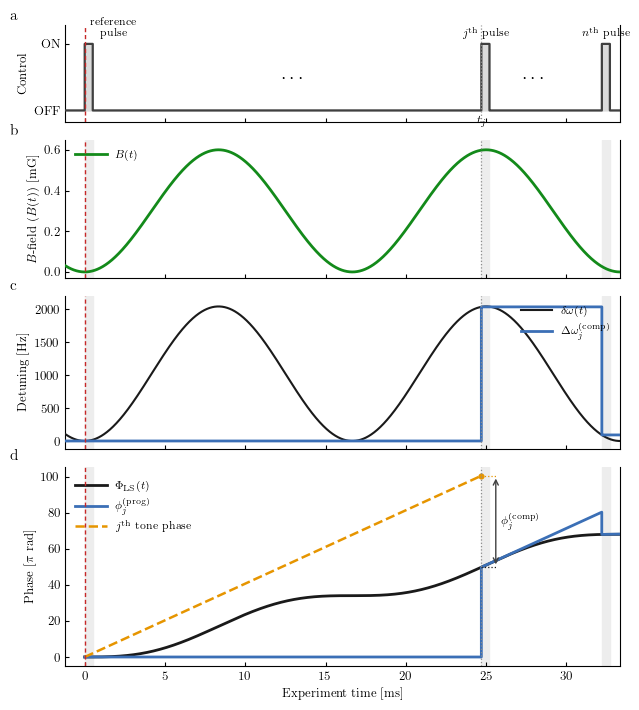

In [20]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import cumulative_trapezoid
from matplotlib import rcParams

rcParams.update({
    "font.family": "serif",
    "font.serif": ["Computer Modern Roman"],
    "text.usetex": True,
    "text.latex.preamble": r"\usepackage{amsmath}",
    "font.size": 9,
    "axes.linewidth": 0.8,
    "xtick.direction": "in",
    "ytick.direction": "in",
    "xtick.major.size": 3,
    "ytick.major.size": 3,
    "xtick.major.width": 0.8,
    "ytick.major.width": 0.8,
    "savefig.dpi": 300,
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
})

# =========================================================
# TOGGLES / USER SETTINGS
# =========================================================
SHOW_ANNOTATIONS = False
USE_TOY_BFIELD = True
SHOW_LINE_TRIGGER = False

pre_trigger_duration = 1.2e-3   # [s]
trigger_width = 0.35e-3         # [s]

# =========================================================
# GLOBAL PARAMETERS
# =========================================================
fs = 200000
duration = 33330e-6
gamma = 3.4e3   # Hz / mG

# =========================================================
# USER-CONTROLLED PULSE LAYOUT
# =========================================================
# Set pulse start times directly in ms.
# Number of pulses = len(pulse_times_ms)
pulse_times_ms = [
    0.00,   # reference pulse
    # 8.00,
    24.70,  # jth pulse
    32.20,  # nth pulse
]

# Common pulse width [ms], or list with one entry per pulse
pulse_width_ms = 0.50
# Example:
# pulse_width_ms = [0.50, 0.50, 0.70, 0.50]

# Choose which pulse is the jth pulse (0-based index)
j_pulse_index = 1

# Usually keep these:
ref_pulse_index = 0
n_pulse_index = len(pulse_times_ms) - 1

# Dot positions in ms (fully user-controlled)
dot_positions_ms = [13.0, 28.0]
dots_y = 0.52

# Labels for selected pulses
custom_pulse_labels = {
    ref_pulse_index: "reference \n pulse",
    j_pulse_index: r"$j^{\mathrm{th}}$ pulse",
    n_pulse_index: r"$n^{\mathrm{th}}$ pulse",
}

# First pulse is the reference; compensation updates start from next pulse
first_update_index = 1

# =========================================================
# CONVERT TO SI UNITS + VALIDATE
# =========================================================
pulse_times = 1e-3 * np.array(pulse_times_ms, dtype=float)

if np.isscalar(pulse_width_ms):
    pulse_widths = np.full(len(pulse_times), 1e-3 * float(pulse_width_ms), dtype=float)
else:
    pulse_widths = 1e-3 * np.array(pulse_width_ms, dtype=float)
    if len(pulse_widths) != len(pulse_times):
        raise ValueError("pulse_width_ms must be a scalar or a list with one entry per pulse.")

pulse_ends = pulse_times + pulse_widths

if len(pulse_times) < 3:
    raise ValueError("Use at least 3 pulses so the schematic can show reference, jth, and nth pulse.")

if np.any(np.diff(pulse_times) < 0):
    raise ValueError("pulse_times_ms must be sorted in increasing order.")

if np.any(pulse_ends > duration):
    raise ValueError("A pulse ends after the total sequence duration.")

if not (0 <= ref_pulse_index < len(pulse_times)):
    raise ValueError("ref_pulse_index is out of range.")

if not (0 <= j_pulse_index < len(pulse_times)):
    raise ValueError("j_pulse_index is out of range.")

if not (0 <= n_pulse_index < len(pulse_times)):
    raise ValueError("n_pulse_index is out of range.")

if ref_pulse_index == j_pulse_index or j_pulse_index == n_pulse_index or ref_pulse_index == n_pulse_index:
    raise ValueError("reference, jth, and nth pulses must be different.")

if not (ref_pulse_index < j_pulse_index < n_pulse_index):
    raise ValueError("Require ref_pulse_index < j_pulse_index < n_pulse_index.")

# =========================================================
# HELPERS
# =========================================================
def padded_limits(y, low_pad=0.08, high_pad=0.08):
    y = np.asarray(y)
    ymin = np.min(y)
    ymax = np.max(y)
    span = ymax - ymin
    if np.isclose(span, 0):
        span = max(abs(ymax), 1.0)
    return ymin - low_pad * span, ymax + high_pad * span

label_box = dict(boxstyle="round,pad=0.20", fc="white", ec="none", alpha=0.92)

# =========================================================
# TIME AXES
# =========================================================
t_full = np.linspace(
    -pre_trigger_duration,
    duration,
    int(fs * (duration + pre_trigger_duration)),
    endpoint=False
)
t_full_ms = 1e3 * t_full

t = np.linspace(0, duration, int(fs * duration), endpoint=False)
t_ms = 1e3 * t

# =========================================================
# FIELD / DETUNING
# =========================================================
if USE_TOY_BFIELD:
    B_t_full = -0.3 * np.cos(2 * np.pi * 60 * t_full) + 0.3
else:
    B_t_full = B_rel_line_mG(t_full)

# Reference to line trigger at t=0
B_t_full = B_t_full - np.interp(0.0, t_full, B_t_full)

delta_ion_full = gamma * B_t_full   # [Hz]

B_t = np.interp(t, t_full, B_t_full)
delta_ion = gamma * B_t
phi_ion = 2 * np.pi * cumulative_trapezoid(delta_ion, t, initial=0)   # [rad]

delta_pulses = np.interp(pulse_times, t, delta_ion)
phi_pulses = np.interp(pulse_times, t, phi_ion)

# =========================================================
# COMPENSATED LASER DETUNING: piecewise constant
# =========================================================
laser_detuning_full = np.zeros_like(t_full)

for j in range(first_update_index, len(pulse_times)):
    t0 = pulse_times[j]
    t1 = pulse_times[j + 1] if j + 1 < len(pulse_times) else duration
    if j + 1 < len(pulse_times):
        mask = (t_full >= t0) & (t_full < t1)
    else:
        mask = (t_full >= t0) & (t_full <= t1)
    laser_detuning_full[mask] = delta_pulses[j]

# =========================================================
# PROGRAMMED PHASE: piecewise linear + snaps
# =========================================================
phase_t_plot = [0.0]
phase_laser_plot = [0.0]

current_t = 0.0
current_phi = 0.0
current_detuning = 0.0

update_times = pulse_times[first_update_index:]

for k, t_update in enumerate(update_times):
    phi_before = current_phi + 2 * np.pi * current_detuning * (t_update - current_t)

    phase_t_plot.extend([t_update])
    phase_laser_plot.extend([phi_before])

    pulse_idx = first_update_index + k
    phi_snap = phi_pulses[pulse_idx]

    phase_t_plot.extend([t_update])
    phase_laser_plot.extend([phi_snap])

    current_t = t_update
    current_phi = phi_snap
    current_detuning = delta_pulses[pulse_idx]

phi_end = current_phi + 2 * np.pi * current_detuning * (duration - current_t)
phase_t_plot.extend([duration])
phase_laser_plot.extend([phi_end])

phase_t_plot = 1e3 * np.array(phase_t_plot)   # [ms]
phase_laser_plot = np.array(phase_laser_plot) # [rad]

# =========================================================
# JTH-TONE LINEAR PHASE IN THE ω0 FRAME
# =========================================================
t_j = pulse_times[j_pulse_index]
t_j_ms = 1e3 * t_j
delta_j = delta_pulses[j_pulse_index]

mask_j = t <= t_j
t_for_j_phase = t[mask_j]
phi_j_linear = 2 * np.pi * delta_j * t_for_j_phase   # [rad]

phi_ls_tj = np.interp(t_j, t, phi_ion)               # [rad]
phi_j_tone_tj = 2 * np.pi * delta_j * t_j            # [rad]

# =========================================================
# CONTROL PANEL SIGNALS
# =========================================================
laser_on_full = np.zeros_like(t_full)
for t0, t1 in zip(pulse_times, pulse_ends):
    laser_on_full[(t_full >= t0) & (t_full < t1)] = 1

trigger_on_full = np.zeros_like(t_full)
trigger_on_full[(t_full >= -trigger_width) & (t_full < 0)] = 1

# =========================================================
# COLORS
# =========================================================
c_B = "#138A1A"
c_ion = "0.10"
c_laser = "#3B6FB6"
c_jphase = "#E69500"
c_trigger = "#C62828"
c_trigger_fill = "#F3C7C7"
c_tj = "0.55"

# =========================================================
# PLOT
# =========================================================
fig, axs = plt.subplots(
    4, 1,
    figsize=(6.6, 7.2),
    sharex=True,
    gridspec_kw={"height_ratios": [0.95, 1.35, 1.50, 1.95]}
)

# ---------------------------------------------------------
# Panel 1: control sequence
# ---------------------------------------------------------
ax = axs[0]

ax.step(t_full_ms, laser_on_full, where="post", color="0.25", lw=1.6, zorder=3)
ax.fill_between(t_full_ms, 0, laser_on_full, step="post", color="0.86", zorder=2)

if SHOW_LINE_TRIGGER:
    ax.step(t_full_ms, trigger_on_full, where="post", color=c_trigger, lw=1.5, zorder=4)
    ax.fill_between(t_full_ms, 0, trigger_on_full, step="post", color=c_trigger_fill, zorder=1)

ax.set_ylim(-0.18, 1.28)
ax.set_yticks([0, 1])
ax.set_yticklabels([r"OFF", r"ON"])
ax.set_ylabel(r"Control")

for idx, txt in custom_pulse_labels.items():
    if idx == 0:
        x_center = 1e3 * (pulse_times[idx] + 3.5 * pulse_widths[idx])
        ax.text(x_center, 1.08, txt, ha="center", va="bottom", fontsize=8)
    else:
        x_center = 1e3 * (pulse_times[idx] + 0.5 * pulse_widths[idx])
        ax.text(x_center, 1.08, txt, ha="center", va="bottom", fontsize=8)

ax.text(1e3 * pulse_times[j_pulse_index], -0.10, r"$t_j$", ha="center", va="top", fontsize=8)

for xdot in dot_positions_ms:
    ax.text(xdot, dots_y, r"$\cdots$", ha="center", va="center", fontsize=14)

# ---------------------------------------------------------
# Panel 2: B field
# ---------------------------------------------------------
ax = axs[1]

ax.plot(
    t_full_ms, B_t_full,
    color=c_B, lw=2.0,
    label=r"$B(t)$", zorder=3
)

ax.set_ylabel(r"$B$-field ($B(t)$) [mG]")
ax.set_ylim(*padded_limits(B_t_full, low_pad=0.05, high_pad=0.08))
ax.legend(loc="upper left", frameon=False, fontsize=8, handlelength=2.8)

# ---------------------------------------------------------
# Panel 3: detuning
# ---------------------------------------------------------
ax = axs[2]

ax.plot(
    t_full_ms, delta_ion_full,
    color=c_ion, lw=1.5,
    label=r"$\delta\omega(t)$", zorder=3
)

ax.step(
    t_full_ms, laser_detuning_full,
    where="post",
    color=c_laser, lw=2.0,
    label=r"$\Delta\omega_j^{(\mathrm{comp})}$", zorder=4
)

ax.set_ylabel(r"Detuning [Hz]")
ax.set_ylim(*padded_limits(np.r_[delta_ion_full, laser_detuning_full], low_pad=0.06, high_pad=0.08))
ax.legend(loc="upper right", frameon=False, fontsize=8, handlelength=2.8)

# ---------------------------------------------------------
# Panel 4: phase
# ---------------------------------------------------------
ax = axs[3]

ax.plot(
    t_ms, phi_ion / np.pi,
    color=c_ion, lw=2.0,
    label=r"$\Phi_{\mathrm{LS}}(t)$", zorder=3
)

ax.plot(
    phase_t_plot, phase_laser_plot / np.pi,
    color=c_laser, lw=2.0,
    label=r"$\phi_j^{(\mathrm{prog})}$", zorder=4
)

ax.plot(
    1e3 * t_for_j_phase, phi_j_linear / np.pi,
    color=c_jphase, lw=1.8, linestyle="--",
    label=r"$j^{\mathrm{th}}$ tone phase", zorder=5
)

ax.plot(
    [t_j_ms],
    [phi_j_tone_tj / np.pi],
    marker="o", ms=3.4, color=c_jphase, zorder=6
)

# phase-compensation arrow
x_arrow = t_j_ms + 0.9

ax.plot(
    [t_j_ms, x_arrow],
    [phi_ls_tj / np.pi, phi_ls_tj / np.pi],
    linestyle=":", lw=0.9, color=c_ion, zorder=6
)
ax.plot(
    [t_j_ms, x_arrow],
    [phi_j_tone_tj / np.pi, phi_j_tone_tj / np.pi],
    linestyle=":", lw=0.9, color=c_jphase, zorder=6
)

ax.annotate(
    "",
    xy=(x_arrow, phi_ls_tj / np.pi),
    xytext=(x_arrow, phi_j_tone_tj / np.pi),
    arrowprops=dict(arrowstyle="<->", lw=1.0, color="0.25"),
    zorder=7,
)

ax.text(
    x_arrow + 0.35,
    0.5 * (phi_ls_tj + phi_j_tone_tj) / np.pi,
    r"$\phi_j^{(\mathrm{comp})}$",
    ha="left",
    va="center",
    fontsize=8,
)

ax.set_ylabel(r"Phase [$\pi$ rad]")
ax.set_xlabel(r"Experiment time [ms]")
ax.legend(loc="upper left", bbox_to_anchor=(0.00, 0.98), frameon=False, fontsize=8, handlelength=2.8)

# =========================================================
# SHARED STYLING
# =========================================================
for i, ax in enumerate(axs):
    if i > 0:
        for t0, t1 in zip(pulse_times, pulse_ends):
            ax.axvspan(1e3 * t0, 1e3 * t1, color="0.93", zorder=0)

    ax.axvline(0.0, color=c_trigger, lw=1.0, linestyle=(0, (3, 2)), zorder=6)
    ax.axvline(t_j_ms, color=c_tj, lw=0.9, linestyle=":", zorder=6)

    ax.spines["top"].set_visible(False)
    ax.text(
        -0.10, 1.02, chr(ord("a") + i),
        transform=ax.transAxes,
        fontsize=11,
        fontweight="bold",
        va="bottom"
    )

for ax in axs:
    ax.set_xlim(t_full_ms[0], t_full_ms[-1])

# =========================================================
# OPTIONAL ANNOTATIONS
# =========================================================
if SHOW_ANNOTATIONS:
    axs[3].annotate(
        r"$t_j\,\delta\omega(t_j)$ in the $\omega_0$ frame",
        xy=(t_j_ms, phi_j_tone_tj / np.pi),
        xytext=(t_j_ms - 8.0, phi_j_tone_tj / np.pi - 8),
        arrowprops=dict(arrowstyle="->", lw=0.8, color=c_jphase),
        fontsize=8,
        bbox=label_box,
    )

plt.subplots_adjust(left=0.13, right=0.97, top=0.98, bottom=0.09, hspace=0.12)
plt.savefig("Line_signal_Compensation_Figure1_explanation.pdf", bbox_inches="tight")
plt.show()

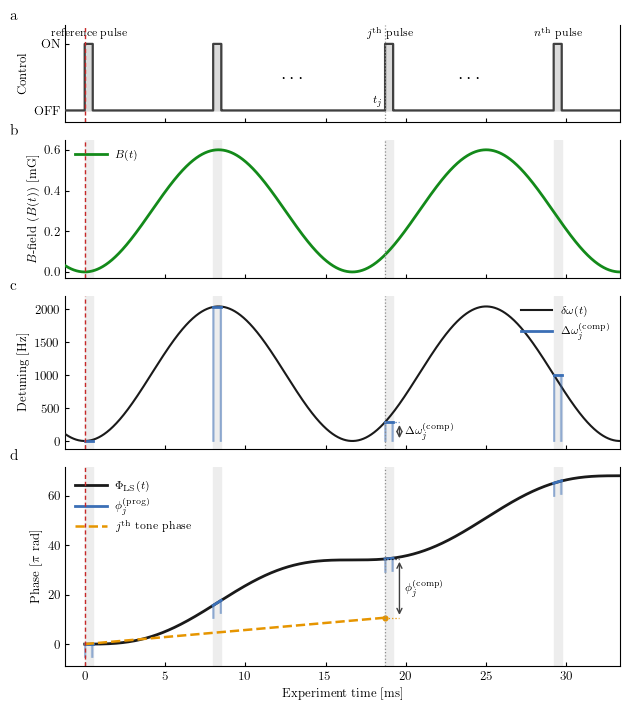

In [33]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import cumulative_trapezoid
from matplotlib import rcParams

rcParams.update({
    "font.family": "serif",
    "font.serif": ["Computer Modern Roman"],
    "text.usetex": True,
    "text.latex.preamble": r"\usepackage{amsmath}",
    "font.size": 9,
    "axes.linewidth": 0.8,
    "xtick.direction": "in",
    "ytick.direction": "in",
    "xtick.major.size": 3,
    "ytick.major.size": 3,
    "xtick.major.width": 0.8,
    "ytick.major.width": 0.8,
    "savefig.dpi": 300,
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
})

# =========================================================
# TOGGLES / USER SETTINGS
# =========================================================
SHOW_ANNOTATIONS = False
USE_TOY_BFIELD = True
SHOW_LINE_TRIGGER = False

# Laser-edge styling for pulse-only plotting
SHOW_LASER_EDGE_DROPS = True
PHASE_DROP_HEIGHT_PI = 5.2      # visual drop height in units of pi rad
# DETUNING_DROP_FRACTION = 1.0   # 1.0 = full drop from 0 to delta_seg
EDGE_FADE_STEPS = 6
EDGE_FADE_WIDTH_MS = 0.10
EDGE_FADE_ALPHA = 0.28

# NEW:
# If True, show the blue laser detuning / laser phase only during pulse ON windows.
# If False, show the continuous conceptual version across the full sequence.
SHOW_LASER_ONLY_DURING_PULSES = True

pre_trigger_duration = 1.2e-3   # [s]
trigger_width = 0.35e-3         # [s]

# =========================================================
# GLOBAL PARAMETERS
# =========================================================
fs = 200000
duration = 33330e-6
gamma = 3.4e3   # Hz / mG

# =========================================================
# USER-CONTROLLED PULSE LAYOUT
# =========================================================
pulse_times_ms = [
    0.00,   # reference pulse
    8.00,
    18.70,  # jth pulse
    29.20,  # nth pulse
]

pulse_width_ms = 0.50
# Example:
# pulse_width_ms = [0.50, 0.50, 0.70, 0.50]

j_pulse_index = 2

ref_pulse_index = 0
n_pulse_index = len(pulse_times_ms) - 1

dot_positions_ms = [13.0, 24.0]
dots_y = 0.52

custom_pulse_labels = {
    ref_pulse_index: r"reference pulse",
    j_pulse_index: r"$j^{\mathrm{th}}$ pulse",
    n_pulse_index: r"$n^{\mathrm{th}}$ pulse",
}

# first pulse is the reference; compensation updates start from next pulse
first_update_index = 1

# =========================================================
# CONVERT TO SI UNITS + VALIDATE
# =========================================================
pulse_times = 1e-3 * np.array(pulse_times_ms, dtype=float)

if np.isscalar(pulse_width_ms):
    pulse_widths = np.full(len(pulse_times), 1e-3 * float(pulse_width_ms), dtype=float)
else:
    pulse_widths = 1e-3 * np.array(pulse_width_ms, dtype=float)
    if len(pulse_widths) != len(pulse_times):
        raise ValueError("pulse_width_ms must be a scalar or a list with one entry per pulse.")

pulse_ends = pulse_times + pulse_widths

if len(pulse_times) < 3:
    raise ValueError("Use at least 3 pulses so the schematic can show reference, jth, and nth pulse.")

if np.any(np.diff(pulse_times) < 0):
    raise ValueError("pulse_times_ms must be sorted in increasing order.")

if np.any(pulse_ends > duration):
    raise ValueError("A pulse ends after the total sequence duration.")

if not (0 <= ref_pulse_index < len(pulse_times)):
    raise ValueError("ref_pulse_index is out of range.")

if not (0 <= j_pulse_index < len(pulse_times)):
    raise ValueError("j_pulse_index is out of range.")

if not (0 <= n_pulse_index < len(pulse_times)):
    raise ValueError("n_pulse_index is out of range.")

if ref_pulse_index == j_pulse_index or j_pulse_index == n_pulse_index or ref_pulse_index == n_pulse_index:
    raise ValueError("reference, jth, and nth pulses must be different.")

if not (ref_pulse_index < j_pulse_index < n_pulse_index):
    raise ValueError("Require ref_pulse_index < j_pulse_index < n_pulse_index.")

# =========================================================
# HELPERS
# =========================================================
def padded_limits(y, low_pad=0.08, high_pad=0.08):
    y = np.asarray(y)
    ymin = np.min(y)
    ymax = np.max(y)
    span = ymax - ymin
    if np.isclose(span, 0):
        span = max(abs(ymax), 1.0)
    return ymin - low_pad * span, ymax + high_pad * span

label_box = dict(boxstyle="round,pad=0.20", fc="white", ec="none", alpha=0.92)

def draw_faded_vertical(ax, x, y0, y1, color, lw=1.2, steps=6, width_ms=0.10, alpha_max=0.28, direction="right", zorder=3):
    """
    Draw a soft vertical edge by stacking several nearby vertical lines
    with decreasing alpha.

    direction = "right"  -> fade extends to increasing x
    direction = "left"   -> fade extends to decreasing x
    """
    denom = max(steps - 1, 1)
    for k in range(steps):
        dx = width_ms * k / denom
        if direction == "left":
            dx = -dx
        alpha = alpha_max * (1 - k / denom)
        ax.plot(
            [x + dx, x + dx],
            [y0, y1],
            color=color,
            lw=lw,
            alpha=alpha,
            zorder=zorder,
        )

# =========================================================
# TIME AXES
# =========================================================
t_full = np.linspace(
    -pre_trigger_duration,
    duration,
    int(fs * (duration + pre_trigger_duration)),
    endpoint=False
)
t_full_ms = 1e3 * t_full

t = np.linspace(0, duration, int(fs * duration), endpoint=False)
t_ms = 1e3 * t

# =========================================================
# FIELD / DETUNING
# =========================================================
if USE_TOY_BFIELD:
    B_t_full = -0.3 * np.cos(2 * np.pi * 60 * t_full) + 0.3
else:
    B_t_full = B_rel_line_mG(t_full)

# Reference to line trigger at t=0
B_t_full = B_t_full - np.interp(0.0, t_full, B_t_full)

delta_ion_full = gamma * B_t_full   # [Hz]

B_t = np.interp(t, t_full, B_t_full)
delta_ion = gamma * B_t
phi_ion = 2 * np.pi * cumulative_trapezoid(delta_ion, t, initial=0)   # [rad]

delta_pulses = np.interp(pulse_times, t, delta_ion)
phi_pulses = np.interp(pulse_times, t, phi_ion)

# =========================================================
# CONTINUOUS CONCEPTUAL LASER DETUNING
# =========================================================
laser_detuning_full = np.zeros_like(t_full)

for j in range(first_update_index, len(pulse_times)):
    t0 = pulse_times[j]
    t1 = pulse_times[j + 1] if j + 1 < len(pulse_times) else duration
    if j + 1 < len(pulse_times):
        mask = (t_full >= t0) & (t_full < t1)
    else:
        mask = (t_full >= t0) & (t_full <= t1)
    laser_detuning_full[mask] = delta_pulses[j]

# =========================================================
# CONTINUOUS CONCEPTUAL PROGRAMMED PHASE
# =========================================================
phase_t_plot = [0.0]
phase_laser_plot = [0.0]

current_t = 0.0
current_phi = 0.0
current_detuning = 0.0

update_times = pulse_times[first_update_index:]

for k, t_update in enumerate(update_times):
    phi_before = current_phi + 2 * np.pi * current_detuning * (t_update - current_t)

    phase_t_plot.extend([t_update])
    phase_laser_plot.extend([phi_before])

    pulse_idx = first_update_index + k
    phi_snap = phi_pulses[pulse_idx]

    phase_t_plot.extend([t_update])
    phase_laser_plot.extend([phi_snap])

    current_t = t_update
    current_phi = phi_snap
    current_detuning = delta_pulses[pulse_idx]

phi_end = current_phi + 2 * np.pi * current_detuning * (duration - current_t)
phase_t_plot.extend([duration])
phase_laser_plot.extend([phi_end])

phase_t_plot = 1e3 * np.array(phase_t_plot)   # [ms]
phase_laser_plot = np.array(phase_laser_plot) # [rad]

# =========================================================
# PULSE-ONLY LASER DETUNING / PHASE SEGMENTS
# =========================================================
laser_detuning_pulse_only = np.full_like(t_full, np.nan)

pulse_phase_segments = []
pulse_detuning_segments = []

for j, (t0, t1) in enumerate(zip(pulse_times, pulse_ends)):
    if j < first_update_index:
        delta_seg = 0.0
        phi_start_seg = 0.0
    else:
        delta_seg = delta_pulses[j]
        phi_start_seg = phi_pulses[j]

    # pulse-only detuning shown only while laser is ON
    if j < len(pulse_times) - 1:
        mask = (t_full >= t0) & (t_full < t1)
    else:
        mask = (t_full >= t0) & (t_full <= t1)
    laser_detuning_pulse_only[mask] = delta_seg

    # pulse-only phase segment shown only while laser is ON
    nseg = max(40, int(fs * (t1 - t0)))
    t_seg = np.linspace(t0, t1, nseg, endpoint=True)
    phi_seg = phi_start_seg + 2 * np.pi * delta_seg * (t_seg - t0)

    pulse_phase_segments.append((1e3 * t_seg, phi_seg / np.pi))
    pulse_detuning_segments.append((1e3 * np.array([t0, t1]), np.array([delta_seg, delta_seg])))

# =========================================================
# JTH-TONE LINEAR PHASE IN THE ω0 FRAME
# =========================================================
t_j = pulse_times[j_pulse_index]
t_j_ms = 1e3 * t_j
delta_j = delta_pulses[j_pulse_index]

mask_j = t <= t_j
t_for_j_phase = t[mask_j]
phi_j_linear = 2 * np.pi * delta_j * t_for_j_phase   # [rad]

phi_ls_tj = np.interp(t_j, t, phi_ion)               # [rad]
phi_j_tone_tj = 2 * np.pi * delta_j * t_j            # [rad]

# =========================================================
# CONTROL PANEL SIGNALS
# =========================================================
laser_on_full = np.zeros_like(t_full)
for t0, t1 in zip(pulse_times, pulse_ends):
    laser_on_full[(t_full >= t0) & (t_full < t1)] = 1

trigger_on_full = np.zeros_like(t_full)
trigger_on_full[(t_full >= -trigger_width) & (t_full < 0)] = 1

# =========================================================
# COLORS
# =========================================================
c_B = "#138A1A"
c_ion = "0.10"
c_laser = "#3B6FB6"
c_jphase = "#E69500"
c_trigger = "#C62828"
c_trigger_fill = "#F3C7C7"
c_tj = "0.55"

# =========================================================
# PLOT
# =========================================================
fig, axs = plt.subplots(
    4, 1,
    figsize=(6.6, 7.2),
    sharex=True,
    gridspec_kw={"height_ratios": [0.95, 1.35, 1.50, 1.95]}
)

# ---------------------------------------------------------
# Panel 1: control sequence
# ---------------------------------------------------------
ax = axs[0]

ax.step(t_full_ms, laser_on_full, where="post", color="0.25", lw=1.6, zorder=3)
ax.fill_between(t_full_ms, 0, laser_on_full, step="post", color="0.86", zorder=2)

if SHOW_LINE_TRIGGER:
    ax.step(t_full_ms, trigger_on_full, where="post", color=c_trigger, lw=1.5, zorder=4)
    ax.fill_between(t_full_ms, 0, trigger_on_full, step="post", color=c_trigger_fill, zorder=1)

ax.set_ylim(-0.18, 1.28)
ax.set_yticks([0, 1])
ax.set_yticklabels([r"OFF", r"ON"])
ax.set_ylabel(r"Control")

for idx, txt in custom_pulse_labels.items():
    x_center = 1e3 * (pulse_times[idx] + 0.5 * pulse_widths[idx])
    ax.text(x_center, 1.08, txt, ha="center", va="bottom", fontsize=8)

ax.text(1e3 * pulse_times[j_pulse_index] - 0.5, 0.20, r"$t_j$", ha="center", va="top", fontsize=8)

for xdot in dot_positions_ms:
    ax.text(xdot, dots_y, r"$\cdots$", ha="center", va="center", fontsize=14)

# ---------------------------------------------------------
# Panel 2: B field
# ---------------------------------------------------------
ax = axs[1]

ax.plot(
    t_full_ms, B_t_full,
    color=c_B, lw=2.0,
    label=r"$B(t)$", zorder=3
)

ax.set_ylabel(r"$B$-field ($B(t)$) [mG]")
ax.set_ylim(*padded_limits(B_t_full, low_pad=0.05, high_pad=0.08))
ax.legend(loc="upper left", frameon=False, fontsize=8, handlelength=2.8)

# ---------------------------------------------------------
# Panel 3: detuning
# ---------------------------------------------------------
ax = axs[2]

ax.plot(
    t_full_ms, delta_ion_full,
    color=c_ion, lw=1.5,
    label=r"$\delta\omega(t)$", zorder=3
)

if SHOW_LASER_ONLY_DURING_PULSES:
    first = True

    for j, (t0, t1) in enumerate(zip(pulse_times, pulse_ends)):
        if j < first_update_index:
            delta_seg = 0.0
        else:
            delta_seg = delta_pulses[j]

        x0 = 1e3 * t0
        x1 = 1e3 * t1

        # horizontal segment only while laser is ON
        ax.plot(
            [x0, x1], [delta_seg, delta_seg],
            color=c_laser, lw=2.0,
            label=r"$\Delta\omega_j^{(\mathrm{comp})}$" if first else "_nolegend_",
            zorder=4
        )

        # soft turn-on / turn-off edges, fading to zero
        if SHOW_LASER_EDGE_DROPS and not np.isclose(delta_seg, 0.0):
            draw_faded_vertical(
                ax, x0, 0.0, delta_seg, c_laser,
                lw=1.2, steps=EDGE_FADE_STEPS,
                width_ms=EDGE_FADE_WIDTH_MS,
                alpha_max=EDGE_FADE_ALPHA,
                direction="right", zorder=3
            )
            draw_faded_vertical(
                ax, x1, delta_seg, 0.0, c_laser,
                lw=1.2, steps=EDGE_FADE_STEPS,
                width_ms=EDGE_FADE_WIDTH_MS,
                alpha_max=EDGE_FADE_ALPHA,
                direction="left", zorder=3
            )

        first = False

    ylim_data = np.r_[delta_ion_full, [0.0], delta_pulses[first_update_index:]]

else:
    ax.step(
        t_full_ms, laser_detuning_full,
        where="post",
        color=c_laser, lw=2.0,
        label=r"$\Delta\omega_j^{(\mathrm{comp})}$", zorder=4
    )
    ylim_data = np.r_[delta_ion_full, laser_detuning_full]

# detuning arrow at t_j
x_arrow_det = t_j_ms + 0.9

ax.plot(
    [t_j_ms, x_arrow_det],
    [delta_j, delta_j],
    linestyle=":", lw=0.9, color=c_laser, zorder=6
)

ax.annotate(
    "",
    xy=(x_arrow_det, delta_j),
    xytext=(x_arrow_det, 0.0),
    arrowprops=dict(arrowstyle="<->", lw=1.0, color="0.25"),
    zorder=7,
)

ax.text(
    x_arrow_det + 0.35,
    0.5 * delta_j,
    r"$\Delta\omega_j^{(\mathrm{comp})}$",
    ha="left",
    va="center",
    fontsize=8,
)

ax.set_ylabel(r"Detuning [Hz]")
ax.set_ylim(*padded_limits(ylim_data, low_pad=0.06, high_pad=0.08))
ax.legend(loc="upper right", frameon=False, fontsize=8, handlelength=2.8)

# ---------------------------------------------------------
# Panel 4: phase
# ---------------------------------------------------------
ax = axs[3]

ax.plot(
    t_ms, phi_ion / np.pi,
    color=c_ion, lw=2.0,
    label=r"$\Phi_{\mathrm{LS}}(t)$", zorder=3
)

if SHOW_LASER_ONLY_DURING_PULSES:
    first = True
    for xseg, yseg in pulse_phase_segments:
        ax.plot(
            xseg, yseg,
            color=c_laser, lw=2.0,
            label=r"$\phi_j^{(\mathrm{prog})}$" if first else "_nolegend_",
            zorder=4
        )

        if SHOW_LASER_EDGE_DROPS:
            x0, x1 = xseg[0], xseg[-1]
            y0, y1 = yseg[0], yseg[-1]

            draw_faded_vertical(
                ax, x0, y0 - PHASE_DROP_HEIGHT_PI, y0, c_laser,
                lw=1.2, steps=EDGE_FADE_STEPS,
                width_ms=EDGE_FADE_WIDTH_MS,
                alpha_max=EDGE_FADE_ALPHA,
                direction="right", zorder=3
            )
            draw_faded_vertical(
                ax, x1, y1, y1 - PHASE_DROP_HEIGHT_PI, c_laser,
                lw=1.2, steps=EDGE_FADE_STEPS,
                width_ms=EDGE_FADE_WIDTH_MS,
                alpha_max=EDGE_FADE_ALPHA,
                direction="left", zorder=3
            )

        first = False
else:
    ax.plot(
        phase_t_plot, phase_laser_plot / np.pi,
        color=c_laser, lw=2.0,
        label=r"$\phi_j^{(\mathrm{prog})}$", zorder=4
    )

ax.plot(
    1e3 * t_for_j_phase, phi_j_linear / np.pi,
    color=c_jphase, lw=1.8, linestyle="--",
    label=r"$j^{\mathrm{th}}$ tone phase", zorder=5
)

ax.plot(
    [t_j_ms],
    [phi_j_tone_tj / np.pi],
    marker="o", ms=3.4, color=c_jphase, zorder=6
)

# phase-compensation arrow
x_arrow = t_j_ms + 0.9

ax.plot(
    [t_j_ms, x_arrow],
    [phi_ls_tj / np.pi, phi_ls_tj / np.pi],
    linestyle=":", lw=0.9, color=c_ion, zorder=6
)
ax.plot(
    [t_j_ms, x_arrow],
    [phi_j_tone_tj / np.pi, phi_j_tone_tj / np.pi],
    linestyle=":", lw=0.9, color=c_jphase, zorder=6
)

ax.annotate(
    "",
    xy=(x_arrow, phi_ls_tj / np.pi),
    xytext=(x_arrow, phi_j_tone_tj / np.pi),
    arrowprops=dict(arrowstyle="<->", lw=1.0, color="0.25"),
    zorder=7,
)

ax.text(
    x_arrow + 0.35,
    0.5 * (phi_ls_tj + phi_j_tone_tj) / np.pi,
    r"$\phi_j^{(\mathrm{comp})}$",
    ha="left",
    va="center",
    fontsize=8,
)

ax.set_ylabel(r"Phase [$\pi$ rad]")
ax.set_xlabel(r"Experiment time [ms]")
ax.legend(loc="upper left", bbox_to_anchor=(0.00, 0.98), frameon=False, fontsize=8, handlelength=2.8)

# =========================================================
# SHARED STYLING
# =========================================================
for i, ax in enumerate(axs):
    if i > 0:
        for t0, t1 in zip(pulse_times, pulse_ends):
            ax.axvspan(1e3 * t0, 1e3 * t1, color="0.93", zorder=0)

    ax.axvline(0.0, color=c_trigger, lw=1.0, linestyle=(0, (3, 2)), zorder=6)
    ax.axvline(t_j_ms, color=c_tj, lw=0.9, linestyle=":", zorder=6)

    ax.spines["top"].set_visible(False)
    ax.text(
        -0.10, 1.02, chr(ord("a") + i),
        transform=ax.transAxes,
        fontsize=11,
        fontweight="bold",
        va="bottom"
    )

for ax in axs:
    ax.set_xlim(t_full_ms[0], t_full_ms[-1])

# =========================================================
# OPTIONAL ANNOTATIONS
# =========================================================
if SHOW_ANNOTATIONS:
    axs[3].annotate(
        r"$t_j\,\delta\omega(t_j)$ in the $\omega_0$ frame",
        xy=(t_j_ms, phi_j_tone_tj / np.pi),
        xytext=(t_j_ms - 8.0, phi_j_tone_tj / np.pi - 8),
        arrowprops=dict(arrowstyle="->", lw=0.8, color=c_jphase),
        fontsize=8,
        bbox=label_box,
    )

plt.subplots_adjust(left=0.13, right=0.97, top=0.98, bottom=0.09, hspace=0.12)
plt.savefig("Line_signal_Compensation_Figure1_explanation.pdf", bbox_inches="tight")
plt.show()

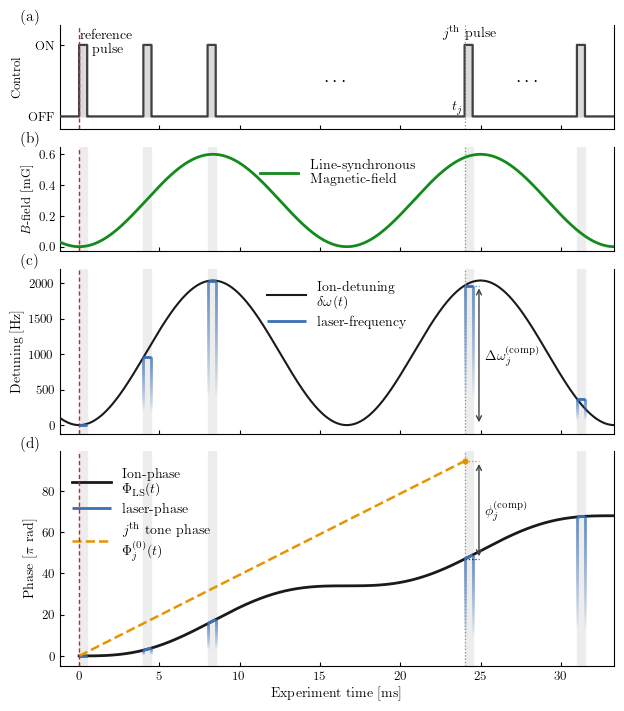

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import cumulative_trapezoid
from matplotlib import rcParams

rcParams.update({
    "font.family": "serif",
    "font.serif": ["Computer Modern Roman"],
    "text.usetex": True,
    "text.latex.preamble": r"\usepackage{amsmath}",
    "font.size": 9,
    "axes.linewidth": 0.8,
    "xtick.direction": "in",
    "ytick.direction": "in",
    "xtick.major.size": 3,
    "ytick.major.size": 3,
    "xtick.major.width": 0.8,
    "ytick.major.width": 0.8,
    "savefig.dpi": 300,
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
})

# =========================================================
# TOGGLES / USER SETTINGS
# =========================================================
SHOW_ANNOTATIONS = False
USE_TOY_BFIELD = True
SHOW_LINE_TRIGGER = False

SHOW_LASER_ONLY_DURING_PULSES = True

# Gradient edge styling
SHOW_LASER_EDGE_GRADIENT = True
EDGE_GRADIENT_STEPS = 1000
EDGE_ALPHA_MIN = 0.0
EDGE_ALPHA_MAX = 1.0
EDGE_GRADIENT_GAMMA = 1.0
LASER_LW = 2.0

# Visual phase drop height, in units of pi rad.
# This controls how far the phase trace visually fades downward when the laser turns off.
# PHASE_DROP_HEIGHT_PI = 15.2
EDGE_FRACTION_TO_ZERO = 0.80   # transparent end is 80% of the way toward zero
pre_trigger_duration = 1.2e-3   # [s]
trigger_width = 0.35e-3         # [s]

# =========================================================
# GLOBAL PARAMETERS
# =========================================================
fs = 200000
duration = 33330e-6
gamma = 3.4e3   # Hz / mG

# =========================================================
# USER-CONTROLLED PULSE LAYOUT
# =========================================================
pulse_times_ms = [
    0.00,   # reference pulse
    4.00,
    8.00,
    24.00,  # jth pulse
    31.00,  # nth pulse
]

pulse_width_ms = 0.50

j_pulse_index = 3

ref_pulse_index = 0
n_pulse_index = len(pulse_times_ms) - 1

dot_positions_ms = [16.0, 28.0]
dots_y = 0.52

custom_pulse_labels = {
    ref_pulse_index: "reference \n pulse",
    j_pulse_index: r"$j^{\mathrm{th}}$ pulse",
    # n_pulse_index: r"$n^{\mathrm{th}}$ pulse",
    n_pulse_index: "",
}

# first pulse is the reference; compensation updates start from next pulse
first_update_index = 1

# =========================================================
# CONVERT TO SI UNITS + VALIDATE
# =========================================================
pulse_times = 1e-3 * np.array(pulse_times_ms, dtype=float)

if np.isscalar(pulse_width_ms):
    pulse_widths = np.full(len(pulse_times), 1e-3 * float(pulse_width_ms), dtype=float)
else:
    pulse_widths = 1e-3 * np.array(pulse_width_ms, dtype=float)
    if len(pulse_widths) != len(pulse_times):
        raise ValueError("pulse_width_ms must be a scalar or a list with one entry per pulse.")

pulse_ends = pulse_times + pulse_widths

if len(pulse_times) < 3:
    raise ValueError("Use at least 3 pulses so the schematic can show reference, jth, and nth pulse.")

if np.any(np.diff(pulse_times) < 0):
    raise ValueError("pulse_times_ms must be sorted in increasing order.")

if np.any(pulse_ends > duration):
    raise ValueError("A pulse ends after the total sequence duration.")

if not (0 <= ref_pulse_index < len(pulse_times)):
    raise ValueError("ref_pulse_index is out of range.")

if not (0 <= j_pulse_index < len(pulse_times)):
    raise ValueError("j_pulse_index is out of range.")

if not (0 <= n_pulse_index < len(pulse_times)):
    raise ValueError("n_pulse_index is out of range.")

if ref_pulse_index == j_pulse_index or j_pulse_index == n_pulse_index or ref_pulse_index == n_pulse_index:
    raise ValueError("reference, jth, and nth pulses must be different.")

if not (ref_pulse_index < j_pulse_index < n_pulse_index):
    raise ValueError("Require ref_pulse_index < j_pulse_index < n_pulse_index.")

# =========================================================
# HELPERS
# =========================================================
def padded_limits(y, low_pad=0.08, high_pad=0.08):
    y = np.asarray(y)
    ymin = np.nanmin(y)
    ymax = np.nanmax(y)
    span = ymax - ymin
    if np.isclose(span, 0):
        span = max(abs(ymax), 1.0)
    return ymin - low_pad * span, ymax + high_pad * span


label_box = dict(boxstyle="round,pad=0.20", fc="white", ec="none", alpha=0.92)


def draw_vertical_alpha_gradient(
    ax,
    x,
    y_transparent,
    y_dark,
    color,
    lw=2.0,
    steps=48,
    alpha_min=0.0,
    alpha_max=1.0,
    gamma=1.0,
    zorder=4,
):
    """
    Draw one vertical edge with alpha gradient.

    The edge is almost transparent near y_transparent
    and dark near y_dark.
    """
    ys = np.linspace(y_transparent, y_dark, steps + 1)

    for k in range(steps):
        progress = (k + 1) / steps
        alpha = alpha_min + (alpha_max - alpha_min) * progress**gamma

        ax.plot(
            [x, x],
            [ys[k], ys[k + 1]],
            color=color,
            lw=lw,
            alpha=alpha,
            solid_capstyle="butt",
            zorder=zorder,
        )


def draw_laser_segment_with_vertical_gradient(
    ax,
    x0,
    x1,
    y_on_start,
    y_on_end,
    y_off_start,
    y_off_end,
    color,
    label=None,
    lw=2.0,
    steps=48,
    alpha_min=0.0,
    alpha_max=1.0,
    gamma=1.0,
    zorder=4,
):
    """
    Draw a laser-on segment.

    - left edge fades from off -> on
    - middle is dark blue while the laser is on
    - right edge fades from on -> off

    For detuning, y_on_start = y_on_end and y_off_start = y_off_end = 0.
    For phase, y_on_start and y_on_end can differ because the phase ramps.
    """
    if SHOW_LASER_EDGE_GRADIENT:
        draw_vertical_alpha_gradient(
            ax,
            x0,
            y_off_start,
            y_on_start,
            color,
            lw=lw,
            steps=steps,
            alpha_min=alpha_min,
            alpha_max=alpha_max,
            gamma=gamma,
            zorder=zorder,
        )
    # if label is not None:
    ax.plot(
        [x0, x1],
        [y_on_start, y_on_end],
        color=color,
        lw=lw,
        alpha=alpha_max,
        solid_capstyle="butt",
        label=label,
        zorder=zorder + 1,
    )

    if SHOW_LASER_EDGE_GRADIENT:
        draw_vertical_alpha_gradient(
            ax,
            x1,
            y_off_end,
            y_on_end,
            color,
            lw=lw,
            steps=steps,
            alpha_min=alpha_min,
            alpha_max=alpha_max,
            gamma=gamma,
            zorder=zorder,
        )

# =========================================================
# TIME AXES
# =========================================================
t_full = np.linspace(
    -pre_trigger_duration,
    duration,
    int(fs * (duration + pre_trigger_duration)),
    endpoint=False
)
t_full_ms = 1e3 * t_full

t = np.linspace(0, duration, int(fs * duration), endpoint=False)
t_ms = 1e3 * t

# =========================================================
# FIELD / DETUNING
# =========================================================
if USE_TOY_BFIELD:
    B_t_full = -0.3 * np.cos(2 * np.pi * 60 * t_full) + 0.3
else:
    B_t_full = B_rel_line_mG(t_full)

# Reference to line trigger at t=0
B_t_full = B_t_full - np.interp(0.0, t_full, B_t_full)

delta_ion_full = gamma * B_t_full   # [Hz]

B_t = np.interp(t, t_full, B_t_full)
delta_ion = gamma * B_t
phi_ion = 2 * np.pi * cumulative_trapezoid(delta_ion, t, initial=0)   # [rad]

delta_pulses = np.interp(pulse_times, t, delta_ion)
phi_pulses = np.interp(pulse_times, t, phi_ion)

# =========================================================
# CONTINUOUS CONCEPTUAL LASER DETUNING
# =========================================================
laser_detuning_full = np.zeros_like(t_full)

for j in range(first_update_index, len(pulse_times)):
    t0 = pulse_times[j]
    t1 = pulse_times[j + 1] if j + 1 < len(pulse_times) else duration
    if j + 1 < len(pulse_times):
        mask = (t_full >= t0) & (t_full < t1)
    else:
        mask = (t_full >= t0) & (t_full <= t1)
    laser_detuning_full[mask] = delta_pulses[j]

# =========================================================
# CONTINUOUS CONCEPTUAL PROGRAMMED PHASE
# =========================================================
phase_t_plot = [0.0]
phase_laser_plot = [0.0]

current_t = 0.0
current_phi = 0.0
current_detuning = 0.0

update_times = pulse_times[first_update_index:]

for k, t_update in enumerate(update_times):
    phi_before = current_phi + 2 * np.pi * current_detuning * (t_update - current_t)

    phase_t_plot.extend([t_update])
    phase_laser_plot.extend([phi_before])

    pulse_idx = first_update_index + k
    phi_snap = phi_pulses[pulse_idx]

    phase_t_plot.extend([t_update])
    phase_laser_plot.extend([phi_snap])

    current_t = t_update
    current_phi = phi_snap
    current_detuning = delta_pulses[pulse_idx]

phi_end = current_phi + 2 * np.pi * current_detuning * (duration - current_t)
phase_t_plot.extend([duration])
phase_laser_plot.extend([phi_end])

phase_t_plot = 1e3 * np.array(phase_t_plot)   # [ms]
phase_laser_plot = np.array(phase_laser_plot) # [rad]

# =========================================================
# PULSE-ONLY LASER PHASE SEGMENTS
# =========================================================
pulse_phase_segments = []

for j, (t0, t1) in enumerate(zip(pulse_times, pulse_ends)):
    if j < first_update_index:
        delta_seg = 0.0
        phi_start_seg = 0.0
    else:
        delta_seg = delta_pulses[j]
        phi_start_seg = phi_pulses[j]

    nseg = max(40, int(fs * (t1 - t0)))
    t_seg = np.linspace(t0, t1, nseg, endpoint=True)
    phi_seg = phi_start_seg + 2 * np.pi * delta_seg * (t_seg - t0)

    pulse_phase_segments.append((j, 1e3 * t_seg, phi_seg / np.pi))

# =========================================================
# JTH-TONE LINEAR PHASE IN THE omega_0 FRAME
# =========================================================
t_j = pulse_times[j_pulse_index]
t_j_ms = 1e3 * t_j
delta_j = delta_pulses[j_pulse_index]

mask_j = t <= t_j
t_for_j_phase = t[mask_j]
phi_j_linear = 2 * np.pi * delta_j * t_for_j_phase   # [rad]

phi_ls_tj = np.interp(t_j, t, phi_ion)               # [rad]
phi_j_tone_tj = 2 * np.pi * delta_j * t_j            # [rad]

# =========================================================
# CONTROL PANEL SIGNALS
# =========================================================
laser_on_full = np.zeros_like(t_full)
for t0, t1 in zip(pulse_times, pulse_ends):
    laser_on_full[(t_full >= t0) & (t_full < t1)] = 1

trigger_on_full = np.zeros_like(t_full)
trigger_on_full[(t_full >= -trigger_width) & (t_full < 0)] = 1

# =========================================================
# COLORS
# =========================================================
c_B = "#138A1A"
c_ion = "0.10"
c_laser = "#3B6FB6"
c_jphase = "#E69500"
c_trigger = "#C62828"
c_trigger_fill = "#F3C7C7"
c_tj = "0.55"

# =========================================================
# PLOT
# =========================================================
fig, axs = plt.subplots(
    4, 1,
    figsize=(6.6, 7.2),
    sharex=True,
    gridspec_kw={"height_ratios": [0.95, 0.95, 1.50, 1.95]}
)

# ---------------------------------------------------------
# Panel 1: control sequence
# ---------------------------------------------------------
ax = axs[0]

ax.step(t_full_ms, laser_on_full, where="post", color="0.25", lw=1.6, zorder=3)
ax.fill_between(t_full_ms, 0, laser_on_full, step="post", color="0.86", zorder=2)

if SHOW_LINE_TRIGGER:
    ax.step(t_full_ms, trigger_on_full, where="post", color=c_trigger, lw=1.5, zorder=4)
    ax.fill_between(t_full_ms, 0, trigger_on_full, step="post", color=c_trigger_fill, zorder=1)

ax.set_ylim(-0.18, 1.28)
ax.set_yticks([0, 1])
ax.set_yticklabels([r"OFF", r"ON"])
ax.set_ylabel(r"Control")

# for idx, txt in custom_pulse_labels.items():
#     x_center = 1e3 * (pulse_times[idx] + 0.5 * pulse_widths[idx])
#     ax.text(x_center, 1.08, txt, ha="center", va="bottom", fontsize=8)

for idx, txt in custom_pulse_labels.items():
    if idx == 0:
        x_center = 1e3 * (pulse_times[idx] + 3.5 * pulse_widths[idx])
        ax.text(x_center, 0.85, txt, ha="center", va="bottom", fontsize=10)
    else:
        x_center = 1e3 * (pulse_times[idx] + 0.5 * pulse_widths[idx])
        ax.text(x_center, 1.08, txt, ha="center", va="bottom", fontsize=10)

ax.text(1e3 * pulse_times[j_pulse_index] - 0.5, 0.20, r"$t_j$", ha="center", va="top", fontsize=10)

for xdot in dot_positions_ms:
    ax.text(xdot, dots_y, r"$\cdots$", ha="center", va="center", fontsize=14)

# ---------------------------------------------------------
# Panel 2: B field
# ---------------------------------------------------------
ax = axs[1]

ax.plot(
    t_full_ms, B_t_full,
    color=c_B, lw=2.0,
    # label=r"$B(t)$", 
    label="Line-synchronous \n Magnetic-field",
    zorder=3
)

ax.set_ylabel(r"$B$-field [mG]")
ax.set_ylim(*padded_limits(B_t_full, low_pad=0.05, high_pad=0.08))
ax.legend(loc="upper center", frameon=False, fontsize=10, handlelength=2.8)

# ---------------------------------------------------------
# Panel 3: detuning
# ---------------------------------------------------------
ax = axs[2]

ax.plot(
    t_full_ms, delta_ion_full,
    color=c_ion, lw=1.5,
    # label=r"$\delta\omega(t)$", 
    label="Ion-detuning" + "\n" + r"$\delta\omega(t)$",
    zorder=3
)

if SHOW_LASER_ONLY_DURING_PULSES:
    label_used = False

    for j, (t0, t1) in enumerate(zip(pulse_times, pulse_ends)):
        if j < first_update_index:
            delta_seg = 0.0
        else:
            delta_seg = delta_pulses[j]

        x0 = 1e3 * t0
        x1 = 1e3 * t1

        # label = r"$\Delta\omega_j^{(\mathrm{comp})}$" if not label_used else "_nolegend_"

        # draw_laser_segment_with_vertical_gradient(
        #     ax,
        #     x0=x0,
        #     x1=x1,
        #     y_on_start=delta_seg,
        #     y_on_end=delta_seg,
        #     y_off_start=0.0,
        #     y_off_end=0.0,
        #     color=c_laser,
        #     label=label,
        #     lw=LASER_LW,
        #     steps=EDGE_GRADIENT_STEPS,
        #     alpha_min=EDGE_ALPHA_MIN,
        #     alpha_max=EDGE_ALPHA_MAX,
        #     gamma=EDGE_GRADIENT_GAMMA,
        #     zorder=4,
        # )

        y_off = delta_seg * (1.0 - EDGE_FRACTION_TO_ZERO)
        if j == 0:
            label = r"laser-frequency"#r"$\Delta\omega_j^{(\mathrm{comp})}$" if not label_used else "_nolegend_"
        else:
            label = None
        draw_laser_segment_with_vertical_gradient(
            ax,
            x0=x0,
            x1=x1,
            y_on_start=delta_seg,
            y_on_end=delta_seg,
            y_off_start=y_off,
            y_off_end=y_off,
            color=c_laser,
            label=label,
            lw=LASER_LW,
            steps=EDGE_GRADIENT_STEPS,
            alpha_min=EDGE_ALPHA_MIN,
            alpha_max=EDGE_ALPHA_MAX,
            gamma=EDGE_GRADIENT_GAMMA,
            zorder=4,
        )

        label_used = True

    ylim_data = np.r_[delta_ion_full, [0.0], delta_pulses[first_update_index:]]

else:
    ax.step(
        t_full_ms, laser_detuning_full,
        where="post",
        color=c_laser, lw=LASER_LW,
        label=r"$\Delta\omega_j^{(\mathrm{comp})}$", zorder=4
    )
    ylim_data = np.r_[delta_ion_full, laser_detuning_full]

# detuning arrow at t_j
x_arrow_det = t_j_ms + 0.9

ax.plot(
    [t_j_ms, x_arrow_det],
    [delta_j, delta_j],
    linestyle=":", lw=0.9, color=c_laser, zorder=6
)

ax.annotate(
    "",
    xy=(x_arrow_det, delta_j),
    xytext=(x_arrow_det, 0.0),
    arrowprops=dict(arrowstyle="<->", lw=1.0, color="0.25"),
    zorder=7,
)

ax.text(
    x_arrow_det + 0.35,
    0.5 * delta_j,
    r"$\Delta\omega_j^{(\mathrm{comp})}$",
    ha="left",
    va="center",
    fontsize=10,
)

ax.set_ylabel(r"Detuning [Hz]", fontsize=10)
ax.set_ylim(*padded_limits(ylim_data, low_pad=0.06, high_pad=0.08))
ax.legend(loc="upper center", frameon=False, fontsize=10, handlelength=2.8)

# ---------------------------------------------------------
# Panel 4: phase
# ---------------------------------------------------------
ax = axs[3]

ax.plot(
    t_ms, phi_ion / np.pi,
    color=c_ion, lw=2.0,
    # label=r"$\Phi_{\mathrm{LS}}(t)$", 
    label = r"Ion-phase" + "\n" + r"$\Phi_{\mathrm{LS}}(t)$", 
    zorder=3
)

if SHOW_LASER_ONLY_DURING_PULSES:
    label_used = False

    for j, xseg, yseg in pulse_phase_segments:
        x0 = xseg[0]
        x1 = xseg[-1]

        y_on_start = yseg[0]
        y_on_end = yseg[-1]

        # y_off_start = y_on_start - PHASE_DROP_HEIGHT_PI
        # y_off_end = y_on_end - PHASE_DROP_HEIGHT_PI

        y_off_start = y_on_start * (1.0 - EDGE_FRACTION_TO_ZERO)
        y_off_end = y_on_end * (1.0 - EDGE_FRACTION_TO_ZERO)

        label = r"$\phi_j^{(\mathrm{prog})}$" if not label_used else "_nolegend_"
        label = r"laser-phase" if not label_used else None
        draw_laser_segment_with_vertical_gradient(
            ax,
            x0=x0,
            x1=x1,
            y_on_start=y_on_start,
            y_on_end=y_on_end,
            y_off_start=y_off_start,
            y_off_end=y_off_end,
            color=c_laser,
            label=label,
            lw=LASER_LW,
            steps=EDGE_GRADIENT_STEPS,
            alpha_min=EDGE_ALPHA_MIN,
            alpha_max=EDGE_ALPHA_MAX,
            gamma=EDGE_GRADIENT_GAMMA,
            zorder=4,
        )

        label_used = True

else:
    ax.plot(
        phase_t_plot, phase_laser_plot / np.pi,
        color=c_laser, lw=LASER_LW,
        label=r"$\phi_j^{(\mathrm{prog})}$", zorder=4
    )

ax.plot(
    1e3 * t_for_j_phase, phi_j_linear / np.pi,
    color=c_jphase, lw=1.8, linestyle="--",
    label=r"$j^{\mathrm{th}}$ tone phase" + "\n" + r"$\Phi_j^{(0)}(t)$", zorder=5
)

ax.plot(
    [t_j_ms],
    [phi_j_tone_tj / np.pi],
    marker="o", ms=3.4, color=c_jphase, zorder=6
)

# phase-compensation arrow
x_arrow = t_j_ms + 0.9

ax.plot(
    [t_j_ms, x_arrow],
    [phi_ls_tj / np.pi, phi_ls_tj / np.pi],
    linestyle=":", lw=0.9, color=c_ion, zorder=6
)
ax.plot(
    [t_j_ms, x_arrow],
    [phi_j_tone_tj / np.pi, phi_j_tone_tj / np.pi],
    linestyle=":", lw=0.9, color=c_jphase, zorder=6
)

ax.annotate(
    "",
    xy=(x_arrow, phi_ls_tj / np.pi),
    xytext=(x_arrow, phi_j_tone_tj / np.pi),
    arrowprops=dict(arrowstyle="<->", lw=1.0, color="0.25"),
    zorder=7,
)

ax.text(
    x_arrow + 0.35,
    0.5 * (phi_ls_tj + phi_j_tone_tj) / np.pi,
    r"$\phi_j^{(\mathrm{comp})}$",
    ha="left",
    va="center",
    fontsize=10,
)

ax.set_ylabel(r"Phase [$\pi$ rad]", fontsize=10)
ax.set_xlabel(r"Experiment time [ms]", fontsize=10)
ax.legend(loc="upper left", bbox_to_anchor=(0.00, 0.98), frameon=False, fontsize=10, handlelength=2.8)

# =========================================================
# SHARED STYLING
# =========================================================
for i, ax in enumerate(axs):
    if i > 0:
        for t0, t1 in zip(pulse_times, pulse_ends):
            ax.axvspan(1e3 * t0, 1e3 * t1, color="0.93", zorder=0)

    ax.axvline(0.0, color=c_trigger, lw=1.0, linestyle=(0, (3, 2)), zorder=6)
    ax.axvline(t_j_ms, color=c_tj, lw=0.9, linestyle=":", zorder=6)

    ax.spines["top"].set_visible(False)
    ax.text(
        -0.07, 1.0, "("+chr(ord("a") + i)+")",
        transform=ax.transAxes,
        fontsize=11,
        fontweight="bold",
        va="bottom"
    )

for ax in axs:
    ax.set_xlim(t_full_ms[0], t_full_ms[-1])

# =========================================================
# OPTIONAL ANNOTATIONS
# =========================================================
if SHOW_ANNOTATIONS:
    axs[3].annotate(
        r"$t_j\,\delta\omega(t_j)$ in the $\omega_0$ frame",
        xy=(t_j_ms, phi_j_tone_tj / np.pi),
        xytext=(t_j_ms - 8.0, phi_j_tone_tj / np.pi - 8),
        arrowprops=dict(arrowstyle="->", lw=0.8, color=c_jphase),
        fontsize=10,
        bbox=label_box,
    )

plt.subplots_adjust(left=0.13, right=0.97, top=0.98, bottom=0.09, hspace=0.12)
plt.savefig("Line_signal_Compensation_Figure1_explanation.pdf", bbox_inches="tight")
plt.savefig("Line_signal_Compensation_Figure1_explanation.svg", bbox_inches="tight")
plt.savefig("Line_signal_Compensation_Figure1_explanation.png", dpi=900, bbox_inches="tight")
plt.show()

20251206: fit 41 points using sensitivity -3.49923 MHz/G from Z:\Lab Data\D52_Calibration_Ba137\RFSoC_LineSignal_sweep_SelfRef
20260113: fit 123 points using sensitivity -3.49923 MHz/G from Z:\Lab Data\D52_Calibration_Ba137\RFSoC_LineSignal_sweep_SelfRef\20260113_good
20260212: fit 68 points using sensitivity -3.42017 MHz/G from Z:\Lab Data\D52_Calibration_Ba137\RFSoC_LineSignal_sweep_SelfRef\20260113_good
20260220: fit 64 points using sensitivity -3.42017 MHz/G from Z:\Lab Data\D52_Calibration_Ba137\RFSoC_LineSignal_sweep_SelfRef\20260113_good
20260318: fit 78 points using sensitivity -3.42017 MHz/G from Z:\Lab Data\D52_Calibration_Ba137\RFSoC_LineSignal_sweep_SelfRef\20260113_good
20260403: fit 151 points using sensitivity -3.42017 MHz/G from Z:\Lab Data\D52_Calibration_Ba137\RFSoC_LineSignal_sweep_SelfRef\20260113_good
20260514: fit 173 points using sensitivity -3.42017 MHz/G from Z:\Lab Data\D52_Calibration_Ba137\RFSoC_LineSignal_sweep_SelfRef\20260113_good
20260708: fit 90 points 

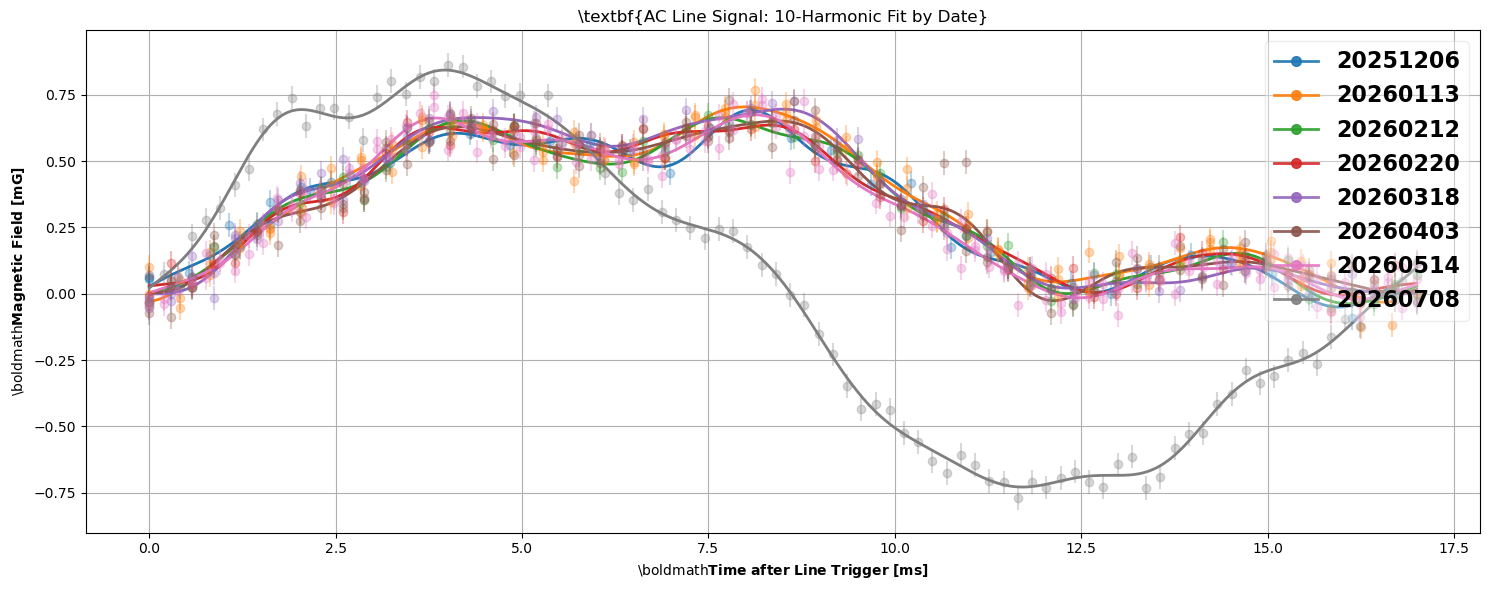

In [2]:
import ast
import os
import re
from pathlib import Path

import matplotlib.lines as mlines
import matplotlib.pyplot as plt
import numpy as np
from matplotlib import rcParams
from scipy.optimize import curve_fit


# --- CONFIGURATION ---
dates = [
    '20251206',
    '20260113',
    '20260212',
    '20260220',
    '20260318',
    '20260403',
    '20260514',
    '20260708'
]

# Magnetic-field sensitivity for the sensitive transition, one value per date.
sens_list_f1 = [-3.49923, -3.49923, -3.42017, -3.42017, -3.42017, -3.42017, -3.42017, -3.42017]  # [MHz/G]

erase_offset_list = [False, True, False, False, False, False, False, False]
fit_freqs = [60, 120, 180, 240, 300, 360, 420, 480, 540, 600]
base_data_dir = Path(r'Z:\Lab Data\D52_Calibration_Ba137\RFSoC_LineSignal_sweep_SelfRef')
extra_data_dirs = [
    Path.cwd(),
    Path.cwd() / 'line_signal_measurements',
    Path(r'Z:\Lab Data\D52_Calibration_Ba137\RFSoC_LineSignal_sweep_SelfRef\20260113_good'),
]
# ---------------------


def line_signal_model(t_us, *params):
    """10-harmonic line signal model. t_us is in microseconds; output is in mG."""
    t_s = np.asarray(t_us, dtype=float) * 1e-6
    y = np.full_like(t_s, params[0], dtype=float)

    for i, f_hz in enumerate(fit_freqs):
        A = params[1 + 2 * i]
        phi = params[1 + 2 * i + 1]
        y = y + A * np.cos(2 * np.pi * f_hz * t_s + phi)

    return y


def candidate_data_dirs(date):
    """Prefer date-specific folders when present, then fall back to the root folder."""
    candidates = [
        base_data_dir / date,
        base_data_dir / f'{date}_good',
        *extra_data_dirs,
        base_data_dir,
    ]

    try:
        for child in base_data_dir.iterdir():
            if child.is_dir() and date in child.name and child not in candidates:
                candidates.insert(-1, child)
    except OSError:
        pass

    seen = set()
    unique_candidates = []
    for candidate in candidates:
        candidate_key = str(candidate).lower()
        if candidate_key not in seen:
            unique_candidates.append(candidate)
            seen.add(candidate_key)

    return unique_candidates


def read_files_and_analyze(date, sensitivity, erase_offset=True):
    file_pattern = re.compile(
        rf'ramsey_reference_transitions_LTWait(\d+(?:\.\d+)?)us_'
        rf'Shots250_RamseyWait50us_{date}_.*'
    )

    rows = []
    matched_dirs = []
    seen_files = set()

    for data_dir in candidate_data_dirs(date):
        if not data_dir.exists():
            continue

        try:
            filenames = os.listdir(data_dir)
        except OSError as exc:
            print(f'Skipping {data_dir}: {exc}')
            continue

        for filename in filenames:
            if not file_pattern.match(filename):
                continue

            file_path = data_dir / filename
            file_key = str(file_path).lower()
            if file_key in seen_files:
                continue
            seen_files.add(file_key)

            try:
                with open(file_path, 'r') as file:
                    lines = file.readlines()

                lt_wait_us = float(lines[0].strip())
                freqs = ast.literal_eval(lines[1].strip())
                freqs_ref = ast.literal_eval(lines[3].strip())
                rows.append((lt_wait_us, freqs, freqs_ref))

                if data_dir not in matched_dirs:
                    matched_dirs.append(data_dir)
            except Exception as exc:
                print(f'Error reading {file_path}: {exc}')

    if not rows:
        print(f'No matching files found for {date}.')
        return None

    rows.sort(key=lambda row: row[0])
    times_us = np.array([row[0] for row in rows], dtype=float)
    freqs = np.array([row[1] for row in rows], dtype=float)
    freqs_ref = np.array([row[2] for row in rows], dtype=float)

    freq_diffs = np.diff(freqs)
    freq_ref_diff = np.diff(freqs_ref)
    detuning_delta = freq_ref_diff - freq_diffs

    if erase_offset:
        detuning_delta = detuning_delta - np.median(detuning_delta[0:3])

    y_noisy_pm = np.array(detuning_delta / sensitivity, dtype=float).flatten()

    if y_noisy_pm.size != times_us.size:
        raise ValueError(
            f'{date}: got {times_us.size} time values but {y_noisy_pm.size} field values. '
            'Check transition selection before flattening.'
        )

    B_mG = y_noisy_pm * 1000.0

    B0_0 = np.mean(B_mG)
    A_guess = 0.5 * (np.max(B_mG) - np.min(B_mG))
    if not np.isfinite(A_guess) or A_guess <= 0:
        A_guess = 0.01

    p0 = [B0_0]
    for i, _ in enumerate(fit_freqs):
        p0.extend([A_guess if i == 0 else 0.3 * A_guess, 0.0])

    lower_bounds = [-np.inf]
    upper_bounds = [np.inf]
    for _ in fit_freqs:
        lower_bounds.extend([0.0, -np.inf])
        upper_bounds.extend([np.inf, np.inf])

    params, covariance = curve_fit(
        line_signal_model,
        times_us,
        B_mG,
        p0=p0,
        bounds=(lower_bounds, upper_bounds),
        maxfev=50000,
    )

    t_fit_us = np.linspace(times_us.min(), times_us.max(), 2000)
    B_fit_mG = line_signal_model(t_fit_us, *params)

    return {
        'date': date,
        'sensitivity': sensitivity,
        'matched_dirs': matched_dirs,
        't_us': times_us,
        'B_mG': B_mG,
        't_fit_us': t_fit_us,
        'B_fit_mG': B_fit_mG,
        'params': params,
        'covariance': covariance,
    }


line_signal_results = []
for date, sensitivity, erase_offset in zip(dates, sens_list_f1, erase_offset_list):
    result = read_files_and_analyze(date, sensitivity, erase_offset=erase_offset)
    if result is None:
        continue

    line_signal_results.append(result)
    dirs = ', '.join(str(path) for path in result['matched_dirs'])
    print(f"{date}: fit {result['t_us'].size} points using sensitivity {sensitivity} MHz/G from {dirs}")

if not line_signal_results:
    raise RuntimeError('No line-signal datasets were loaded. Check dates, data path, and filename pattern.')

plt.figure(figsize=(15, 6))
colors = plt.get_cmap('tab10').colors
handles = []

for i, result in enumerate(line_signal_results):
    color = colors[i % len(colors)]
    label = result['date']

    plt.errorbar(
        result['t_us'] / 1000.0,
        result['B_mG'],
        yerr=0.045,
        fmt='o',
        markersize=6,
        capsize=0,
        color=color,
        alpha=0.3,
        linestyle='none',
        label='_nolegend_',
    )

    plt.plot(
        result['t_fit_us'] / 1000.0,
        result['B_fit_mG'],
        color=color,
        linewidth=2,
    )

    handles.append(
        mlines.Line2D(
            [],
            [],
            color=color,
            marker='o',
            linestyle='-',
            markersize=7,
            linewidth=2,
            label=label,
            alpha=0.9,
        )
    )

leg = plt.legend(handles=handles, loc='upper right', framealpha=0.35, fontsize=16)
for txt in leg.get_texts():
    txt.set_fontweight('bold')

plt.xlabel(r'\boldmath$\mathbf{Time\ after\ Line\ Trigger\ [ms]}$')
plt.ylabel(r'\boldmath$\mathbf{Magnetic\ Field\ [mG]}$')
plt.title(r'\textbf{AC Line Signal: 10-Harmonic Fit by Date}')
plt.grid()
plt.tight_layout()
plt.savefig('line_signal_10_harmonics_by_date.png', dpi=300, bbox_inches='tight')
plt.show()

# Keep the latest loaded dataset available for downstream cells that expect these names.
latest_result = line_signal_results[-1]
t_pm_new = latest_result['t_us']
y_noisy_pm_new = latest_result['B_mG'] / 1000.0


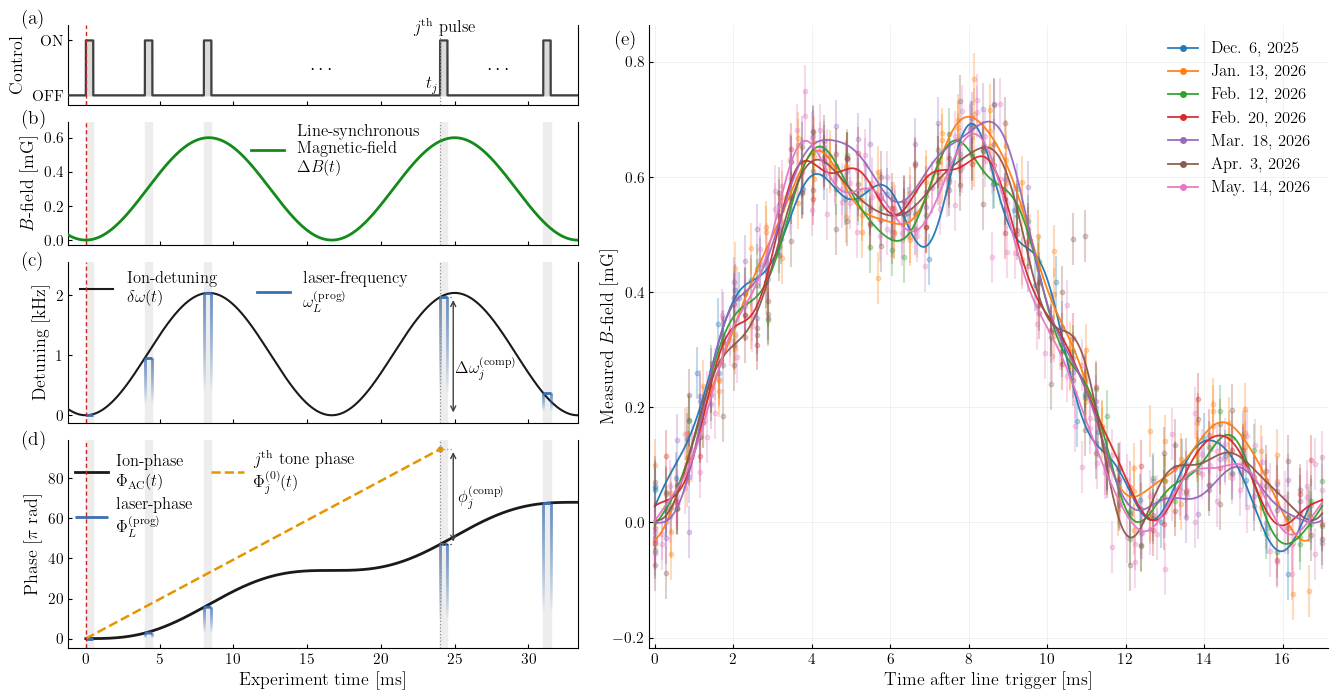

In [32]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.lines as mlines
from scipy.integrate import cumulative_trapezoid
from matplotlib import rcParams
from datetime import datetime


rcParams.update({
    "font.family": "serif",
    "font.serif": ["Computer Modern Roman"],
    "text.usetex": True,
    "font.weight": "bold",
    "axes.labelweight": "bold",
    "axes.titleweight": "bold",
    "text.latex.preamble": r"\usepackage{amsmath}",
    "font.size": 9,
    "axes.linewidth": 0.8,
    "xtick.direction": "in",
    "ytick.direction": "in",
    "xtick.major.size": 3,
    "ytick.major.size": 3,
    "xtick.major.width": 0.8,
    "ytick.major.width": 0.8,
    "savefig.dpi": 300,
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
})

# rcParams.update({
#     "font.family": "serif",
#     "font.serif": ["Computer Modern Roman"],
#     "text.usetex": True,
#     "text.latex.preamble": r"\usepackage{amsmath}",
#     "font.size": 9,
#     "axes.linewidth": 0.8,
#     "xtick.direction": "in",
#     "ytick.direction": "in",
#     "xtick.major.size": 3,
#     "ytick.major.size": 3,
#     "xtick.major.width": 0.8,
#     "ytick.major.width": 0.8,
#     "savefig.dpi": 300,
#     "pdf.fonttype": 42,
#     "ps.fonttype": 42,
# })


# =========================================================
# TOGGLES / USER SETTINGS
# =========================================================
SHOW_ANNOTATIONS = False
USE_TOY_BFIELD = True
SHOW_LINE_TRIGGER = False

SHOW_LASER_ONLY_DURING_PULSES = True

# Gradient edge styling
SHOW_LASER_EDGE_GRADIENT = True
EDGE_GRADIENT_STEPS = 1000
EDGE_ALPHA_MIN = 0.0
EDGE_ALPHA_MAX = 1.0
EDGE_GRADIENT_GAMMA = 1.0
LASER_LW = 2.0
font_size_col_plots = 13
legend_font_size = 12
annotation_font_size = 12
tick_label_font_size = 11
EDGE_FRACTION_TO_ZERO = 0.80
pre_trigger_duration = 1.2e-3   # [s]
trigger_width = 0.35e-3         # [s]

# =========================================================
# GLOBAL PARAMETERS
# =========================================================
fs = 200000
duration = 33330e-6
gamma = 3.4e3   # Hz / mG

# =========================================================
# USER-CONTROLLED PULSE LAYOUT
# =========================================================
pulse_times_ms = [
    0.00,   # reference pulse
    4.00,
    8.00,
    24.00,  # jth pulse
    31.00,  # nth pulse
]

pulse_width_ms = 0.50

j_pulse_index = 3

ref_pulse_index = 0
n_pulse_index = len(pulse_times_ms) - 1

dot_positions_ms = [16.0, 28.0]
dots_y = 0.52

custom_pulse_labels = {
    # ref_pulse_index: "reference \n pulse",
    ref_pulse_index: "",
    j_pulse_index: r"$j^{\mathrm{th}}$ pulse",
    n_pulse_index: "",
}

# first pulse is the reference; compensation updates start from next pulse
first_update_index = 1

# =========================================================
# CONVERT TO SI UNITS + VALIDATE
# =========================================================
pulse_times = 1e-3 * np.array(pulse_times_ms, dtype=float)

if np.isscalar(pulse_width_ms):
    pulse_widths = np.full(len(pulse_times), 1e-3 * float(pulse_width_ms), dtype=float)
else:
    pulse_widths = 1e-3 * np.array(pulse_width_ms, dtype=float)
    if len(pulse_widths) != len(pulse_times):
        raise ValueError("pulse_width_ms must be a scalar or a list with one entry per pulse.")

pulse_ends = pulse_times + pulse_widths

if len(pulse_times) < 3:
    raise ValueError("Use at least 3 pulses so the schematic can show reference, jth, and nth pulse.")

if np.any(np.diff(pulse_times) < 0):
    raise ValueError("pulse_times_ms must be sorted in increasing order.")

if np.any(pulse_ends > duration):
    raise ValueError("A pulse ends after the total sequence duration.")

if not (0 <= ref_pulse_index < len(pulse_times)):
    raise ValueError("ref_pulse_index is out of range.")

if not (0 <= j_pulse_index < len(pulse_times)):
    raise ValueError("j_pulse_index is out of range.")

if not (0 <= n_pulse_index < len(pulse_times)):
    raise ValueError("n_pulse_index is out of range.")

if ref_pulse_index == j_pulse_index or j_pulse_index == n_pulse_index or ref_pulse_index == n_pulse_index:
    raise ValueError("reference, jth, and nth pulses must be different.")

if not (ref_pulse_index < j_pulse_index < n_pulse_index):
    raise ValueError("Require ref_pulse_index < j_pulse_index < n_pulse_index.")

# =========================================================
# HELPERS
# =========================================================
def padded_limits(y, low_pad=0.08, high_pad=0.08):
    y = np.asarray(y)
    ymin = np.nanmin(y)
    ymax = np.nanmax(y)
    span = ymax - ymin
    if np.isclose(span, 0):
        span = max(abs(ymax), 1.0)
    return ymin - low_pad * span, ymax + high_pad * span


label_box = dict(boxstyle="round,pad=0.20", fc="white", ec="none", alpha=0.92)

def format_date_label(date_string):
    """
    Convert '20251206' to 'Dec. 6, 2025'.
    """
    dt = datetime.strptime(str(date_string), "%Y%m%d")
    month = dt.strftime("%b.")
    return f"{month} {dt.day}, {dt.year}"

def draw_vertical_alpha_gradient(
    ax,
    x,
    y_transparent,
    y_dark,
    color,
    lw=2.0,
    steps=48,
    alpha_min=0.0,
    alpha_max=1.0,
    gamma=1.0,
    zorder=4,
):
    """
    Draw one vertical edge with alpha gradient.
    The edge is almost transparent near y_transparent and dark near y_dark.
    """
    ys = np.linspace(y_transparent, y_dark, steps + 1)

    for k in range(steps):
        progress = (k + 1) / steps
        alpha = alpha_min + (alpha_max - alpha_min) * progress**gamma

        ax.plot(
            [x, x],
            [ys[k], ys[k + 1]],
            color=color,
            lw=lw,
            alpha=alpha,
            solid_capstyle="butt",
            zorder=zorder,
        )


def draw_laser_segment_with_vertical_gradient(
    ax,
    x0,
    x1,
    y_on_start,
    y_on_end,
    y_off_start,
    y_off_end,
    color,
    label=None,
    lw=2.0,
    steps=48,
    alpha_min=0.0,
    alpha_max=1.0,
    gamma=1.0,
    zorder=4,
):
    """
    Draw a laser-on segment.

    - left edge fades from off -> on
    - middle is dark blue while the laser is on
    - right edge fades from on -> off
    """
    if SHOW_LASER_EDGE_GRADIENT:
        draw_vertical_alpha_gradient(
            ax,
            x0,
            y_off_start,
            y_on_start,
            color,
            lw=lw,
            steps=steps,
            alpha_min=alpha_min,
            alpha_max=alpha_max,
            gamma=gamma,
            zorder=zorder,
        )

    ax.plot(
        [x0, x1],
        [y_on_start, y_on_end],
        color=color,
        lw=lw,
        alpha=alpha_max,
        solid_capstyle="butt",
        label=label,
        zorder=zorder + 1,
    )

    if SHOW_LASER_EDGE_GRADIENT:
        draw_vertical_alpha_gradient(
            ax,
            x1,
            y_off_end,
            y_on_end,
            color,
            lw=lw,
            steps=steps,
            alpha_min=alpha_min,
            alpha_max=alpha_max,
            gamma=gamma,
            zorder=zorder,
        )


def plot_line_signal_reproducibility_panel(ax, line_signal_results):
    """
    Plot reproducibility of the measured line-synchronous magnetic field.
    Requires line_signal_results from the separate reproducibility analysis cell.
    """
    if line_signal_results is None or len(line_signal_results) == 0:
        raise ValueError("line_signal_results is empty. Run the reproducibility analysis cell first.")

    colors = plt.get_cmap("tab10").colors
    handles = []

    for i, result in enumerate(line_signal_results):
        color = colors[i % len(colors)]
        # date = result["date"]
        date = format_date_label(result["date"])

        ax.plot(
            result["t_fit_us"] / 1000.0,
            result["B_fit_mG"],
            color=color,
            linewidth=1.3,
            alpha=0.95,
            zorder=3,
        )

        ax.errorbar(
            result["t_us"] / 1000.0,
            result["B_mG"],
            yerr=0.045,
            fmt="o",
            markersize=3.2,
            capsize=0,
            color=color,
            alpha=0.28,
            linestyle="none",
            zorder=2,
        )

        # ax.plot(
        #     result["t_fit_us"] / 1000.0,
        #     result["B_fit_mG"],
        #     color=color,
        #     linewidth=1.3,
        #     alpha=0.55,
        #     zorder=3,
        # )

        handles.append(
            mlines.Line2D(
                [],
                [],
                color=color,
                marker="o",
                linestyle="-",
                markersize=4.0,
                linewidth=1.3,
                label=date,
                alpha=0.95,
            )
        )

    # ax.set_title("Line-signal reproducibility", fontsize=10, pad=4)
    ax.set_xlabel("Time after line trigger [ms]", fontsize=font_size_col_plots)
    # ax.tick_params(axis="x", labelsize=tick_label_font_size)
    ax.set_ylabel(r"Measured $B$-field [mG]", fontsize=font_size_col_plots, labelpad=-4)
    # ax.tick_params(axis="y", labelsize=tick_label_font_size)
    ax.set_xlim(-0.15, 17.15)
    ax.grid(True, linewidth=0.45, alpha=0.25)

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    ax.legend(
        handles=handles,
        loc="upper right",
        frameon=False,
        fontsize=legend_font_size,
        handlelength=1.8,
        borderpad=0.5,
    )

    ax.tick_params(axis="both", labelsize=tick_label_font_size)


# =========================================================
# TIME AXES
# =========================================================
t_full = np.linspace(
    -pre_trigger_duration,
    duration,
    int(fs * (duration + pre_trigger_duration)),
    endpoint=False
)
t_full_ms = 1e3 * t_full

t = np.linspace(0, duration, int(fs * duration), endpoint=False)
t_ms = 1e3 * t

# =========================================================
# FIELD / DETUNING
# =========================================================
if USE_TOY_BFIELD:
    B_t_full = -0.3 * np.cos(2 * np.pi * 60 * t_full) + 0.3
else:
    B_t_full = B_rel_line_mG(t_full)

# Reference to line trigger at t=0
B_t_full = B_t_full - np.interp(0.0, t_full, B_t_full)

delta_ion_full = gamma * B_t_full/1000   # [kHz]

B_t = np.interp(t, t_full, B_t_full)
delta_ion = gamma * B_t/1000   # [kHz]
phi_ion = 2 * np.pi * cumulative_trapezoid(1000*delta_ion, t, initial=0)   # [rad]

delta_pulses = np.interp(pulse_times, t, delta_ion)
phi_pulses = np.interp(pulse_times, t, phi_ion)

# =========================================================
# CONTINUOUS CONCEPTUAL LASER DETUNING
# =========================================================
laser_detuning_full = np.zeros_like(t_full)

for j in range(first_update_index, len(pulse_times)):
    t0 = pulse_times[j]
    t1 = pulse_times[j + 1] if j + 1 < len(pulse_times) else duration
    if j + 1 < len(pulse_times):
        mask = (t_full >= t0) & (t_full < t1)
    else:
        mask = (t_full >= t0) & (t_full <= t1)
    laser_detuning_full[mask] = delta_pulses[j]

# =========================================================
# CONTINUOUS CONCEPTUAL PROGRAMMED PHASE
# =========================================================
phase_t_plot = [0.0]
phase_laser_plot = [0.0]

current_t = 0.0
current_phi = 0.0
current_detuning = 0.0

update_times = pulse_times[first_update_index:]

for k, t_update in enumerate(update_times):
    phi_before = current_phi + 2 * np.pi * current_detuning * (t_update - current_t)

    phase_t_plot.extend([t_update])
    phase_laser_plot.extend([phi_before])

    pulse_idx = first_update_index + k
    phi_snap = phi_pulses[pulse_idx]

    phase_t_plot.extend([t_update])
    phase_laser_plot.extend([phi_snap])

    current_t = t_update
    current_phi = phi_snap
    current_detuning = delta_pulses[pulse_idx]

phi_end = current_phi + 2 * np.pi * current_detuning * (duration - current_t)
phase_t_plot.extend([duration])
phase_laser_plot.extend([phi_end])

phase_t_plot = 1e3 * np.array(phase_t_plot)   # [ms]
phase_laser_plot = np.array(phase_laser_plot) # [rad]

# =========================================================
# PULSE-ONLY LASER PHASE SEGMENTS
# =========================================================
pulse_phase_segments = []

for j, (t0, t1) in enumerate(zip(pulse_times, pulse_ends)):
    if j < first_update_index:
        delta_seg = 0.0
        phi_start_seg = 0.0
    else:
        delta_seg = delta_pulses[j]
        phi_start_seg = phi_pulses[j]

    nseg = max(40, int(fs * (t1 - t0)))
    t_seg = np.linspace(t0, t1, nseg, endpoint=True)
    phi_seg = phi_start_seg + 2 * np.pi * delta_seg * (t_seg - t0)

    pulse_phase_segments.append((j, 1e3 * t_seg, phi_seg / np.pi))

# =========================================================
# JTH-TONE LINEAR PHASE IN THE omega_0 FRAME
# =========================================================
t_j = pulse_times[j_pulse_index]
t_j_ms = 1e3 * t_j
delta_j = delta_pulses[j_pulse_index]

mask_j = t <= t_j
t_for_j_phase = t[mask_j]
phi_j_linear = 2 * np.pi * 1000 * delta_j * t_for_j_phase   # [rad]

phi_ls_tj = np.interp(t_j, t, phi_ion)               # [rad]
phi_j_tone_tj = 2 * np.pi * 1000 * delta_j * t_j            # [rad]

# =========================================================
# CONTROL PANEL SIGNALS
# =========================================================
laser_on_full = np.zeros_like(t_full)
for t0, t1 in zip(pulse_times, pulse_ends):
    laser_on_full[(t_full >= t0) & (t_full < t1)] = 1

trigger_on_full = np.zeros_like(t_full)
trigger_on_full[(t_full >= -trigger_width) & (t_full < 0)] = 1

# =========================================================
# COLORS
# =========================================================
c_B = "#138A1A"
c_ion = "0.10"
c_laser = "#3B6FB6"
c_jphase = "#E69500"
c_trigger = "#C62828"
c_trigger_fill = "#F3C7C7"
c_tj = "0.55"

# =========================================================
# PLOT LAYOUT
# =========================================================
fig = plt.figure(figsize=(14, 7))

gs = fig.add_gridspec(
    4, 2,
    width_ratios=[0.75, 1.0],
    height_ratios=[0.75, 1.15, 1.50, 1.95],
    hspace=0.12,
    wspace=0.12,
)

axs = []
axs.append(fig.add_subplot(gs[0, 0]))
axs.append(fig.add_subplot(gs[1, 0], sharex=axs[0]))
axs.append(fig.add_subplot(gs[2, 0], sharex=axs[0]))
axs.append(fig.add_subplot(gs[3, 0], sharex=axs[0]))

ax_repro = fig.add_subplot(gs[:, 1])

# ---------------------------------------------------------
# Panel 1: control sequence
# ---------------------------------------------------------
ax = axs[0]

ax.step(t_full_ms, laser_on_full, where="post", color="0.25", lw=1.6, zorder=3)
ax.fill_between(t_full_ms, 0, laser_on_full, step="post", color="0.86", zorder=2)

if SHOW_LINE_TRIGGER:
    ax.step(t_full_ms, trigger_on_full, where="post", color=c_trigger, lw=1.5, zorder=4)
    ax.fill_between(t_full_ms, 0, trigger_on_full, step="post", color=c_trigger_fill, zorder=1)

ax.set_ylim(-0.18, 1.28)
ax.set_yticks([0, 1])
ax.set_yticklabels([r"OFF", r"ON"], fontsize=tick_label_font_size)
ax.set_ylabel(r"Control", fontsize=font_size_col_plots)

for idx, txt in custom_pulse_labels.items():
    if idx == 0:
        x_center = 1e3 * (pulse_times[idx] + 3.5 * pulse_widths[idx])
        ax.text(x_center, 0.85, txt, ha="center", va="bottom", fontsize=annotation_font_size)
    else:
        x_center = 1e3 * (pulse_times[idx] + 0.5 * pulse_widths[idx])
        ax.text(x_center, 1.08, txt, ha="center", va="bottom", fontsize=annotation_font_size)

ax.text(1e3 * pulse_times[j_pulse_index] - 0.6, 0.3, r"$t_j$", ha="center", va="top", fontsize=annotation_font_size)

for xdot in dot_positions_ms:
    ax.text(xdot, dots_y, r"$\cdots$", ha="center", va="center", fontsize=14)

# ---------------------------------------------------------
# Panel 2: B field
# ---------------------------------------------------------
ax = axs[1]

ax.plot(
    t_full_ms,
    B_t_full,
    color=c_B,
    lw=2.0,
    label="Line-synchronous \n Magnetic-field" + "\n" + r"$\Delta B(t)$",
    zorder=3,
)

ax.set_ylabel(r"$B$-field [mG]", fontsize = font_size_col_plots)
ax.set_ylim(*padded_limits(B_t_full, low_pad=0.05, high_pad=0.15))
ax.tick_params(axis="y", labelsize=tick_label_font_size)
ax.legend(loc="upper center", bbox_to_anchor=(0.525, 1.1),frameon=False, fontsize=legend_font_size, handlelength=2.0)

# ---------------------------------------------------------
# Panel 3: detuning
# ---------------------------------------------------------
ax = axs[2]

ax.plot(
    t_full_ms,
    delta_ion_full,
    color=c_ion,
    lw=1.5,
    label="Ion-detuning" + "\n" + r"$\delta\omega(t)$",
    zorder=3,
)

if SHOW_LASER_ONLY_DURING_PULSES:
    label_used = False

    for j, (t0, t1) in enumerate(zip(pulse_times, pulse_ends)):
        if j < first_update_index:
            delta_seg = 0.0
        else:
            delta_seg = delta_pulses[j]

        x0 = 1e3 * t0
        x1 = 1e3 * t1

        y_off = delta_seg * (1.0 - EDGE_FRACTION_TO_ZERO)

        if j == 0:
            label = r"laser-frequency" + "\n" + r"$\omega_L^{(\mathrm{prog})}$"
        else:
            label = None

        draw_laser_segment_with_vertical_gradient(
            ax,
            x0=x0,
            x1=x1,
            y_on_start=delta_seg,
            y_on_end=delta_seg,
            y_off_start=y_off,
            y_off_end=y_off,
            color=c_laser,
            label=label,
            lw=LASER_LW,
            steps=EDGE_GRADIENT_STEPS,
            alpha_min=EDGE_ALPHA_MIN,
            alpha_max=EDGE_ALPHA_MAX,
            gamma=EDGE_GRADIENT_GAMMA,
            zorder=4,
        )

        label_used = True

    ylim_data = np.r_[delta_ion_full, [0.0], delta_pulses[first_update_index:]]

else:
    ax.step(
        t_full_ms,
        laser_detuning_full,
        where="post",
        color=c_laser,
        lw=LASER_LW,
        label=r"$\Delta\omega_j^{(\mathrm{comp})}$",
        zorder=4,
    )
    ylim_data = np.r_[delta_ion_full, laser_detuning_full]

# detuning arrow at t_j
x_arrow_det = t_j_ms + 0.9

ax.plot(
    [t_j_ms, x_arrow_det],
    [delta_j, delta_j],
    linestyle=":",
    lw=0.9,
    color=c_laser,
    zorder=6,
)

ax.annotate(
    "",
    xy=(x_arrow_det, delta_j),
    xytext=(x_arrow_det, 0.0),
    arrowprops=dict(arrowstyle="<->", lw=1.0, color="0.25"),
    zorder=7,
)

ax.text(
    x_arrow_det + 0.15,
    0.5 * delta_j - 0.2,
    r"$\Delta\omega_j^{(\mathrm{comp})}$",
    ha="left",
    va="center",
    fontsize=annotation_font_size,
)

ax.set_ylabel(r"Detuning [kHz]", fontsize=font_size_col_plots)
ax.tick_params(axis="y", labelsize=tick_label_font_size)
ax.set_ylim(*padded_limits(ylim_data, low_pad=0.06, high_pad=0.25))
# ax.legend(loc="upper center", bbox_to_anchor=(0.535, 1.0), frameon=False, fontsize=legend_font_size, handlelength=2.0, ncol=2, columnspacing=1.0, handletextpad=0.5, borderaxespad=0.0)


# Split panel (c) legend into two separate legends
ion_handle = mlines.Line2D(
    [], [],
    color=c_ion,
    lw=1.5,
    label="Ion-detuning" + "\n" + r"$\delta\omega(t)$",
)

laser_handle = mlines.Line2D(
    [], [],
    color=c_laser,
    lw=LASER_LW,
    label="laser-frequency" + "\n" + r"$\omega_L^{(\mathrm{prog})}$",
)

# Ion-detuning legend: left side, close to y-axis
leg_ion = ax.legend(
    handles=[ion_handle],
    loc="upper left",
    bbox_to_anchor=(0.01, 0.98),  # smaller x moves left
    frameon=False,
    fontsize=legend_font_size,
    handlelength=2.0,
    borderaxespad=0.0,
)

ax.add_artist(leg_ion)

# Laser-frequency legend: middle/right side
ax.legend(
    handles=[laser_handle],
    loc="upper center",
    bbox_to_anchor=(0.52, 0.98),  # adjust x to move left/right
    frameon=False,
    fontsize=legend_font_size,
    handlelength=2.0,
    borderaxespad=0.0,
)

# ---------------------------------------------------------
# Panel 4: phase
# ---------------------------------------------------------
ax = axs[3]

ax.plot(
    t_ms,
    phi_ion / np.pi,
    color=c_ion,
    lw=2.0,
    label=r"Ion-phase" + "\n" + r"$\Phi_{\mathrm{AC}}(t)$",
    zorder=3,
)

if SHOW_LASER_ONLY_DURING_PULSES:
    label_used = False

    for j, xseg, yseg in pulse_phase_segments:
        x0 = xseg[0]
        x1 = xseg[-1]

        y_on_start = yseg[0]
        y_on_end = yseg[-1]

        y_off_start = y_on_start * (1.0 - EDGE_FRACTION_TO_ZERO)
        y_off_end = y_on_end * (1.0 - EDGE_FRACTION_TO_ZERO)

        label = r"laser-phase" + "\n" + r"$\Phi_L^{(\mathrm{prog})}$" if not label_used else None

        draw_laser_segment_with_vertical_gradient(
            ax,
            x0=x0,
            x1=x1,
            y_on_start=y_on_start,
            y_on_end=y_on_end,
            y_off_start=y_off_start,
            y_off_end=y_off_end,
            color=c_laser,
            label=label,
            lw=LASER_LW,
            steps=EDGE_GRADIENT_STEPS,
            alpha_min=EDGE_ALPHA_MIN,
            alpha_max=EDGE_ALPHA_MAX,
            gamma=EDGE_GRADIENT_GAMMA,
            zorder=4,
        )

        label_used = True

else:
    ax.plot(
        phase_t_plot,
        phase_laser_plot / np.pi,
        color=c_laser,
        lw=LASER_LW,
        label=r"$\phi_j^{(\mathrm{prog})}$",
        zorder=4,
    )

ax.plot(
    1e3 * t_for_j_phase,
    phi_j_linear / np.pi,
    color=c_jphase,
    lw=1.8,
    linestyle="--",
    label=r"$j^{\mathrm{th}}$ tone phase" + "\n" + r"$\Phi_j^{(0)}(t)$",
    zorder=5,
)

ax.plot(
    [t_j_ms],
    [phi_j_tone_tj / np.pi],
    marker="o",
    ms=3.4,
    color=c_jphase,
    zorder=6,
)

# phase-compensation arrow
x_arrow = t_j_ms + 0.9

ax.plot(
    [t_j_ms, x_arrow],
    [phi_ls_tj / np.pi, phi_ls_tj / np.pi],
    linestyle=":",
    lw=0.9,
    color=c_ion,
    zorder=6,
)

ax.plot(
    [t_j_ms, x_arrow],
    [phi_j_tone_tj / np.pi, phi_j_tone_tj / np.pi],
    linestyle=":",
    lw=0.9,
    color=c_jphase,
    zorder=6,
)

ax.annotate(
    "",
    xy=(x_arrow, phi_ls_tj / np.pi),
    xytext=(x_arrow, phi_j_tone_tj / np.pi),
    arrowprops=dict(arrowstyle="<->", lw=1.0, color="0.25"),
    zorder=7,
)

ax.text(
    x_arrow + 0.35,
    0.5 * (phi_ls_tj + phi_j_tone_tj) / np.pi,
    r"$\phi_j^{(\mathrm{comp})}$",
    ha="left",
    va="center",
    fontsize=annotation_font_size,
)

ax.set_ylabel(r"Phase [$\pi$ rad]", fontsize=font_size_col_plots)
ax.tick_params(axis="y", labelsize=tick_label_font_size)
ax.set_xlabel(r"Experiment time [ms]", fontsize=font_size_col_plots)
ax.tick_params(axis="x", labelsize=tick_label_font_size)
# ax.legend(loc="upper left", bbox_to_anchor=(0.00, 0.98), frameon=False, fontsize=legend_font_size, handlelength=2.8)
ax.legend(
    loc="upper left",
    bbox_to_anchor=(0.00, 0.98),
    frameon=False,
    fontsize=legend_font_size,
    handlelength=2.0,
    ncol=2,
    columnspacing=1.0,
    handletextpad=0.5,
    borderaxespad=0.0,
)

# ---------------------------------------------------------
# Panel 5: line-signal reproducibility
# ---------------------------------------------------------
plot_line_signal_reproducibility_panel(ax_repro, line_signal_results)

# =========================================================
# SHARED STYLING FOR LEFT PANELS
# =========================================================
for i, ax in enumerate(axs):
    if i > 0:
        for t0, t1 in zip(pulse_times, pulse_ends):
            ax.axvspan(1e3 * t0, 1e3 * t1, color="0.93", zorder=0)

    ax.axvline(0.0, color=c_trigger, lw=1.0, linestyle=(0, (3, 2)), zorder=6)
    ax.axvline(t_j_ms, color=c_tj, lw=0.9, linestyle=":", zorder=6)

    ax.spines["top"].set_visible(False)

    ax.text(
        -0.09,
        0.95,
        f"({chr(ord('a') + i)})",
        transform=ax.transAxes,
        fontsize=14,
        fontweight="bold",
        va="bottom",
    )

for ax in axs:
    ax.set_xlim(t_full_ms[0], t_full_ms[-1])

# Panel label for reproducibility plot
ax_repro.text(
    -0.05,
    0.96,
    "(e)",
    transform=ax_repro.transAxes,
    fontsize=14,
    fontweight="bold",
    va="bottom",
)

# Hide x-axis tick labels on upper left-column panels
for ax in axs[:-1]:
    ax.tick_params(axis="x", labelbottom=False)
    ax.set_xlabel("")
axs[-1].set_xlabel(r"Experiment time [ms]", fontsize=font_size_col_plots)
# =========================================================
# OPTIONAL ANNOTATIONS
# =========================================================
if SHOW_ANNOTATIONS:
    axs[3].annotate(
        r"$t_j\,\delta\omega(t_j)$ in the $\omega_0$ frame",
        xy=(t_j_ms, phi_j_tone_tj / np.pi),
        xytext=(t_j_ms - 8.0, phi_j_tone_tj / np.pi - 8),
        arrowprops=dict(arrowstyle="->", lw=0.8, color=c_jphase),
        fontsize=10,
        bbox=label_box,
    )

# =========================================================
# SAVE
# =========================================================
plt.subplots_adjust(left=0.08, right=0.98, top=0.98, bottom=0.09)

plt.savefig("Line_signal_Compensation_Figure1_with_reproducibility.pdf", bbox_inches="tight", pad_inches=0.0, dpi=300)
# plt.savefig("Line_signal_Compensation_Figure1_with_reproducibility.svg", bbox_inches="tight")
# plt.savefig("Line_signal_Compensation_Figure1_with_reproducibility.png", dpi=900, bbox_inches="tight")

plt.show()

20251206: fit 41 points using sensitivity -3.49923 MHz/G from Z:\Lab Data\D52_Calibration_Ba137\RFSoC_LineSignal_sweep_SelfRef
  B0 = 0.319602 +/- 0.007040 mG
  Stored harmonic_results with 10 harmonics
  Saved fit parameters to line_signal_fit_params_20251206_K10.txt
20260113: fit 123 points using sensitivity -3.49923 MHz/G from Z:\Lab Data\D52_Calibration_Ba137\RFSoC_LineSignal_sweep_SelfRef\20260113_good
  B0 = 0.340268 +/- 0.004472 mG
  Stored harmonic_results with 10 harmonics
  Saved fit parameters to line_signal_fit_params_20260113_K10.txt
20260212: fit 68 points using sensitivity -3.42017 MHz/G from Z:\Lab Data\D52_Calibration_Ba137\RFSoC_LineSignal_sweep_SelfRef\20260113_good
  B0 = 0.320629 +/- 0.004932 mG
  Stored harmonic_results with 10 harmonics
  Saved fit parameters to line_signal_fit_params_20260212_K10.txt
20260220: fit 64 points using sensitivity -3.42017 MHz/G from Z:\Lab Data\D52_Calibration_Ba137\RFSoC_LineSignal_sweep_SelfRef\20260113_good
  B0 = 0.325535 +/- 0.0

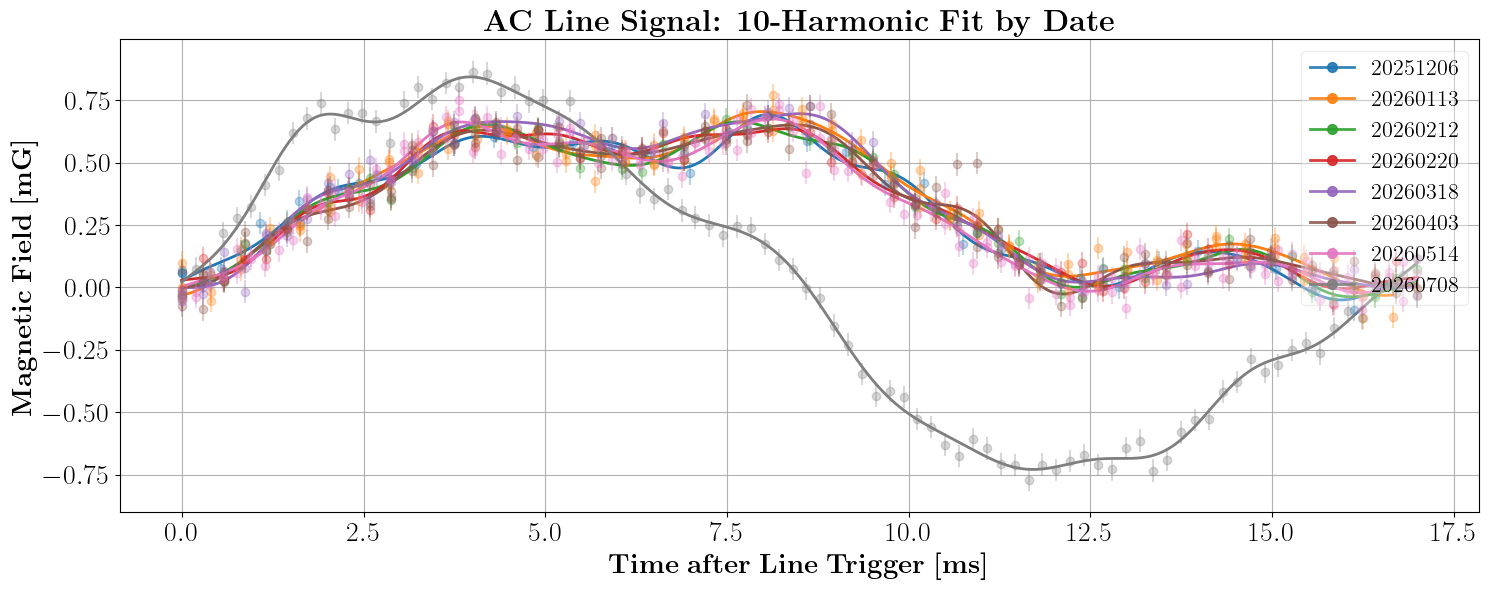


Harmonic results for 20251206
    f [Hz]         A [mG]     A_err [mG]         phi/pi     phi_err/pi
      60.0   3.118375e-01   1.039927e-02      -0.742979       0.009697
     120.0   1.068720e-02   9.903533e-03      -0.451948       0.298625
     180.0   8.837400e-02   9.861714e-03       0.857657       0.036254
     240.0   2.951168e-02   1.010105e-02      -0.585920       0.105781
     300.0   2.965678e-02   9.923401e-03      -0.751529       0.107019
     360.0   1.345269e-02   9.797588e-03      -0.061457       0.238903
     420.0   7.215201e-03   1.001544e-02      -0.660545       0.436269
     480.0   2.654160e-02   9.898065e-03       0.297779       0.119588
     540.0   1.990375e-02   9.966712e-03      -0.511383       0.156138
     600.0   5.696483e-03   9.702443e-03      -0.012733       0.545265

Harmonic results for 20260113
    f [Hz]         A [mG]     A_err [mG]         phi/pi     phi_err/pi
      60.0   3.120971e-01   6.354764e-03      -0.766668       0.006419
     120.0   4.

In [4]:
import ast
import os
import re
from pathlib import Path

import matplotlib.lines as mlines
import matplotlib.pyplot as plt
import numpy as np
from matplotlib import rcParams
from scipy.optimize import curve_fit


# =========================================================
# PLOT STYLE
# =========================================================
rcParams["font.family"] = "serif"
rcParams["font.serif"] = ["Computer Modern"]
rcParams["text.usetex"] = True

rcParams["axes.titlesize"] = 22
rcParams["axes.labelsize"] = 20
rcParams["xtick.labelsize"] = 20
rcParams["ytick.labelsize"] = 20
rcParams["legend.fontsize"] = 16
rcParams["figure.titlesize"] = 22


# =========================================================
# CONFIGURATION
# =========================================================
dates = [
    "20251206",
    "20260113",
    "20260212",
    "20260220",
    "20260318",
    "20260403",
    "20260514",
    "20260708"
]

# Magnetic-field sensitivity for the sensitive transition, one value per date.
# Units: MHz/G
sens_list_f1 = [
    -3.49923,
    -3.49923,
    -3.42017,
    -3.42017,
    -3.42017,
    -3.42017,
    -3.42017,
    -3.42017
]

erase_offset_list = [False, True, False, False, False, False, False, False]

# Ten harmonics of 60 Hz
fit_freqs = [60, 120, 180, 240, 300, 360, 420, 480, 540, 600]

B_YERR_MG = 0.045

base_data_dir = Path(
    r"Z:\Lab Data\D52_Calibration_Ba137\RFSoC_LineSignal_sweep_SelfRef"
)

extra_data_dirs = [
    Path.cwd(),
    Path.cwd() / "line_signal_measurements",
    Path(
        r"Z:\Lab Data\D52_Calibration_Ba137\RFSoC_LineSignal_sweep_SelfRef\20260113_good"
    ),
]


# =========================================================
# MODEL
# =========================================================
def line_signal_model(t_us, *params):
    """
    10-harmonic line-signal model.

    Parameters:
        params[0] = B0
        params[1 + 2*i] = A_i
        params[1 + 2*i + 1] = phi_i

    t_us is in microseconds.
    Output is in mG.
    """
    t_s = np.asarray(t_us, dtype=float) * 1e-6
    y = np.full_like(t_s, params[0], dtype=float)

    for i, f_hz in enumerate(fit_freqs):
        A = params[1 + 2 * i]
        phi = params[1 + 2 * i + 1]
        y = y + A * np.cos(2 * np.pi * f_hz * t_s + phi)

    return y


# =========================================================
# FILE HELPERS
# =========================================================
def candidate_data_dirs(date):
    """
    Prefer date-specific folders when present, then fall back to root folder.
    """
    candidates = [
        base_data_dir / date,
        base_data_dir / f"{date}_good",
        *extra_data_dirs,
        base_data_dir,
    ]

    try:
        for child in base_data_dir.iterdir():
            if child.is_dir() and date in child.name and child not in candidates:
                candidates.insert(-1, child)
    except OSError:
        pass

    seen = set()
    unique_candidates = []

    for candidate in candidates:
        candidate_key = str(candidate).lower()
        if candidate_key not in seen:
            unique_candidates.append(candidate)
            seen.add(candidate_key)

    return unique_candidates


def extract_harmonic_results(params, covariance):
    """
    Convert fitted params/covariance into harmonic_results list.

    Returns:
        harmonic_results = [
            (f_hz, A, A_err, phi, phi_err),
            ...
        ]
    """
    params = np.asarray(params, dtype=float)

    if covariance is not None and np.all(np.isfinite(covariance)):
        param_errors = np.sqrt(np.maximum(np.diag(covariance), 0.0))
    else:
        param_errors = np.full_like(params, np.nan, dtype=float)

    harmonic_results = []

    for i, f_hz in enumerate(fit_freqs):
        A_index = 1 + 2 * i
        phi_index = 1 + 2 * i + 1

        A = params[A_index]
        phi = params[phi_index]

        A_err = param_errors[A_index]
        phi_err = param_errors[phi_index]

        # Optional: keep phase in a readable range.
        # Comment this out if you want the raw fitted phase.
        phi = np.angle(np.exp(1j * phi))

        harmonic_results.append((f_hz, A, A_err, phi, phi_err))

    B0_fit = params[0]
    B0_err = param_errors[0]

    return B0_fit, B0_err, harmonic_results


def save_fit_parameters(filename, B0_fit, B0_err, harmonic_results):
    """
    Save fit parameters in a text file.
    """
    with open(filename, "w") as file:
        file.write("# B0 B0_err (mG)\n")
        file.write("{:.18e} {:.18e}\n".format(B0_fit, B0_err))
        file.write("# f_Hz A A_err phi phi_err\n")

        for f_hz, A, A_err, phi, phi_err in harmonic_results:
            file.write(
                "{:10.3f} {:.18e} {:.18e} {:.18e} {:.18e}\n".format(
                    f_hz,
                    A,
                    A_err,
                    phi,
                    phi_err,
                )
            )


# =========================================================
# MAIN ANALYSIS FUNCTION
# =========================================================
def read_files_and_analyze(date, sensitivity, erase_offset=True):
    file_pattern = re.compile(
        rf"ramsey_reference_transitions_LTWait(\d+(?:\.\d+)?)us_"
        rf"Shots250_RamseyWait50us_{date}_.*"
    )

    rows = []
    matched_dirs = []
    seen_files = set()

    for data_dir in candidate_data_dirs(date):
        if not data_dir.exists():
            continue

        try:
            filenames = os.listdir(data_dir)
        except OSError as exc:
            print(f"Skipping {data_dir}: {exc}")
            continue

        for filename in filenames:
            if not file_pattern.match(filename):
                continue

            file_path = data_dir / filename
            file_key = str(file_path).lower()

            if file_key in seen_files:
                continue

            seen_files.add(file_key)

            try:
                with open(file_path, "r") as file:
                    lines = file.readlines()

                lt_wait_us = float(lines[0].strip())
                freqs = ast.literal_eval(lines[1].strip())
                freqs_ref = ast.literal_eval(lines[3].strip())

                rows.append((lt_wait_us, freqs, freqs_ref))

                if data_dir not in matched_dirs:
                    matched_dirs.append(data_dir)

            except Exception as exc:
                print(f"Error reading {file_path}: {exc}")

    if not rows:
        print(f"No matching files found for {date}.")
        return None

    rows.sort(key=lambda row: row[0])

    times_us = np.array([row[0] for row in rows], dtype=float)
    freqs = np.array([row[1] for row in rows], dtype=float)
    freqs_ref = np.array([row[2] for row in rows], dtype=float)

    freq_diffs = np.diff(freqs)
    freq_ref_diff = np.diff(freqs_ref)
    detuning_delta = freq_ref_diff - freq_diffs

    if erase_offset:
        detuning_delta = detuning_delta - np.median(detuning_delta[0:3])

    y_noisy_pm = np.array(detuning_delta / sensitivity, dtype=float).flatten()

    if y_noisy_pm.size != times_us.size:
        raise ValueError(
            f"{date}: got {times_us.size} time values but {y_noisy_pm.size} field values. "
            "Check transition selection before flattening."
        )

    B_mG = y_noisy_pm * 1000.0

    # Initial guesses
    B0_0 = np.mean(B_mG)
    A_guess = 0.5 * (np.max(B_mG) - np.min(B_mG))

    if not np.isfinite(A_guess) or A_guess <= 0:
        A_guess = 0.01

    p0 = [B0_0]
    for i, _ in enumerate(fit_freqs):
        p0.extend([A_guess if i == 0 else 0.3 * A_guess, 0.0])

    # Bounds:
    #   B0 free
    #   A_n >= 0
    #   phi_n free
    lower_bounds = [-np.inf]
    upper_bounds = [np.inf]

    for _ in fit_freqs:
        lower_bounds.extend([0.0, -np.inf])
        upper_bounds.extend([np.inf, np.inf])

    params, covariance = curve_fit(
        line_signal_model,
        times_us,
        B_mG,
        p0=p0,
        bounds=(lower_bounds, upper_bounds),
        maxfev=50000,
    )

    t_fit_us = np.linspace(times_us.min(), times_us.max(), 2000)
    B_fit_mG = line_signal_model(t_fit_us, *params)

    B0_fit, B0_err, harmonic_results = extract_harmonic_results(
        params,
        covariance,
    )

    selected_K = len(fit_freqs)

    return {
        "date": date,
        "sensitivity": sensitivity,
        "erase_offset": erase_offset,
        "matched_dirs": matched_dirs,
        "t_us": times_us,
        "B_mG": B_mG,
        "t_fit_us": t_fit_us,
        "B_fit_mG": B_fit_mG,
        "params": params,
        "covariance": covariance,
        "B0_fit": B0_fit,
        "B0_err": B0_err,
        "harmonic_results": harmonic_results,
        "selected_K": selected_K,
        "fit_freqs": list(fit_freqs),
    }


# =========================================================
# RUN ANALYSIS
# =========================================================
line_signal_results = []

for date, sensitivity, erase_offset in zip(
    dates,
    sens_list_f1,
    erase_offset_list,
):
    result = read_files_and_analyze(
        date,
        sensitivity,
        erase_offset=erase_offset,
    )

    if result is None:
        continue

    line_signal_results.append(result)

    fit_params_filename = f"line_signal_fit_params_{date}_K{result['selected_K']}.txt"
    save_fit_parameters(
        fit_params_filename,
        result["B0_fit"],
        result["B0_err"],
        result["harmonic_results"],
    )

    dirs = ", ".join(str(path) for path in result["matched_dirs"])

    print(
        f"{date}: fit {result['t_us'].size} points using sensitivity "
        f"{sensitivity} MHz/G from {dirs}"
    )
    print(f"  B0 = {result['B0_fit']:.6f} +/- {result['B0_err']:.6f} mG")
    print(f"  Stored harmonic_results with {len(result['harmonic_results'])} harmonics")
    print(f"  Saved fit parameters to {fit_params_filename}")

if not line_signal_results:
    raise RuntimeError(
        "No line-signal datasets were loaded. Check dates, data path, and filename pattern."
    )


# =========================================================
# PLOT FITS BY DATE
# =========================================================
plt.figure(figsize=(15, 6))

colors = plt.get_cmap("tab10").colors
handles = []

for i, result in enumerate(line_signal_results):
    color = colors[i % len(colors)]
    label = result["date"]

    plt.errorbar(
        result["t_us"] / 1000.0,
        result["B_mG"],
        yerr=B_YERR_MG,
        fmt="o",
        markersize=6,
        capsize=0,
        color=color,
        alpha=0.3,
        linestyle="none",
        label="_nolegend_",
    )

    plt.plot(
        result["t_fit_us"] / 1000.0,
        result["B_fit_mG"],
        color=color,
        linewidth=2,
    )

    handles.append(
        mlines.Line2D(
            [],
            [],
            color=color,
            marker="o",
            linestyle="-",
            markersize=7,
            linewidth=2,
            label=label,
            alpha=0.9,
        )
    )

leg = plt.legend(
    handles=handles,
    loc="upper right",
    framealpha=0.35,
    fontsize=16,
)

for txt in leg.get_texts():
    txt.set_fontweight("bold")

plt.xlabel(r"\boldmath$\mathbf{Time\ after\ Line\ Trigger\ [ms]}$")
plt.ylabel(r"\boldmath$\mathbf{Magnetic\ Field\ [mG]}$")
plt.title(r"\textbf{AC Line Signal: 10-Harmonic Fit by Date}")
plt.grid()
plt.tight_layout()
plt.savefig(
    "line_signal_10_harmonics_by_date.png",
    dpi=300,
    bbox_inches="tight",
)
plt.show()


# =========================================================
# QUICK CHECK: HARMONIC RESULTS TABLE
# =========================================================
for result in line_signal_results:
    print("\n" + "=" * 72)
    print(f"Harmonic results for {result['date']}")
    print("=" * 72)
    print(f"{'f [Hz]':>10s} {'A [mG]':>14s} {'A_err [mG]':>14s} {'phi/pi':>14s} {'phi_err/pi':>14s}")

    for f_hz, A, A_err, phi, phi_err in result["harmonic_results"]:
        print(
            f"{f_hz:10.1f} "
            f"{A:14.6e} "
            f"{A_err:14.6e} "
            f"{phi / np.pi:14.6f} "
            f"{phi_err / np.pi:14.6f}"
        )


# =========================================================
# KEEP LATEST DATASET AVAILABLE FOR DOWNSTREAM CELLS
# =========================================================
latest_result = line_signal_results[-1]

t_pm_new = latest_result["t_us"]
y_noisy_pm_new = latest_result["B_mG"] / 1000.0

print("\nLatest dataset stored as:")
print("  t_pm_new       -> time values in us")
print("  y_noisy_pm_new -> B-field values in G")
print("  line_signal_results now includes harmonic_results")

In [3]:
import numpy as np

# Frequencies to summarize
TARGET_FREQS_HZ = [60, 180, 300]


def circular_mean(phases_rad):
    """
    Circular mean of angles in radians.
    """
    phases_rad = np.asarray(phases_rad, dtype=float)
    phases_rad = phases_rad[np.isfinite(phases_rad)]

    if len(phases_rad) == 0:
        return np.nan

    z = np.mean(np.exp(1j * phases_rad))
    return np.angle(z)


def circular_std(phases_rad):
    """
    Circular standard deviation of angles in radians.

    Uses:
        sigma = sqrt(-2 ln R)
    where R is the mean resultant length.
    """
    phases_rad = np.asarray(phases_rad, dtype=float)
    phases_rad = phases_rad[np.isfinite(phases_rad)]

    if len(phases_rad) < 2:
        return np.nan

    R = np.abs(np.mean(np.exp(1j * phases_rad)))

    if R <= 0:
        return np.nan

    return np.sqrt(-2.0 * np.log(R))


def extract_harmonic_by_frequency(result, target_freq_hz, tol_hz=1e-6):
    """
    Extract (A, A_err, phi, phi_err) for one harmonic frequency from one result.
    """
    for f_hz, A, A_err, phi, phi_err in result["harmonic_results"]:
        if abs(f_hz - target_freq_hz) <= tol_hz:
            return A, A_err, phi, phi_err

    return np.nan, np.nan, np.nan, np.nan


def summarize_selected_harmonics(line_signal_results, target_freqs_hz):
    """
    Print mean and standard deviation across dates for selected harmonic
    amplitudes and phases.

    Amplitude std is ordinary sample std.
    Phase std is circular std because phases wrap at +/- pi.
    """
    print("\n" + "=" * 86)
    print("Across-date harmonic reproducibility")
    print("=" * 86)
    print(
        f"{'f [Hz]':>8s} "
        f"{'N':>4s} "
        f"{'A mean [mG]':>14s} "
        f"{'A std [mG]':>14s} "
        f"{'phi mean [rad]':>16s} "
        f"{'phi circ std [rad]':>20s} "
        f"{'phi circ std/pi':>18s}"
    )
    print("-" * 86)

    summary = {}

    for target_freq in target_freqs_hz:
        amplitudes = []
        phases = []
        dates_used = []

        for result in line_signal_results:
            A, A_err, phi, phi_err = extract_harmonic_by_frequency(
                result,
                target_freq,
            )

            if np.isfinite(A) and np.isfinite(phi):
                amplitudes.append(A)
                phases.append(phi)
                dates_used.append(result["date"])

        amplitudes = np.asarray(amplitudes, dtype=float)
        phases = np.asarray(phases, dtype=float)

        n = len(amplitudes)

        A_mean = np.nanmean(amplitudes) if n > 0 else np.nan
        A_std = np.nanstd(amplitudes, ddof=1) if n > 1 else np.nan

        phi_mean = circular_mean(phases)
        phi_std = circular_std(phases)

        summary[target_freq] = {
            "dates_used": dates_used,
            "amplitudes_mG": amplitudes,
            "phases_rad": phases,
            "A_mean_mG": A_mean,
            "A_std_mG": A_std,
            "phi_mean_rad": phi_mean,
            "phi_circular_std_rad": phi_std,
            "phi_circular_std_over_pi": phi_std / np.pi if np.isfinite(phi_std) else np.nan,
        }

        print(
            f"{target_freq:8.1f} "
            f"{n:4d} "
            f"{A_mean:14.6f} "
            f"{A_std:14.6f} "
            f"{phi_mean:16.6f} "
            f"{phi_std:20.6f} "
            f"{phi_std / np.pi:18.6f}"
        )

    print("=" * 86 + "\n")

    return summary


harmonic_reproducibility_summary = summarize_selected_harmonics(
    line_signal_results,
    TARGET_FREQS_HZ,
)


Across-date harmonic reproducibility
  f [Hz]    N    A mean [mG]     A std [mG]   phi mean [rad]   phi circ std [rad]    phi circ std/pi
--------------------------------------------------------------------------------------
    60.0    8       0.375098       0.153572        -2.255613             0.284614           0.090596
   180.0    8       0.091803       0.019118         2.615828             0.180570           0.057477
   300.0    8       0.034492       0.009043        -2.384104             0.337455           0.107415



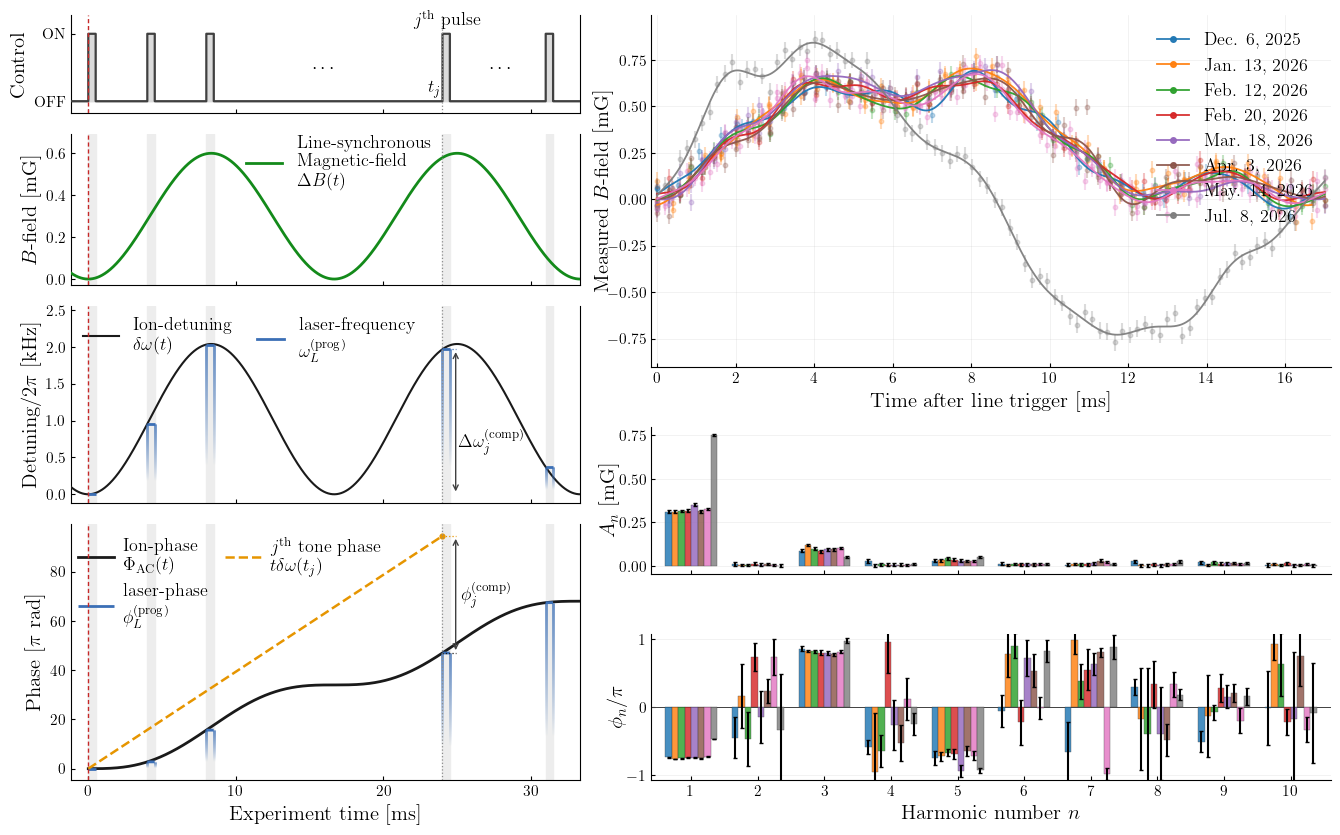

In [6]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.lines as mlines
from scipy.integrate import cumulative_trapezoid
from matplotlib import rcParams
from datetime import datetime


rcParams.update({
    "font.family": "serif",
    "font.serif": ["Computer Modern Roman"],
    "text.usetex": True,
    "font.weight": "bold",
    "axes.labelweight": "bold",
    "axes.titleweight": "bold",
    "text.latex.preamble": r"\usepackage{amsmath}",
    "font.size": 9,
    "axes.linewidth": 0.8,
    "xtick.direction": "in",
    "ytick.direction": "in",
    "xtick.major.size": 3,
    "ytick.major.size": 3,
    "xtick.major.width": 0.8,
    "ytick.major.width": 0.8,
    "savefig.dpi": 300,
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
})

# rcParams.update({
#     "font.family": "serif",
#     "font.serif": ["Computer Modern Roman"],
#     "text.usetex": True,
#     "text.latex.preamble": r"\usepackage{amsmath}",
#     "font.size": 9,
#     "axes.linewidth": 0.8,
#     "xtick.direction": "in",
#     "ytick.direction": "in",
#     "xtick.major.size": 3,
#     "ytick.major.size": 3,
#     "xtick.major.width": 0.8,
#     "ytick.major.width": 0.8,
#     "savefig.dpi": 300,
#     "pdf.fonttype": 42,
#     "ps.fonttype": 42,
# })


# =========================================================
# TOGGLES / USER SETTINGS
# =========================================================
SHOW_ANNOTATIONS = False
USE_TOY_BFIELD = True
SHOW_LINE_TRIGGER = False

SHOW_LASER_ONLY_DURING_PULSES = True

HARMONIC_PANEL_MAX_N = 10
HARMONIC_BAR_WIDTH = 0.16
# Gradient edge styling
SHOW_LASER_EDGE_GRADIENT = True
EDGE_GRADIENT_STEPS = 1000
EDGE_ALPHA_MIN = 0.0
EDGE_ALPHA_MAX = 1.0
EDGE_GRADIENT_GAMMA = 1.0
LASER_LW = 2.0
font_size_col_plots = 15
legend_font_size = 13
annotation_font_size = 13
tick_label_font_size = 11
EDGE_FRACTION_TO_ZERO = 0.80
pre_trigger_duration = 1.2e-3   # [s]
trigger_width = 0.35e-3         # [s]

# =========================================================
# GLOBAL PARAMETERS
# =========================================================
fs = 200000
duration = 33330e-6
gamma = 3.4e3   # Hz / mG

# =========================================================
# USER-CONTROLLED PULSE LAYOUT
# =========================================================
pulse_times_ms = [
    0.00,   # reference pulse
    4.00,
    8.00,
    24.00,  # jth pulse
    31.00,  # nth pulse
]

pulse_width_ms = 0.50

j_pulse_index = 3

ref_pulse_index = 0
n_pulse_index = len(pulse_times_ms) - 1

dot_positions_ms = [16.0, 28.0]
dots_y = 0.52

custom_pulse_labels = {
    # ref_pulse_index: "reference \n pulse",
    ref_pulse_index: "",
    j_pulse_index: r"$j^{\mathrm{th}}$ pulse",
    n_pulse_index: "",
}

# first pulse is the reference; compensation updates start from next pulse
first_update_index = 1

# =========================================================
# CONVERT TO SI UNITS + VALIDATE
# =========================================================
pulse_times = 1e-3 * np.array(pulse_times_ms, dtype=float)

if np.isscalar(pulse_width_ms):
    pulse_widths = np.full(len(pulse_times), 1e-3 * float(pulse_width_ms), dtype=float)
else:
    pulse_widths = 1e-3 * np.array(pulse_width_ms, dtype=float)
    if len(pulse_widths) != len(pulse_times):
        raise ValueError("pulse_width_ms must be a scalar or a list with one entry per pulse.")

pulse_ends = pulse_times + pulse_widths

if len(pulse_times) < 3:
    raise ValueError("Use at least 3 pulses so the schematic can show reference, jth, and nth pulse.")

if np.any(np.diff(pulse_times) < 0):
    raise ValueError("pulse_times_ms must be sorted in increasing order.")

if np.any(pulse_ends > duration):
    raise ValueError("A pulse ends after the total sequence duration.")

if not (0 <= ref_pulse_index < len(pulse_times)):
    raise ValueError("ref_pulse_index is out of range.")

if not (0 <= j_pulse_index < len(pulse_times)):
    raise ValueError("j_pulse_index is out of range.")

if not (0 <= n_pulse_index < len(pulse_times)):
    raise ValueError("n_pulse_index is out of range.")

if ref_pulse_index == j_pulse_index or j_pulse_index == n_pulse_index or ref_pulse_index == n_pulse_index:
    raise ValueError("reference, jth, and nth pulses must be different.")

if not (ref_pulse_index < j_pulse_index < n_pulse_index):
    raise ValueError("Require ref_pulse_index < j_pulse_index < n_pulse_index.")

# =========================================================
# HELPERS
# =========================================================
def padded_limits(y, low_pad=0.08, high_pad=0.08):
    y = np.asarray(y)
    ymin = np.nanmin(y)
    ymax = np.nanmax(y)
    span = ymax - ymin
    if np.isclose(span, 0):
        span = max(abs(ymax), 1.0)
    return ymin - low_pad * span, ymax + high_pad * span


label_box = dict(boxstyle="round,pad=0.20", fc="white", ec="none", alpha=0.92)

def format_date_label(date_string):
    """
    Convert '20251206' to 'Dec. 6, 2025'.
    """
    dt = datetime.strptime(str(date_string), "%Y%m%d")
    month = dt.strftime("%b.")
    return f"{month} {dt.day}, {dt.year}"

def _extract_harmonic_arrays(line_signal_results, max_n=10):
    """
    Extract harmonic amplitudes and phases from line_signal_results.

    Expects each result to contain:
        result["harmonic_results"] = [(f_hz, A, A_err, phi, phi_err), ...]
    """
    if line_signal_results is None or len(line_signal_results) == 0:
        raise ValueError("line_signal_results is empty.")

    harmonic_numbers = np.arange(1, max_n + 1)

    dates = []
    amplitudes = []
    amplitude_errors = []
    phases_over_pi = []
    phase_errors_over_pi = []

    for result in line_signal_results:
        if "harmonic_results" not in result:
            raise KeyError(
                "Each result must contain 'harmonic_results'. "
                "Run the line-signal fitting cell that stores harmonic_results first."
            )

        dates.append(format_date_label(result["date"]))

        amp = np.full(max_n, np.nan)
        amp_err = np.full(max_n, np.nan)
        phase = np.full(max_n, np.nan)
        phase_err = np.full(max_n, np.nan)

        for f_hz, A, A_err, phi, phi_err in result["harmonic_results"]:
            n = int(np.rint(f_hz / 60.0))
            if 1 <= n <= max_n:
                amp[n - 1] = A
                amp_err[n - 1] = A_err

                # Wrap phase to [-pi, pi] for readable plotting.
                phase_wrapped = np.angle(np.exp(1j * phi))
                phase[n - 1] = phase_wrapped / np.pi
                phase_err[n - 1] = phi_err / np.pi

        amplitudes.append(amp)
        amplitude_errors.append(amp_err)
        phases_over_pi.append(phase)
        phase_errors_over_pi.append(phase_err)

    return {
        "harmonic_numbers": harmonic_numbers,
        "dates": dates,
        "amplitudes": np.asarray(amplitudes),
        "amplitude_errors": np.asarray(amplitude_errors),
        "phases_over_pi": np.asarray(phases_over_pi),
        "phase_errors_over_pi": np.asarray(phase_errors_over_pi),
    }


def plot_harmonic_amplitude_panel(ax, line_signal_results, max_n=10):
    data = _extract_harmonic_arrays(line_signal_results, max_n=max_n)

    n_vals = data["harmonic_numbers"]
    dates = data["dates"]
    amplitudes = data["amplitudes"]
    amplitude_errors = data["amplitude_errors"]

    colors = plt.get_cmap("tab10").colors
    n_dates = len(dates)

    total_width = min(0.78, HARMONIC_BAR_WIDTH * n_dates)
    bar_width = total_width / max(n_dates, 1)
    offsets = (np.arange(n_dates) - 0.5 * (n_dates - 1)) * bar_width

    for i, date in enumerate(dates):
        yerr = amplitude_errors[i]
        yerr = np.where(np.isfinite(yerr), yerr, 0.0)

        ax.bar(
            n_vals + offsets[i],
            amplitudes[i],
            width=bar_width,
            yerr=yerr,
            capsize=1.5,
            color=colors[i % len(colors)],
            alpha=0.82,
            linewidth=0.3,
            edgecolor="0.25",
            label=date,
            zorder=3,
        )

    ax.set_ylabel(r"$A_n$ [mG]", fontsize=font_size_col_plots, labelpad=0)
    ax.set_xticks(n_vals)
    ax.set_xlim(0.4, max_n + 0.6)
    ax.grid(True, axis="y", linewidth=0.45, alpha=0.25)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.tick_params(axis="both", labelsize=tick_label_font_size)


def plot_harmonic_phase_panel(ax, line_signal_results, max_n=10):
    data = _extract_harmonic_arrays(line_signal_results, max_n=max_n)

    n_vals = data["harmonic_numbers"]
    dates = data["dates"]
    phases = data["phases_over_pi"]
    phase_errors = data["phase_errors_over_pi"]

    colors = plt.get_cmap("tab10").colors
    n_dates = len(dates)

    total_width = min(0.78, HARMONIC_BAR_WIDTH * n_dates)
    bar_width = total_width / max(n_dates, 1)
    offsets = (np.arange(n_dates) - 0.5 * (n_dates - 1)) * bar_width

    for i, date in enumerate(dates):
        yerr = phase_errors[i]
        yerr = np.where(np.isfinite(yerr), yerr, 0.0)

        ax.bar(
            n_vals + offsets[i],
            phases[i],
            width=bar_width,
            yerr=yerr,
            capsize=1.5,
            color=colors[i % len(colors)],
            alpha=0.82,
            linewidth=0.3,
            edgecolor="0.25",
            zorder=3,
        )

    ax.axhline(0.0, color="0.25", linewidth=0.7, zorder=2)
    ax.set_xlabel(r"Harmonic number $n$", fontsize=font_size_col_plots)
    ax.set_ylabel(r"$\phi_n/\pi$", fontsize=font_size_col_plots, labelpad=0)
    ax.set_xticks(n_vals)
    ax.set_xlim(0.4, max_n + 0.6)
    ax.set_ylim(-1.08, 1.08)
    ax.set_yticks([-1, 0, 1])
    ax.grid(True, axis="y", linewidth=0.45, alpha=0.25)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.tick_params(axis="both", labelsize=tick_label_font_size)

def draw_vertical_alpha_gradient(
    ax,
    x,
    y_transparent,
    y_dark,
    color,
    lw=2.0,
    steps=48,
    alpha_min=0.0,
    alpha_max=1.0,
    gamma=1.0,
    zorder=4,
):
    """
    Draw one vertical edge with alpha gradient.
    The edge is almost transparent near y_transparent and dark near y_dark.
    """
    ys = np.linspace(y_transparent, y_dark, steps + 1)

    for k in range(steps):
        progress = (k + 1) / steps
        alpha = alpha_min + (alpha_max - alpha_min) * progress**gamma

        ax.plot(
            [x, x],
            [ys[k], ys[k + 1]],
            color=color,
            lw=lw,
            alpha=alpha,
            solid_capstyle="butt",
            zorder=zorder,
        )


def draw_laser_segment_with_vertical_gradient(
    ax,
    x0,
    x1,
    y_on_start,
    y_on_end,
    y_off_start,
    y_off_end,
    color,
    label=None,
    lw=2.0,
    steps=48,
    alpha_min=0.0,
    alpha_max=1.0,
    gamma=1.0,
    zorder=4,
):
    """
    Draw a laser-on segment.

    - left edge fades from off -> on
    - middle is dark blue while the laser is on
    - right edge fades from on -> off
    """
    if SHOW_LASER_EDGE_GRADIENT:
        draw_vertical_alpha_gradient(
            ax,
            x0,
            y_off_start,
            y_on_start,
            color,
            lw=lw,
            steps=steps,
            alpha_min=alpha_min,
            alpha_max=alpha_max,
            gamma=gamma,
            zorder=zorder,
        )

    ax.plot(
        [x0, x1],
        [y_on_start, y_on_end],
        color=color,
        lw=lw,
        alpha=alpha_max,
        solid_capstyle="butt",
        label=label,
        zorder=zorder + 1,
    )

    if SHOW_LASER_EDGE_GRADIENT:
        draw_vertical_alpha_gradient(
            ax,
            x1,
            y_off_end,
            y_on_end,
            color,
            lw=lw,
            steps=steps,
            alpha_min=alpha_min,
            alpha_max=alpha_max,
            gamma=gamma,
            zorder=zorder,
        )


def plot_line_signal_reproducibility_panel(ax, line_signal_results):
    """
    Plot reproducibility of the measured line-synchronous magnetic field.
    Requires line_signal_results from the separate reproducibility analysis cell.
    """
    if line_signal_results is None or len(line_signal_results) == 0:
        raise ValueError("line_signal_results is empty. Run the reproducibility analysis cell first.")

    colors = plt.get_cmap("tab10").colors
    handles = []

    for i, result in enumerate(line_signal_results):
        color = colors[i % len(colors)]
        # date = result["date"]
        date = format_date_label(result["date"])

        ax.plot(
            result["t_fit_us"] / 1000.0,
            result["B_fit_mG"],
            color=color,
            linewidth=1.3,
            alpha=0.95,
            zorder=3,
        )

        ax.errorbar(
            result["t_us"] / 1000.0,
            result["B_mG"],
            yerr=0.045,
            fmt="o",
            markersize=3.2,
            capsize=0,
            color=color,
            alpha=0.28,
            linestyle="none",
            zorder=2,
        )

        # ax.plot(
        #     result["t_fit_us"] / 1000.0,
        #     result["B_fit_mG"],
        #     color=color,
        #     linewidth=1.3,
        #     alpha=0.55,
        #     zorder=3,
        # )

        handles.append(
            mlines.Line2D(
                [],
                [],
                color=color,
                marker="o",
                linestyle="-",
                markersize=4.0,
                linewidth=1.3,
                label=date,
                alpha=0.95,
            )
        )

    # ax.set_title("Line-signal reproducibility", fontsize=10, pad=4)
    ax.set_xlabel("Time after line trigger [ms]", fontsize=font_size_col_plots)
    # ax.tick_params(axis="x", labelsize=tick_label_font_size)
    ax.set_ylabel(r"Measured $B$-field [mG]", fontsize=font_size_col_plots, labelpad=-4)
    # ax.tick_params(axis="y", labelsize=tick_label_font_size)
    ax.set_xlim(-0.15, 17.15)
    ax.grid(True, linewidth=0.45, alpha=0.25)

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    ax.legend(
        handles=handles,
        loc="upper right",
        frameon=False,
        fontsize=legend_font_size,
        handlelength=1.8,
        borderpad=0.5,
    )

    ax.tick_params(axis="both", labelsize=tick_label_font_size)


# =========================================================
# TIME AXES
# =========================================================
t_full = np.linspace(
    -pre_trigger_duration,
    duration,
    int(fs * (duration + pre_trigger_duration)),
    endpoint=False
)
t_full_ms = 1e3 * t_full

t = np.linspace(0, duration, int(fs * duration), endpoint=False)
t_ms = 1e3 * t

# =========================================================
# FIELD / DETUNING
# =========================================================
if USE_TOY_BFIELD:
    B_t_full = -0.3 * np.cos(2 * np.pi * 60 * t_full) + 0.3
else:
    B_t_full = B_rel_line_mG(t_full)

# Reference to line trigger at t=0
B_t_full = B_t_full - np.interp(0.0, t_full, B_t_full)

delta_ion_full = gamma * B_t_full/1000   # [kHz]

B_t = np.interp(t, t_full, B_t_full)
delta_ion = gamma * B_t/1000   # [kHz]
phi_ion = 2 * np.pi * cumulative_trapezoid(1000*delta_ion, t, initial=0)   # [rad]

delta_pulses = np.interp(pulse_times, t, delta_ion)
phi_pulses = np.interp(pulse_times, t, phi_ion)

# =========================================================
# CONTINUOUS CONCEPTUAL LASER DETUNING
# =========================================================
laser_detuning_full = np.zeros_like(t_full)

for j in range(first_update_index, len(pulse_times)):
    t0 = pulse_times[j]
    t1 = pulse_times[j + 1] if j + 1 < len(pulse_times) else duration
    if j + 1 < len(pulse_times):
        mask = (t_full >= t0) & (t_full < t1)
    else:
        mask = (t_full >= t0) & (t_full <= t1)
    laser_detuning_full[mask] = delta_pulses[j]

# =========================================================
# CONTINUOUS CONCEPTUAL PROGRAMMED PHASE
# =========================================================
phase_t_plot = [0.0]
phase_laser_plot = [0.0]

current_t = 0.0
current_phi = 0.0
current_detuning = 0.0

update_times = pulse_times[first_update_index:]

for k, t_update in enumerate(update_times):
    phi_before = current_phi + 2 * np.pi * current_detuning * (t_update - current_t)

    phase_t_plot.extend([t_update])
    phase_laser_plot.extend([phi_before])

    pulse_idx = first_update_index + k
    phi_snap = phi_pulses[pulse_idx]

    phase_t_plot.extend([t_update])
    phase_laser_plot.extend([phi_snap])

    current_t = t_update
    current_phi = phi_snap
    current_detuning = delta_pulses[pulse_idx]

phi_end = current_phi + 2 * np.pi * current_detuning * (duration - current_t)
phase_t_plot.extend([duration])
phase_laser_plot.extend([phi_end])

phase_t_plot = 1e3 * np.array(phase_t_plot)   # [ms]
phase_laser_plot = np.array(phase_laser_plot) # [rad]

# =========================================================
# PULSE-ONLY LASER PHASE SEGMENTS
# =========================================================
pulse_phase_segments = []

for j, (t0, t1) in enumerate(zip(pulse_times, pulse_ends)):
    if j < first_update_index:
        delta_seg = 0.0
        phi_start_seg = 0.0
    else:
        delta_seg = delta_pulses[j]
        phi_start_seg = phi_pulses[j]

    nseg = max(40, int(fs * (t1 - t0)))
    t_seg = np.linspace(t0, t1, nseg, endpoint=True)
    phi_seg = phi_start_seg + 2 * np.pi * delta_seg * (t_seg - t0)

    pulse_phase_segments.append((j, 1e3 * t_seg, phi_seg / np.pi))

# =========================================================
# JTH-TONE LINEAR PHASE IN THE omega_0 FRAME
# =========================================================
t_j = pulse_times[j_pulse_index]
t_j_ms = 1e3 * t_j
delta_j = delta_pulses[j_pulse_index]

mask_j = t <= t_j
t_for_j_phase = t[mask_j]
phi_j_linear = 2 * np.pi * 1000 * delta_j * t_for_j_phase   # [rad]

phi_ls_tj = np.interp(t_j, t, phi_ion)               # [rad]
phi_j_tone_tj = 2 * np.pi * 1000 * delta_j * t_j            # [rad]

# =========================================================
# CONTROL PANEL SIGNALS
# =========================================================
laser_on_full = np.zeros_like(t_full)
for t0, t1 in zip(pulse_times, pulse_ends):
    laser_on_full[(t_full >= t0) & (t_full < t1)] = 1

trigger_on_full = np.zeros_like(t_full)
trigger_on_full[(t_full >= -trigger_width) & (t_full < 0)] = 1

# =========================================================
# COLORS
# =========================================================
c_B = "#138A1A"
c_ion = "0.10"
c_laser = "#3B6FB6"
c_jphase = "#E69500"
c_trigger = "#C62828"
c_trigger_fill = "#F3C7C7"
c_tj = "0.55"

# =========================================================
# PLOT LAYOUT
# =========================================================
# fig = plt.figure(figsize=(14, 7))

# gs = fig.add_gridspec(
#     4, 2,
#     width_ratios=[0.75, 1.0],
#     height_ratios=[0.75, 1.15, 1.50, 1.95],
#     hspace=0.12,
#     wspace=0.12,
# )

# axs = []
# axs.append(fig.add_subplot(gs[0, 0]))
# axs.append(fig.add_subplot(gs[1, 0], sharex=axs[0]))
# axs.append(fig.add_subplot(gs[2, 0], sharex=axs[0]))
# axs.append(fig.add_subplot(gs[3, 0], sharex=axs[0]))

# ax_repro = fig.add_subplot(gs[:, 1])

fig = plt.figure(figsize=(14, 8.6))

gs = fig.add_gridspec(
    4, 2,
    width_ratios=[0.75, 1.0],
    height_ratios=[0.75, 1.15, 1.50, 1.95],
    hspace=0.12,
    wspace=0.12,
)

axs = []
axs.append(fig.add_subplot(gs[0, 0]))
axs.append(fig.add_subplot(gs[1, 0], sharex=axs[0]))
axs.append(fig.add_subplot(gs[2, 0], sharex=axs[0]))
axs.append(fig.add_subplot(gs[3, 0], sharex=axs[0]))

# Right column: reproducibility + harmonic amplitude + harmonic phase
right_gs = gs[:, 1].subgridspec(
    3, 1,
    height_ratios=[2.4, 1.0, 1.0],
    hspace=0.28,
)

ax_repro = fig.add_subplot(right_gs[0, 0])
ax_harm_amp = fig.add_subplot(right_gs[1, 0])
ax_harm_phase = fig.add_subplot(right_gs[2, 0], sharex=ax_harm_amp)

# ---------------------------------------------------------
# Panel 1: control sequence
# ---------------------------------------------------------
ax = axs[0]

ax.step(t_full_ms, laser_on_full, where="post", color="0.25", lw=1.6, zorder=3)
ax.fill_between(t_full_ms, 0, laser_on_full, step="post", color="0.86", zorder=2)

if SHOW_LINE_TRIGGER:
    ax.step(t_full_ms, trigger_on_full, where="post", color=c_trigger, lw=1.5, zorder=4)
    ax.fill_between(t_full_ms, 0, trigger_on_full, step="post", color=c_trigger_fill, zorder=1)

ax.set_ylim(-0.18, 1.28)
ax.set_yticks([0, 1])
ax.set_yticklabels([r"OFF", r"ON"], fontsize=tick_label_font_size)
ax.set_ylabel(r"Control", fontsize=font_size_col_plots)

for idx, txt in custom_pulse_labels.items():
    if idx == 0:
        x_center = 1e3 * (pulse_times[idx] + 3.5 * pulse_widths[idx])
        ax.text(x_center, 0.85, txt, ha="center", va="bottom", fontsize=annotation_font_size)
    else:
        x_center = 1e3 * (pulse_times[idx] + 0.5 * pulse_widths[idx])
        ax.text(x_center, 1.08, txt, ha="center", va="bottom", fontsize=annotation_font_size)

ax.text(1e3 * pulse_times[j_pulse_index] - 0.6, 0.3, r"$t_j$", ha="center", va="top", fontsize=annotation_font_size)

for xdot in dot_positions_ms:
    ax.text(xdot, dots_y, r"$\cdots$", ha="center", va="center", fontsize=14)

# ---------------------------------------------------------
# Panel 2: B field
# ---------------------------------------------------------
ax = axs[1]

ax.plot(
    t_full_ms,
    B_t_full,
    color=c_B,
    lw=2.0,
    label="Line-synchronous \n Magnetic-field" + "\n" + r"$\Delta B(t)$",
    zorder=3,
)

ax.set_ylabel(r"$B$-field [mG]", fontsize = font_size_col_plots)
ax.set_ylim(*padded_limits(B_t_full, low_pad=0.05, high_pad=0.15))
ax.tick_params(axis="y", labelsize=tick_label_font_size)
ax.legend(loc="upper center", bbox_to_anchor=(0.525, 1.1),frameon=False, fontsize=legend_font_size, handlelength=2.0)

# ---------------------------------------------------------
# Panel 3: detuning
# ---------------------------------------------------------
ax = axs[2]

ax.plot(
    t_full_ms,
    delta_ion_full,
    color=c_ion,
    lw=1.5,
    label="Ion-detuning" + "\n" + r"$\delta\omega(t)$",
    zorder=3,
)

if SHOW_LASER_ONLY_DURING_PULSES:
    label_used = False

    for j, (t0, t1) in enumerate(zip(pulse_times, pulse_ends)):
        if j < first_update_index:
            delta_seg = 0.0
        else:
            delta_seg = delta_pulses[j]

        x0 = 1e3 * t0
        x1 = 1e3 * t1

        y_off = delta_seg * (1.0 - EDGE_FRACTION_TO_ZERO)

        if j == 0:
            label = r"laser-frequency" + "\n" + r"$\omega_L^{(\mathrm{prog})}$"
        else:
            label = None

        draw_laser_segment_with_vertical_gradient(
            ax,
            x0=x0,
            x1=x1,
            y_on_start=delta_seg,
            y_on_end=delta_seg,
            y_off_start=y_off,
            y_off_end=y_off,
            color=c_laser,
            label=label,
            lw=LASER_LW,
            steps=EDGE_GRADIENT_STEPS,
            alpha_min=EDGE_ALPHA_MIN,
            alpha_max=EDGE_ALPHA_MAX,
            gamma=EDGE_GRADIENT_GAMMA,
            zorder=4,
        )

        label_used = True

    ylim_data = np.r_[delta_ion_full, [0.0], delta_pulses[first_update_index:]]

else:
    ax.step(
        t_full_ms,
        laser_detuning_full,
        where="post",
        color=c_laser,
        lw=LASER_LW,
        label=r"$\Delta\omega_j^{(\mathrm{comp})}$",
        zorder=4,
    )
    ylim_data = np.r_[delta_ion_full, laser_detuning_full]

# detuning arrow at t_j
x_arrow_det = t_j_ms + 0.9

ax.plot(
    [t_j_ms, x_arrow_det],
    [delta_j, delta_j],
    linestyle=":",
    lw=0.9,
    color=c_laser,
    zorder=6,
)

ax.annotate(
    "",
    xy=(x_arrow_det, delta_j),
    xytext=(x_arrow_det, 0.0),
    arrowprops=dict(arrowstyle="<->", lw=1.0, color="0.25"),
    zorder=7,
)

ax.text(
    x_arrow_det + 0.15,
    0.5 * delta_j - 0.27,
    r"$\Delta\omega_j^{(\mathrm{comp})}$",
    ha="left",
    va="center",
    fontsize=annotation_font_size,
)

ax.set_ylabel(r"Detuning$/2\pi$ [kHz]", fontsize=font_size_col_plots)
ax.tick_params(axis="y", labelsize=tick_label_font_size)
ax.set_ylim(*padded_limits(ylim_data, low_pad=0.06, high_pad=0.25))
# ax.legend(loc="upper center", bbox_to_anchor=(0.535, 1.0), frameon=False, fontsize=legend_font_size, handlelength=2.0, ncol=2, columnspacing=1.0, handletextpad=0.5, borderaxespad=0.0)


# Split panel (c) legend into two separate legends
ion_handle = mlines.Line2D(
    [], [],
    color=c_ion,
    lw=1.5,
    label="Ion-detuning" + "\n" + r"$\delta\omega(t)$",
)

laser_handle = mlines.Line2D(
    [], [],
    color=c_laser,
    lw=LASER_LW,
    label="laser-frequency" + "\n" + r"$\omega_L^{(\mathrm{prog})}$",
)

# Ion-detuning legend: left side, close to y-axis
leg_ion = ax.legend(
    handles=[ion_handle],
    loc="upper left",
    bbox_to_anchor=(0.01, 0.98),  # smaller x moves left
    frameon=False,
    fontsize=legend_font_size,
    handlelength=2.0,
    borderaxespad=0.0,
)

ax.add_artist(leg_ion)

# Laser-frequency legend: middle/right side
ax.legend(
    handles=[laser_handle],
    loc="upper center",
    bbox_to_anchor=(0.52, 0.98),  # adjust x to move left/right
    frameon=False,
    fontsize=legend_font_size,
    handlelength=1.5,
    borderaxespad=0.0,
)

# ---------------------------------------------------------
# Panel 4: phase
# ---------------------------------------------------------
ax = axs[3]

ax.plot(
    t_ms,
    phi_ion / np.pi,
    color=c_ion,
    lw=2.0,
    label=r"Ion-phase" + "\n" + r"$\Phi_{\mathrm{AC}}(t)$",
    zorder=3,
)

if SHOW_LASER_ONLY_DURING_PULSES:
    label_used = False

    for j, xseg, yseg in pulse_phase_segments:
        x0 = xseg[0]
        x1 = xseg[-1]

        y_on_start = yseg[0]
        y_on_end = yseg[-1]

        y_off_start = y_on_start * (1.0 - EDGE_FRACTION_TO_ZERO)
        y_off_end = y_on_end * (1.0 - EDGE_FRACTION_TO_ZERO)

        label = r"laser-phase" + "\n" + r"$\phi_L^{(\mathrm{prog})}$" if not label_used else None

        draw_laser_segment_with_vertical_gradient(
            ax,
            x0=x0,
            x1=x1,
            y_on_start=y_on_start,
            y_on_end=y_on_end,
            y_off_start=y_off_start,
            y_off_end=y_off_end,
            color=c_laser,
            label=label,
            lw=LASER_LW,
            steps=EDGE_GRADIENT_STEPS,
            alpha_min=EDGE_ALPHA_MIN,
            alpha_max=EDGE_ALPHA_MAX,
            gamma=EDGE_GRADIENT_GAMMA,
            zorder=4,
        )

        label_used = True

else:
    ax.plot(
        phase_t_plot,
        phase_laser_plot / np.pi,
        color=c_laser,
        lw=LASER_LW,
        label=r"$\phi_j^{(\mathrm{prog})}$",
        zorder=4,
    )

ax.plot(
    1e3 * t_for_j_phase,
    phi_j_linear / np.pi,
    color=c_jphase,
    lw=1.8,
    linestyle="--",
    label=r"$j^{\mathrm{th}}$ tone phase" + "\n" + r"$t \delta \omega(t_j)$",#r"$\Phi_j^{(0)}(t)$",
    zorder=5,
)

ax.plot(
    [t_j_ms],
    [phi_j_tone_tj / np.pi],
    marker="o",
    ms=3.4,
    color=c_jphase,
    zorder=6,
)

# phase-compensation arrow
x_arrow = t_j_ms + 0.9

ax.plot(
    [t_j_ms, x_arrow],
    [phi_ls_tj / np.pi, phi_ls_tj / np.pi],
    linestyle=":",
    lw=0.9,
    color=c_ion,
    zorder=6,
)

ax.plot(
    [t_j_ms, x_arrow],
    [phi_j_tone_tj / np.pi, phi_j_tone_tj / np.pi],
    linestyle=":",
    lw=0.9,
    color=c_jphase,
    zorder=6,
)

ax.annotate(
    "",
    xy=(x_arrow, phi_ls_tj / np.pi),
    xytext=(x_arrow, phi_j_tone_tj / np.pi),
    arrowprops=dict(arrowstyle="<->", lw=1.0, color="0.25"),
    zorder=7,
)

ax.text(
    x_arrow + 0.35,
    0.5 * (phi_ls_tj + phi_j_tone_tj) / np.pi,
    r"$\phi_j^{(\mathrm{comp})}$",
    ha="left",
    va="center",
    fontsize=annotation_font_size,
)

ax.set_ylabel(r"Phase [$\pi$ rad]", fontsize=font_size_col_plots)
ax.tick_params(axis="y", labelsize=tick_label_font_size)
ax.set_xlabel(r"Experiment time [ms]", fontsize=font_size_col_plots)
ax.tick_params(axis="x", labelsize=tick_label_font_size)
# ax.legend(loc="upper left", bbox_to_anchor=(0.00, 0.98), frameon=False, fontsize=legend_font_size, handlelength=2.8)
ax.legend(
    loc="upper left",
    bbox_to_anchor=(0.00, 0.98),
    frameon=False,
    fontsize=legend_font_size,
    handlelength=2.0,
    ncol=2,
    columnspacing=1.0,
    handletextpad=0.5,
    borderaxespad=0.0,
)

# ---------------------------------------------------------
# Panel 5: line-signal reproducibility
# ---------------------------------------------------------
# plot_line_signal_reproducibility_panel(ax_repro, line_signal_results)

# ---------------------------------------------------------
# Right-column panels: reproducibility and harmonic content
# ---------------------------------------------------------
plot_line_signal_reproducibility_panel(ax_repro, line_signal_results)
plot_harmonic_amplitude_panel(
    ax_harm_amp,
    line_signal_results,
    max_n=HARMONIC_PANEL_MAX_N,
)
plot_harmonic_phase_panel(
    ax_harm_phase,
    line_signal_results,
    max_n=HARMONIC_PANEL_MAX_N,
)

# Hide x tick labels on the amplitude panel because phase panel shares x
ax_harm_amp.tick_params(axis="x", labelbottom=False)

# =========================================================
# SHARED STYLING FOR LEFT PANELS
# =========================================================
for i, ax in enumerate(axs):
    if i > 0:
        for t0, t1 in zip(pulse_times, pulse_ends):
            ax.axvspan(1e3 * t0, 1e3 * t1, color="0.93", zorder=0)

    ax.axvline(0.0, color=c_trigger, lw=1.0, linestyle=(0, (3, 2)), zorder=6)
    ax.axvline(t_j_ms, color=c_tj, lw=0.9, linestyle=":", zorder=6)

    ax.spines["top"].set_visible(False)

    # ax.text(
    #     -0.1,
    #     0.95,
    #     f"({chr(ord('a') + i)})",
    #     transform=ax.transAxes,
    #     fontsize=15,
    #     fontweight="bold",
    #     va="bottom",
    # )

for ax in axs:
    ax.set_xlim(t_full_ms[0], t_full_ms[-1])

# Panel label for reproducibility plot
# ax_repro.text(
#     -0.05,
#     0.96,
#     "(e)",
#     transform=ax_repro.transAxes,
#     fontsize=14,
#     fontweight="bold",
#     va="bottom",
# )

# for ax_label, label in [
#     (ax_repro, "(e)"),
#     (ax_harm_amp, "(f)"),
#     (ax_harm_phase, "(g)"),
# ]:
#     ax_label.text(
#         -0.07,
#         0.96,
#         label,
#         transform=ax_label.transAxes,
#         fontsize=15,
#         fontweight="bold",
#         va="bottom",
#     )

# Hide x-axis tick labels on upper left-column panels
for ax in axs[:-1]:
    ax.tick_params(axis="x", labelbottom=False)
    ax.set_xlabel("")
axs[-1].set_xlabel(r"Experiment time [ms]", fontsize=font_size_col_plots)
# =========================================================
# OPTIONAL ANNOTATIONS
# =========================================================
if SHOW_ANNOTATIONS:
    axs[3].annotate(
        r"$t_j\,\delta\omega(t_j)$ in the $\omega_0$ frame",
        xy=(t_j_ms, phi_j_tone_tj / np.pi),
        xytext=(t_j_ms - 8.0, phi_j_tone_tj / np.pi - 8),
        arrowprops=dict(arrowstyle="->", lw=0.8, color=c_jphase),
        fontsize=10,
        bbox=label_box,
    )

# =========================================================
# SAVE
# =========================================================
plt.subplots_adjust(left=0.08, right=0.98, top=0.98, bottom=0.09)

plt.savefig("Line_signal_Compensation_Figure1_with_reproducibility.pdf", bbox_inches="tight", pad_inches=0.0, dpi=300)
# plt.savefig("Line_signal_Compensation_Figure1_with_reproducibility.svg", bbox_inches="tight")
plt.savefig("Line_signal_Compensation_Figure1_with_reproducibility.jpeg", dpi=1500, bbox_inches="tight")

plt.show()

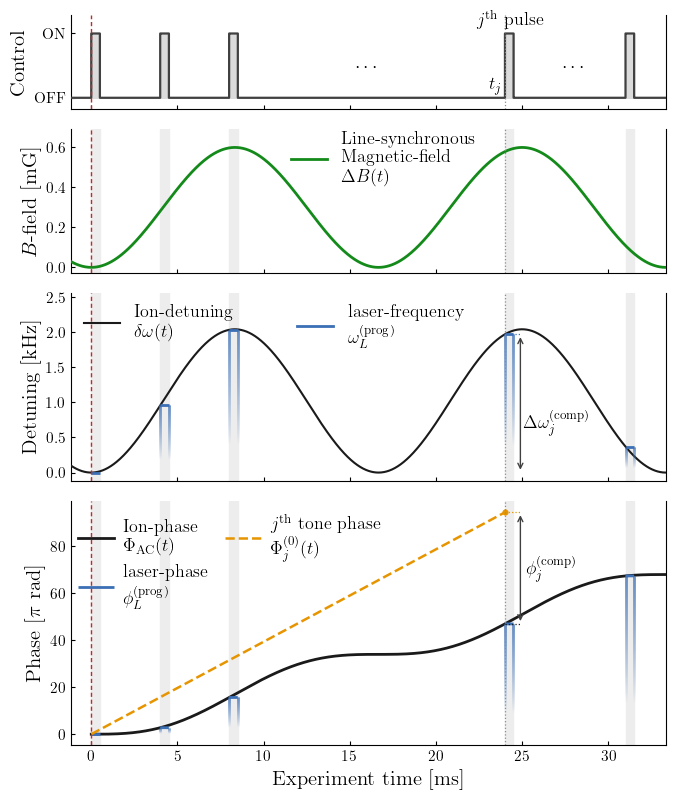

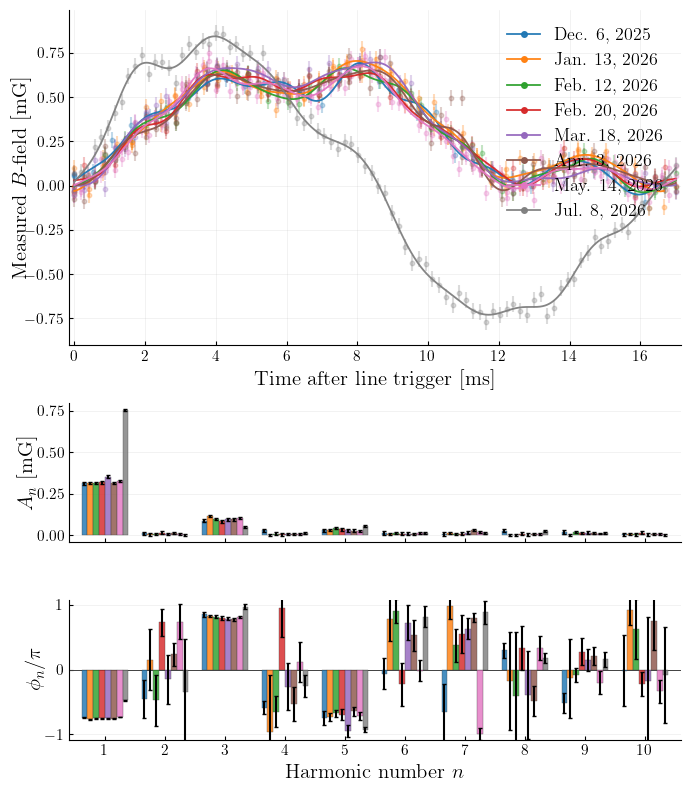

In [7]:
# =========================================================
# FIGURE 1: COMPENSATION PROTOCOL ONLY
# =========================================================
fig_left = plt.figure(figsize=(7.0, 8.2))

gs_left = fig_left.add_gridspec(
    4, 1,
    height_ratios=[0.75, 1.15, 1.50, 1.95],
    hspace=0.12,
)

axs = []
axs.append(fig_left.add_subplot(gs_left[0, 0]))
axs.append(fig_left.add_subplot(gs_left[1, 0], sharex=axs[0]))
axs.append(fig_left.add_subplot(gs_left[2, 0], sharex=axs[0]))
axs.append(fig_left.add_subplot(gs_left[3, 0], sharex=axs[0]))

# ---------------------------------------------------------
# Panel 1: control sequence
# ---------------------------------------------------------
ax = axs[0]

ax.step(t_full_ms, laser_on_full, where="post", color="0.25", lw=1.6, zorder=3)
ax.fill_between(t_full_ms, 0, laser_on_full, step="post", color="0.86", zorder=2)

if SHOW_LINE_TRIGGER:
    ax.step(t_full_ms, trigger_on_full, where="post", color=c_trigger, lw=1.5, zorder=4)
    ax.fill_between(t_full_ms, 0, trigger_on_full, step="post", color=c_trigger_fill, zorder=1)

ax.set_ylim(-0.18, 1.28)
ax.set_yticks([0, 1])
ax.set_yticklabels([r"OFF", r"ON"], fontsize=tick_label_font_size)
ax.set_ylabel(r"Control", fontsize=font_size_col_plots)

for idx, txt in custom_pulse_labels.items():
    if idx == 0:
        x_center = 1e3 * (pulse_times[idx] + 3.5 * pulse_widths[idx])
        ax.text(x_center, 0.85, txt, ha="center", va="bottom", fontsize=annotation_font_size)
    else:
        x_center = 1e3 * (pulse_times[idx] + 0.5 * pulse_widths[idx])
        ax.text(x_center, 1.08, txt, ha="center", va="bottom", fontsize=annotation_font_size)

ax.text(
    1e3 * pulse_times[j_pulse_index] - 0.6,
    0.3,
    r"$t_j$",
    ha="center",
    va="top",
    fontsize=annotation_font_size,
)

for xdot in dot_positions_ms:
    ax.text(xdot, dots_y, r"$\cdots$", ha="center", va="center", fontsize=14)

# ---------------------------------------------------------
# Panel 2: B field
# ---------------------------------------------------------
ax = axs[1]

ax.plot(
    t_full_ms,
    B_t_full,
    color=c_B,
    lw=2.0,
    label="Line-synchronous \n Magnetic-field" + "\n" + r"$\Delta B(t)$",
    zorder=3,
)

ax.set_ylabel(r"$B$-field [mG]", fontsize=font_size_col_plots)
ax.set_ylim(*padded_limits(B_t_full, low_pad=0.05, high_pad=0.15))
ax.tick_params(axis="y", labelsize=tick_label_font_size)
ax.legend(
    loc="upper center",
    bbox_to_anchor=(0.525, 1.1),
    frameon=False,
    fontsize=legend_font_size,
    handlelength=2.0,
)

# ---------------------------------------------------------
# Panel 3: detuning
# ---------------------------------------------------------
ax = axs[2]

ax.plot(
    t_full_ms,
    delta_ion_full,
    color=c_ion,
    lw=1.5,
    label="Ion-detuning" + "\n" + r"$\delta\omega(t)$",
    zorder=3,
)

if SHOW_LASER_ONLY_DURING_PULSES:
    for j, (t0, t1) in enumerate(zip(pulse_times, pulse_ends)):
        if j < first_update_index:
            delta_seg = 0.0
        else:
            delta_seg = delta_pulses[j]

        x0 = 1e3 * t0
        x1 = 1e3 * t1

        y_off = delta_seg * (1.0 - EDGE_FRACTION_TO_ZERO)

        if j == 0:
            label = r"laser-frequency" + "\n" + r"$\omega_L^{(\mathrm{prog})}$"
        else:
            label = None

        draw_laser_segment_with_vertical_gradient(
            ax,
            x0=x0,
            x1=x1,
            y_on_start=delta_seg,
            y_on_end=delta_seg,
            y_off_start=y_off,
            y_off_end=y_off,
            color=c_laser,
            label=label,
            lw=LASER_LW,
            steps=EDGE_GRADIENT_STEPS,
            alpha_min=EDGE_ALPHA_MIN,
            alpha_max=EDGE_ALPHA_MAX,
            gamma=EDGE_GRADIENT_GAMMA,
            zorder=4,
        )

    ylim_data = np.r_[delta_ion_full, [0.0], delta_pulses[first_update_index:]]

else:
    ax.step(
        t_full_ms,
        laser_detuning_full,
        where="post",
        color=c_laser,
        lw=LASER_LW,
        label=r"$\Delta\omega_j^{(\mathrm{comp})}$",
        zorder=4,
    )
    ylim_data = np.r_[delta_ion_full, laser_detuning_full]

# detuning arrow at t_j
x_arrow_det = t_j_ms + 0.9

ax.plot(
    [t_j_ms, x_arrow_det],
    [delta_j, delta_j],
    linestyle=":",
    lw=0.9,
    color=c_laser,
    zorder=6,
)

ax.annotate(
    "",
    xy=(x_arrow_det, delta_j),
    xytext=(x_arrow_det, 0.0),
    arrowprops=dict(arrowstyle="<->", lw=1.0, color="0.25"),
    zorder=7,
)

ax.text(
    x_arrow_det + 0.15,
    0.5 * delta_j - 0.27,
    r"$\Delta\omega_j^{(\mathrm{comp})}$",
    ha="left",
    va="center",
    fontsize=annotation_font_size,
)

ax.set_ylabel(r"Detuning [kHz]", fontsize=font_size_col_plots)
ax.tick_params(axis="y", labelsize=tick_label_font_size)
ax.set_ylim(*padded_limits(ylim_data, low_pad=0.06, high_pad=0.25))

ion_handle = mlines.Line2D(
    [], [],
    color=c_ion,
    lw=1.5,
    label="Ion-detuning" + "\n" + r"$\delta\omega(t)$",
)

laser_handle = mlines.Line2D(
    [], [],
    color=c_laser,
    lw=LASER_LW,
    label="laser-frequency" + "\n" + r"$\omega_L^{(\mathrm{prog})}$",
)

leg_ion = ax.legend(
    handles=[ion_handle],
    loc="upper left",
    bbox_to_anchor=(0.01, 0.98),
    frameon=False,
    fontsize=legend_font_size,
    handlelength=2.0,
    borderaxespad=0.0,
)

ax.add_artist(leg_ion)

ax.legend(
    handles=[laser_handle],
    loc="upper center",
    bbox_to_anchor=(0.52, 0.98),
    frameon=False,
    fontsize=legend_font_size,
    handlelength=2.0,
    borderaxespad=0.0,
)

# ---------------------------------------------------------
# Panel 4: phase
# ---------------------------------------------------------
ax = axs[3]

ax.plot(
    t_ms,
    phi_ion / np.pi,
    color=c_ion,
    lw=2.0,
    label=r"Ion-phase" + "\n" + r"$\Phi_{\mathrm{AC}}(t)$",
    zorder=3,
)

if SHOW_LASER_ONLY_DURING_PULSES:
    label_used = False

    for j, xseg, yseg in pulse_phase_segments:
        x0 = xseg[0]
        x1 = xseg[-1]

        y_on_start = yseg[0]
        y_on_end = yseg[-1]

        y_off_start = y_on_start * (1.0 - EDGE_FRACTION_TO_ZERO)
        y_off_end = y_on_end * (1.0 - EDGE_FRACTION_TO_ZERO)

        label = r"laser-phase" + "\n" + r"$\phi_L^{(\mathrm{prog})}$" if not label_used else None

        draw_laser_segment_with_vertical_gradient(
            ax,
            x0=x0,
            x1=x1,
            y_on_start=y_on_start,
            y_on_end=y_on_end,
            y_off_start=y_off_start,
            y_off_end=y_off_end,
            color=c_laser,
            label=label,
            lw=LASER_LW,
            steps=EDGE_GRADIENT_STEPS,
            alpha_min=EDGE_ALPHA_MIN,
            alpha_max=EDGE_ALPHA_MAX,
            gamma=EDGE_GRADIENT_GAMMA,
            zorder=4,
        )

        label_used = True

else:
    ax.plot(
        phase_t_plot,
        phase_laser_plot / np.pi,
        color=c_laser,
        lw=LASER_LW,
        label=r"$\phi_j^{(\mathrm{prog})}$",
        zorder=4,
    )

ax.plot(
    1e3 * t_for_j_phase,
    phi_j_linear / np.pi,
    color=c_jphase,
    lw=1.8,
    linestyle="--",
    label=r"$j^{\mathrm{th}}$ tone phase" + "\n" + r"$\Phi_j^{(0)}(t)$",
    zorder=5,
)

ax.plot(
    [t_j_ms],
    [phi_j_tone_tj / np.pi],
    marker="o",
    ms=3.4,
    color=c_jphase,
    zorder=6,
)

x_arrow = t_j_ms + 0.9

ax.plot(
    [t_j_ms, x_arrow],
    [phi_ls_tj / np.pi, phi_ls_tj / np.pi],
    linestyle=":",
    lw=0.9,
    color=c_ion,
    zorder=6,
)

ax.plot(
    [t_j_ms, x_arrow],
    [phi_j_tone_tj / np.pi, phi_j_tone_tj / np.pi],
    linestyle=":",
    lw=0.9,
    color=c_jphase,
    zorder=6,
)

ax.annotate(
    "",
    xy=(x_arrow, phi_ls_tj / np.pi),
    xytext=(x_arrow, phi_j_tone_tj / np.pi),
    arrowprops=dict(arrowstyle="<->", lw=1.0, color="0.25"),
    zorder=7,
)

ax.text(
    x_arrow + 0.35,
    0.5 * (phi_ls_tj + phi_j_tone_tj) / np.pi,
    r"$\phi_j^{(\mathrm{comp})}$",
    ha="left",
    va="center",
    fontsize=annotation_font_size,
)

ax.set_ylabel(r"Phase [$\pi$ rad]", fontsize=font_size_col_plots)
ax.tick_params(axis="y", labelsize=tick_label_font_size)
ax.set_xlabel(r"Experiment time [ms]", fontsize=font_size_col_plots)
ax.tick_params(axis="x", labelsize=tick_label_font_size)

ax.legend(
    loc="upper left",
    bbox_to_anchor=(0.00, 0.98),
    frameon=False,
    fontsize=legend_font_size,
    handlelength=2.0,
    ncol=2,
    columnspacing=1.0,
    handletextpad=0.5,
    borderaxespad=0.0,
)

# ---------------------------------------------------------
# Shared styling for left/protocol panels
# ---------------------------------------------------------
for i, ax in enumerate(axs):
    if i > 0:
        for t0, t1 in zip(pulse_times, pulse_ends):
            ax.axvspan(1e3 * t0, 1e3 * t1, color="0.93", zorder=0)

    ax.axvline(0.0, color=c_trigger, lw=1.0, linestyle=(0, (3, 2)), zorder=6)
    ax.axvline(t_j_ms, color=c_tj, lw=0.9, linestyle=":", zorder=6)

    ax.spines["top"].set_visible(False)

for ax in axs:
    ax.set_xlim(t_full_ms[0], t_full_ms[-1])

for ax in axs[:-1]:
    ax.tick_params(axis="x", labelbottom=False)
    ax.set_xlabel("")

axs[-1].set_xlabel(r"Experiment time [ms]", fontsize=font_size_col_plots)

fig_left.subplots_adjust(left=0.13, right=0.98, top=0.98, bottom=0.09)

fig_left.savefig(
    "Presentation_Compensation_Protocol.pdf",
    bbox_inches="tight",
    pad_inches=0.02,
    dpi=300,
)
fig_left.savefig(
    "Presentation_Compensation_Protocol.png",
    bbox_inches="tight",
    pad_inches=0.02,
    dpi=300,
)

plt.show()


# =========================================================
# FIGURE 2: REPRODUCIBILITY + HARMONICS ONLY
# =========================================================
fig_right = plt.figure(figsize=(7.2, 8.2))

gs_right = fig_right.add_gridspec(
    3, 1,
    height_ratios=[2.4, 1.0, 1.0],
    hspace=0.28,
)

ax_repro = fig_right.add_subplot(gs_right[0, 0])
ax_harm_amp = fig_right.add_subplot(gs_right[1, 0])
ax_harm_phase = fig_right.add_subplot(gs_right[2, 0], sharex=ax_harm_amp)

plot_line_signal_reproducibility_panel(ax_repro, line_signal_results)

plot_harmonic_amplitude_panel(
    ax_harm_amp,
    line_signal_results,
    max_n=HARMONIC_PANEL_MAX_N,
)

plot_harmonic_phase_panel(
    ax_harm_phase,
    line_signal_results,
    max_n=HARMONIC_PANEL_MAX_N,
)

ax_harm_amp.tick_params(axis="x", labelbottom=False)

fig_right.subplots_adjust(left=0.13, right=0.98, top=0.98, bottom=0.09)

fig_right.savefig(
    "Presentation_Line_Signal_Reproducibility.pdf",
    bbox_inches="tight",
    pad_inches=0.02,
    dpi=300,
)
fig_right.savefig(
    "Presentation_Line_Signal_Reproducibility.png",
    bbox_inches="tight",
    pad_inches=0.02,
    dpi=300,
)

plt.show()

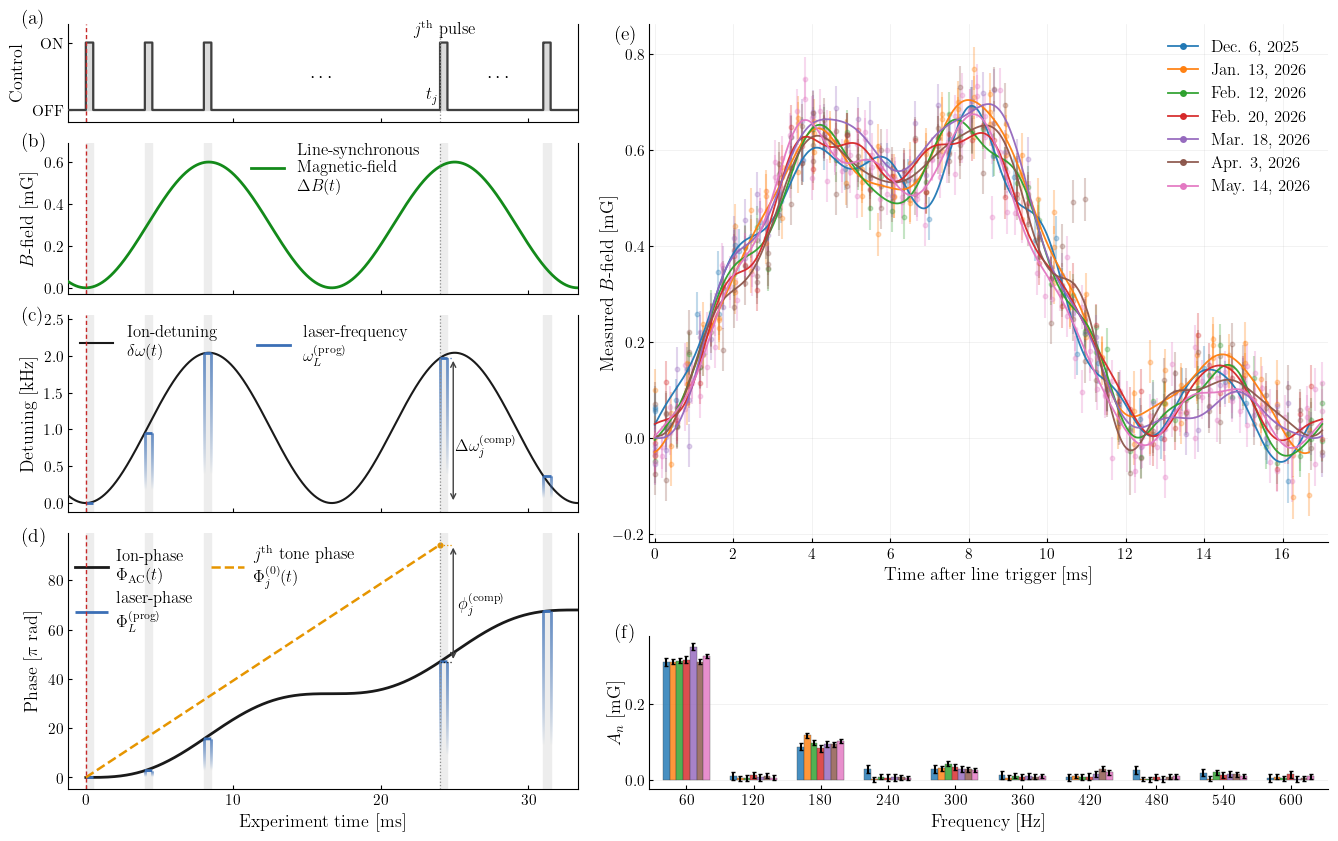

In [18]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.lines as mlines
from scipy.integrate import cumulative_trapezoid
from matplotlib import rcParams
from datetime import datetime


rcParams.update({
    "font.family": "serif",
    "font.serif": ["Computer Modern Roman"],
    "text.usetex": True,
    "font.weight": "bold",
    "axes.labelweight": "bold",
    "axes.titleweight": "bold",
    "text.latex.preamble": r"\usepackage{amsmath}",
    "font.size": 9,
    "axes.linewidth": 0.8,
    "xtick.direction": "in",
    "ytick.direction": "in",
    "xtick.major.size": 3,
    "ytick.major.size": 3,
    "xtick.major.width": 0.8,
    "ytick.major.width": 0.8,
    "savefig.dpi": 300,
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
})

# =========================================================
# TOGGLES / USER SETTINGS
# =========================================================
SHOW_ANNOTATIONS = False
USE_TOY_BFIELD = True
SHOW_LINE_TRIGGER = False

SHOW_LASER_ONLY_DURING_PULSES = True

# Harmonic amplitude panel
HARMONIC_PANEL_MAX_N = 10
HARMONIC_GROUP_WIDTH_HZ = 42.0   # total grouped-bar width around each harmonic frequency

# Gradient edge styling
SHOW_LASER_EDGE_GRADIENT = True
EDGE_GRADIENT_STEPS = 1000
EDGE_ALPHA_MIN = 0.0
EDGE_ALPHA_MAX = 1.0
EDGE_GRADIENT_GAMMA = 1.0
LASER_LW = 2.0

font_size_col_plots = 13
legend_font_size = 12
annotation_font_size = 12
tick_label_font_size = 11

EDGE_FRACTION_TO_ZERO = 0.80
pre_trigger_duration = 1.2e-3   # [s]
trigger_width = 0.35e-3         # [s]

# =========================================================
# GLOBAL PARAMETERS
# =========================================================
fs = 200000
duration = 33330e-6
gamma = 3.4e3   # Hz / mG

# =========================================================
# USER-CONTROLLED PULSE LAYOUT
# =========================================================
pulse_times_ms = [
    0.00,   # reference pulse
    4.00,
    8.00,
    24.00,  # jth pulse
    31.00,  # nth pulse
]

pulse_width_ms = 0.50

j_pulse_index = 3

ref_pulse_index = 0
n_pulse_index = len(pulse_times_ms) - 1

dot_positions_ms = [16.0, 28.0]
dots_y = 0.52

custom_pulse_labels = {
    ref_pulse_index: "",
    j_pulse_index: r"$j^{\mathrm{th}}$ pulse",
    n_pulse_index: "",
}

# First pulse is the reference; compensation updates start from next pulse.
first_update_index = 1

# =========================================================
# CONVERT TO SI UNITS + VALIDATE
# =========================================================
pulse_times = 1e-3 * np.array(pulse_times_ms, dtype=float)

if np.isscalar(pulse_width_ms):
    pulse_widths = np.full(len(pulse_times), 1e-3 * float(pulse_width_ms), dtype=float)
else:
    pulse_widths = 1e-3 * np.array(pulse_width_ms, dtype=float)
    if len(pulse_widths) != len(pulse_times):
        raise ValueError("pulse_width_ms must be a scalar or a list with one entry per pulse.")

pulse_ends = pulse_times + pulse_widths

if len(pulse_times) < 3:
    raise ValueError("Use at least 3 pulses so the schematic can show reference, jth, and nth pulse.")

if np.any(np.diff(pulse_times) < 0):
    raise ValueError("pulse_times_ms must be sorted in increasing order.")

if np.any(pulse_ends > duration):
    raise ValueError("A pulse ends after the total sequence duration.")

if not (0 <= ref_pulse_index < len(pulse_times)):
    raise ValueError("ref_pulse_index is out of range.")

if not (0 <= j_pulse_index < len(pulse_times)):
    raise ValueError("j_pulse_index is out of range.")

if not (0 <= n_pulse_index < len(pulse_times)):
    raise ValueError("n_pulse_index is out of range.")

if ref_pulse_index == j_pulse_index or j_pulse_index == n_pulse_index or ref_pulse_index == n_pulse_index:
    raise ValueError("reference, jth, and nth pulses must be different.")

if not (ref_pulse_index < j_pulse_index < n_pulse_index):
    raise ValueError("Require ref_pulse_index < j_pulse_index < n_pulse_index.")

# =========================================================
# HELPERS
# =========================================================
def padded_limits(y, low_pad=0.08, high_pad=0.08):
    y = np.asarray(y)
    ymin = np.nanmin(y)
    ymax = np.nanmax(y)
    span = ymax - ymin
    if np.isclose(span, 0):
        span = max(abs(ymax), 1.0)
    return ymin - low_pad * span, ymax + high_pad * span


label_box = dict(boxstyle="round,pad=0.20", fc="white", ec="none", alpha=0.92)


def format_date_label(date_string):
    """
    Convert '20251206' to 'Dec. 6, 2025'.
    """
    dt = datetime.strptime(str(date_string), "%Y%m%d")
    month = dt.strftime("%b.")
    return f"{month} {dt.day}, {dt.year}"


def _get_harmonic_results_from_result(result, max_n=10):
    """
    Return harmonic results in the form:
        [(f_hz, A, A_err, phi, phi_err), ...]

    Preferred source:
        result["harmonic_results"]

    Fallback:
        result["params"] from amplitude/phase fit:
        params = [B0, A1, phi1, A2, phi2, ...]
    """
    if "harmonic_results" in result:
        return result["harmonic_results"]

    if "params" not in result:
        raise KeyError(
            "Each result must contain either 'harmonic_results' or 'params'. "
            "Run the line-signal fitting cell that stores harmonic_results first, "
            "or provide amplitude/phase fit params."
        )

    params = np.asarray(result["params"], dtype=float)
    covariance = result.get("covariance", None)

    K_from_params = (len(params) - 1) // 2
    K_use = min(K_from_params, max_n)

    if covariance is not None and np.all(np.isfinite(covariance)):
        param_errors = np.sqrt(np.maximum(np.diag(covariance), 0.0))
    else:
        param_errors = np.full_like(params, np.nan, dtype=float)

    harmonic_results = []
    for i in range(K_use):
        f_hz = 60.0 * (i + 1)

        A_idx = 1 + 2 * i
        phi_idx = A_idx + 1

        A = params[A_idx]
        phi = params[phi_idx]

        A_err = param_errors[A_idx] if A_idx < len(param_errors) else np.nan
        phi_err = param_errors[phi_idx] if phi_idx < len(param_errors) else np.nan

        phi = np.angle(np.exp(1j * phi))

        harmonic_results.append((f_hz, A, A_err, phi, phi_err))

    return harmonic_results


def _extract_harmonic_amplitude_arrays(line_signal_results, max_n=10):
    """
    Extract harmonic amplitudes from line_signal_results.
    """
    if line_signal_results is None or len(line_signal_results) == 0:
        raise ValueError("line_signal_results is empty.")

    frequency_values_hz = 60.0 * np.arange(1, max_n + 1)

    dates = []
    amplitudes = []
    amplitude_errors = []

    for result in line_signal_results:
        dates.append(format_date_label(result["date"]))

        amp = np.full(max_n, np.nan)
        amp_err = np.full(max_n, np.nan)

        harmonic_results = _get_harmonic_results_from_result(result, max_n=max_n)

        for f_hz, A, A_err, phi, phi_err in harmonic_results:
            n = int(np.rint(f_hz / 60.0))
            if 1 <= n <= max_n:
                amp[n - 1] = A
                amp_err[n - 1] = A_err

        amplitudes.append(amp)
        amplitude_errors.append(amp_err)

    return {
        "frequency_values_hz": frequency_values_hz,
        "dates": dates,
        "amplitudes": np.asarray(amplitudes),
        "amplitude_errors": np.asarray(amplitude_errors),
    }


def plot_harmonic_amplitude_panel(ax, line_signal_results, max_n=10):
    data = _extract_harmonic_amplitude_arrays(line_signal_results, max_n=max_n)

    freq_vals = data["frequency_values_hz"]
    dates = data["dates"]
    amplitudes = data["amplitudes"]
    amplitude_errors = data["amplitude_errors"]

    colors = plt.get_cmap("tab10").colors
    n_dates = len(dates)

    bar_width = HARMONIC_GROUP_WIDTH_HZ / max(n_dates, 1)
    offsets = (np.arange(n_dates) - 0.5 * (n_dates - 1)) * bar_width

    for i, date in enumerate(dates):
        yerr = amplitude_errors[i]
        yerr = np.where(np.isfinite(yerr), yerr, 0.0)

        ax.bar(
            freq_vals + offsets[i],
            amplitudes[i],
            width=bar_width,
            yerr=yerr,
            capsize=1.5,
            color=colors[i % len(colors)],
            alpha=0.82,
            linewidth=0.3,
            edgecolor="0.25",
            label=date,
            zorder=3,
        )

    ax.set_xlabel(r"Frequency [Hz]", fontsize=font_size_col_plots)
    ax.set_ylabel(r"$A_n$ [mG]", fontsize=font_size_col_plots, labelpad=0)

    ax.set_xticks(freq_vals)
    ax.set_xlim(freq_vals[0] - 0.8 * HARMONIC_GROUP_WIDTH_HZ,
                freq_vals[-1] + 0.8 * HARMONIC_GROUP_WIDTH_HZ)

    ax.grid(True, axis="y", linewidth=0.45, alpha=0.25)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.tick_params(axis="both", labelsize=tick_label_font_size)


def draw_vertical_alpha_gradient(
    ax,
    x,
    y_transparent,
    y_dark,
    color,
    lw=2.0,
    steps=48,
    alpha_min=0.0,
    alpha_max=1.0,
    gamma=1.0,
    zorder=4,
):
    """
    Draw one vertical edge with alpha gradient.
    The edge is almost transparent near y_transparent and dark near y_dark.
    """
    ys = np.linspace(y_transparent, y_dark, steps + 1)

    for k in range(steps):
        progress = (k + 1) / steps
        alpha = alpha_min + (alpha_max - alpha_min) * progress**gamma

        ax.plot(
            [x, x],
            [ys[k], ys[k + 1]],
            color=color,
            lw=lw,
            alpha=alpha,
            solid_capstyle="butt",
            zorder=zorder,
        )


def draw_laser_segment_with_vertical_gradient(
    ax,
    x0,
    x1,
    y_on_start,
    y_on_end,
    y_off_start,
    y_off_end,
    color,
    label=None,
    lw=2.0,
    steps=48,
    alpha_min=0.0,
    alpha_max=1.0,
    gamma=1.0,
    zorder=4,
):
    """
    Draw a laser-on segment.

    - left edge fades from off -> on
    - middle is dark blue while the laser is on
    - right edge fades from on -> off
    """
    if SHOW_LASER_EDGE_GRADIENT:
        draw_vertical_alpha_gradient(
            ax,
            x0,
            y_off_start,
            y_on_start,
            color,
            lw=lw,
            steps=steps,
            alpha_min=alpha_min,
            alpha_max=alpha_max,
            gamma=gamma,
            zorder=zorder,
        )

    ax.plot(
        [x0, x1],
        [y_on_start, y_on_end],
        color=color,
        lw=lw,
        alpha=alpha_max,
        solid_capstyle="butt",
        label=label,
        zorder=zorder + 1,
    )

    if SHOW_LASER_EDGE_GRADIENT:
        draw_vertical_alpha_gradient(
            ax,
            x1,
            y_off_end,
            y_on_end,
            color,
            lw=lw,
            steps=steps,
            alpha_min=alpha_min,
            alpha_max=alpha_max,
            gamma=gamma,
            zorder=zorder,
        )


def plot_line_signal_reproducibility_panel(ax, line_signal_results):
    """
    Plot reproducibility of the measured line-synchronous magnetic field.
    Requires line_signal_results from the separate reproducibility analysis cell.
    """
    if line_signal_results is None or len(line_signal_results) == 0:
        raise ValueError("line_signal_results is empty. Run the reproducibility analysis cell first.")

    colors = plt.get_cmap("tab10").colors
    handles = []

    for i, result in enumerate(line_signal_results):
        color = colors[i % len(colors)]
        date = format_date_label(result["date"])

        ax.plot(
            result["t_fit_us"] / 1000.0,
            result["B_fit_mG"],
            color=color,
            linewidth=1.3,
            alpha=0.95,
            zorder=3,
        )

        ax.errorbar(
            result["t_us"] / 1000.0,
            result["B_mG"],
            yerr=0.045,
            fmt="o",
            markersize=3.2,
            capsize=0,
            color=color,
            alpha=0.28,
            linestyle="none",
            zorder=2,
        )

        handles.append(
            mlines.Line2D(
                [],
                [],
                color=color,
                marker="o",
                linestyle="-",
                markersize=4.0,
                linewidth=1.3,
                label=date,
                alpha=0.95,
            )
        )

    ax.set_xlabel("Time after line trigger [ms]", fontsize=font_size_col_plots)
    ax.set_ylabel(r"Measured $B$-field [mG]", fontsize=font_size_col_plots, labelpad=-4)
    ax.set_xlim(-0.15, 17.15)
    ax.grid(True, linewidth=0.45, alpha=0.25)

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    ax.legend(
        handles=handles,
        loc="upper right",
        frameon=False,
        fontsize=legend_font_size,
        handlelength=1.8,
        borderpad=0.5,
    )

    ax.tick_params(axis="both", labelsize=tick_label_font_size)


# =========================================================
# TIME AXES
# =========================================================
t_full = np.linspace(
    -pre_trigger_duration,
    duration,
    int(fs * (duration + pre_trigger_duration)),
    endpoint=False
)
t_full_ms = 1e3 * t_full

t = np.linspace(0, duration, int(fs * duration), endpoint=False)
t_ms = 1e3 * t

# =========================================================
# FIELD / DETUNING
# =========================================================
if USE_TOY_BFIELD:
    B_t_full = -0.3 * np.cos(2 * np.pi * 60 * t_full) + 0.3
else:
    B_t_full = B_rel_line_mG(t_full)

# Reference to line trigger at t=0
B_t_full = B_t_full - np.interp(0.0, t_full, B_t_full)

delta_ion_full = gamma * B_t_full / 1000   # [kHz]

B_t = np.interp(t, t_full, B_t_full)
delta_ion = gamma * B_t / 1000   # [kHz]
phi_ion = 2 * np.pi * cumulative_trapezoid(1000 * delta_ion, t, initial=0)   # [rad]

delta_pulses = np.interp(pulse_times, t, delta_ion)
phi_pulses = np.interp(pulse_times, t, phi_ion)

# =========================================================
# CONTINUOUS CONCEPTUAL LASER DETUNING
# =========================================================
laser_detuning_full = np.zeros_like(t_full)

for j in range(first_update_index, len(pulse_times)):
    t0 = pulse_times[j]
    t1 = pulse_times[j + 1] if j + 1 < len(pulse_times) else duration
    if j + 1 < len(pulse_times):
        mask = (t_full >= t0) & (t_full < t1)
    else:
        mask = (t_full >= t0) & (t_full <= t1)
    laser_detuning_full[mask] = delta_pulses[j]

# =========================================================
# CONTINUOUS CONCEPTUAL PROGRAMMED PHASE
# =========================================================
phase_t_plot = [0.0]
phase_laser_plot = [0.0]

current_t = 0.0
current_phi = 0.0
current_detuning = 0.0

update_times = pulse_times[first_update_index:]

for k, t_update in enumerate(update_times):
    phi_before = current_phi + 2 * np.pi * current_detuning * (t_update - current_t)

    phase_t_plot.extend([t_update])
    phase_laser_plot.extend([phi_before])

    pulse_idx = first_update_index + k
    phi_snap = phi_pulses[pulse_idx]

    phase_t_plot.extend([t_update])
    phase_laser_plot.extend([phi_snap])

    current_t = t_update
    current_phi = phi_snap
    current_detuning = delta_pulses[pulse_idx]

phi_end = current_phi + 2 * np.pi * current_detuning * (duration - current_t)
phase_t_plot.extend([duration])
phase_laser_plot.extend([phi_end])

phase_t_plot = 1e3 * np.array(phase_t_plot)   # [ms]
phase_laser_plot = np.array(phase_laser_plot) # [rad]

# =========================================================
# PULSE-ONLY LASER PHASE SEGMENTS
# =========================================================
pulse_phase_segments = []

for j, (t0, t1) in enumerate(zip(pulse_times, pulse_ends)):
    if j < first_update_index:
        delta_seg = 0.0
        phi_start_seg = 0.0
    else:
        delta_seg = delta_pulses[j]
        phi_start_seg = phi_pulses[j]

    nseg = max(40, int(fs * (t1 - t0)))
    t_seg = np.linspace(t0, t1, nseg, endpoint=True)
    phi_seg = phi_start_seg + 2 * np.pi * delta_seg * (t_seg - t0)

    pulse_phase_segments.append((j, 1e3 * t_seg, phi_seg / np.pi))

# =========================================================
# JTH-TONE LINEAR PHASE IN THE omega_0 FRAME
# =========================================================
t_j = pulse_times[j_pulse_index]
t_j_ms = 1e3 * t_j
delta_j = delta_pulses[j_pulse_index]

mask_j = t <= t_j
t_for_j_phase = t[mask_j]
phi_j_linear = 2 * np.pi * 1000 * delta_j * t_for_j_phase   # [rad]

phi_ls_tj = np.interp(t_j, t, phi_ion)                      # [rad]
phi_j_tone_tj = 2 * np.pi * 1000 * delta_j * t_j             # [rad]

# =========================================================
# CONTROL PANEL SIGNALS
# =========================================================
laser_on_full = np.zeros_like(t_full)
for t0, t1 in zip(pulse_times, pulse_ends):
    laser_on_full[(t_full >= t0) & (t_full < t1)] = 1

trigger_on_full = np.zeros_like(t_full)
trigger_on_full[(t_full >= -trigger_width) & (t_full < 0)] = 1

# =========================================================
# COLORS
# =========================================================
c_B = "#138A1A"
c_ion = "0.10"
c_laser = "#3B6FB6"
c_jphase = "#E69500"
c_trigger = "#C62828"
c_trigger_fill = "#F3C7C7"
c_tj = "0.55"

# =========================================================
# PLOT LAYOUT
# =========================================================
fig = plt.figure(figsize=(14, 8.6))

gs = fig.add_gridspec(
    4, 2,
    width_ratios=[0.75, 1.0],
    height_ratios=[0.75, 1.15, 1.50, 1.95],
    hspace=0.12,
    wspace=0.12,
)

axs = []
axs.append(fig.add_subplot(gs[0, 0]))
axs.append(fig.add_subplot(gs[1, 0], sharex=axs[0]))
axs.append(fig.add_subplot(gs[2, 0], sharex=axs[0]))
axs.append(fig.add_subplot(gs[3, 0], sharex=axs[0]))

# Right column: reproducibility + harmonic amplitude only.
# The amplitude panel keeps the same relative size as before.
# The reproducibility plot expands into the space left by removing the phase panel.
right_gs = gs[:, 1].subgridspec(
    2, 1,
    height_ratios=[3.4, 1.0],
    hspace=0.28,
)

ax_repro = fig.add_subplot(right_gs[0, 0])
ax_harm_amp = fig.add_subplot(right_gs[1, 0])

# ---------------------------------------------------------
# Panel 1: control sequence
# ---------------------------------------------------------
ax = axs[0]

ax.step(t_full_ms, laser_on_full, where="post", color="0.25", lw=1.6, zorder=3)
ax.fill_between(t_full_ms, 0, laser_on_full, step="post", color="0.86", zorder=2)

if SHOW_LINE_TRIGGER:
    ax.step(t_full_ms, trigger_on_full, where="post", color=c_trigger, lw=1.5, zorder=4)
    ax.fill_between(t_full_ms, 0, trigger_on_full, step="post", color=c_trigger_fill, zorder=1)

ax.set_ylim(-0.18, 1.28)
ax.set_yticks([0, 1])
ax.set_yticklabels([r"OFF", r"ON"], fontsize=tick_label_font_size)
ax.set_ylabel(r"Control", fontsize=font_size_col_plots)

for idx, txt in custom_pulse_labels.items():
    if idx == 0:
        x_center = 1e3 * (pulse_times[idx] + 3.5 * pulse_widths[idx])
        ax.text(x_center, 0.85, txt, ha="center", va="bottom", fontsize=annotation_font_size)
    else:
        x_center = 1e3 * (pulse_times[idx] + 0.5 * pulse_widths[idx])
        ax.text(x_center, 1.08, txt, ha="center", va="bottom", fontsize=annotation_font_size)

ax.text(
    1e3 * pulse_times[j_pulse_index] - 0.6,
    0.3,
    r"$t_j$",
    ha="center",
    va="top",
    fontsize=annotation_font_size,
)

for xdot in dot_positions_ms:
    ax.text(xdot, dots_y, r"$\cdots$", ha="center", va="center", fontsize=14)

# ---------------------------------------------------------
# Panel 2: B field
# ---------------------------------------------------------
ax = axs[1]

ax.plot(
    t_full_ms,
    B_t_full,
    color=c_B,
    lw=2.0,
    label="Line-synchronous \n Magnetic-field" + "\n" + r"$\Delta B(t)$",
    zorder=3,
)

ax.set_ylabel(r"$B$-field [mG]", fontsize=font_size_col_plots)
ax.set_ylim(*padded_limits(B_t_full, low_pad=0.05, high_pad=0.15))
ax.tick_params(axis="y", labelsize=tick_label_font_size)
ax.legend(
    loc="upper center",
    bbox_to_anchor=(0.525, 1.1),
    frameon=False,
    fontsize=legend_font_size,
    handlelength=2.0,
)

# ---------------------------------------------------------
# Panel 3: detuning
# ---------------------------------------------------------
ax = axs[2]

ax.plot(
    t_full_ms,
    delta_ion_full,
    color=c_ion,
    lw=1.5,
    label="Ion-detuning" + "\n" + r"$\delta\omega(t)$",
    zorder=3,
)

if SHOW_LASER_ONLY_DURING_PULSES:
    label_used = False

    for j, (t0, t1) in enumerate(zip(pulse_times, pulse_ends)):
        if j < first_update_index:
            delta_seg = 0.0
        else:
            delta_seg = delta_pulses[j]

        x0 = 1e3 * t0
        x1 = 1e3 * t1

        y_off = delta_seg * (1.0 - EDGE_FRACTION_TO_ZERO)

        if j == 0:
            label = r"laser-frequency" + "\n" + r"$\omega_L^{(\mathrm{prog})}$"
        else:
            label = None

        draw_laser_segment_with_vertical_gradient(
            ax,
            x0=x0,
            x1=x1,
            y_on_start=delta_seg,
            y_on_end=delta_seg,
            y_off_start=y_off,
            y_off_end=y_off,
            color=c_laser,
            label=label,
            lw=LASER_LW,
            steps=EDGE_GRADIENT_STEPS,
            alpha_min=EDGE_ALPHA_MIN,
            alpha_max=EDGE_ALPHA_MAX,
            gamma=EDGE_GRADIENT_GAMMA,
            zorder=4,
        )

        label_used = True

    ylim_data = np.r_[delta_ion_full, [0.0], delta_pulses[first_update_index:]]

else:
    ax.step(
        t_full_ms,
        laser_detuning_full,
        where="post",
        color=c_laser,
        lw=LASER_LW,
        label=r"$\Delta\omega_j^{(\mathrm{comp})}$",
        zorder=4,
    )
    ylim_data = np.r_[delta_ion_full, laser_detuning_full]

# detuning arrow at t_j
x_arrow_det = t_j_ms + 0.9

ax.plot(
    [t_j_ms, x_arrow_det],
    [delta_j, delta_j],
    linestyle=":",
    lw=0.9,
    color=c_laser,
    zorder=6,
)

ax.annotate(
    "",
    xy=(x_arrow_det, delta_j),
    xytext=(x_arrow_det, 0.0),
    arrowprops=dict(arrowstyle="<->", lw=1.0, color="0.25"),
    zorder=7,
)

ax.text(
    x_arrow_det + 0.15,
    0.5 * delta_j - 0.2,
    r"$\Delta\omega_j^{(\mathrm{comp})}$",
    ha="left",
    va="center",
    fontsize=annotation_font_size,
)

ax.set_ylabel(r"Detuning [kHz]", fontsize=font_size_col_plots)
ax.tick_params(axis="y", labelsize=tick_label_font_size)
ax.set_ylim(*padded_limits(ylim_data, low_pad=0.06, high_pad=0.25))

# Split panel (c) legend into two separate legends
ion_handle = mlines.Line2D(
    [],
    [],
    color=c_ion,
    lw=1.5,
    label="Ion-detuning" + "\n" + r"$\delta\omega(t)$",
)

laser_handle = mlines.Line2D(
    [],
    [],
    color=c_laser,
    lw=LASER_LW,
    label="laser-frequency" + "\n" + r"$\omega_L^{(\mathrm{prog})}$",
)

leg_ion = ax.legend(
    handles=[ion_handle],
    loc="upper left",
    bbox_to_anchor=(0.01, 0.98),
    frameon=False,
    fontsize=legend_font_size,
    handlelength=2.0,
    borderaxespad=0.0,
)

ax.add_artist(leg_ion)

ax.legend(
    handles=[laser_handle],
    loc="upper center",
    bbox_to_anchor=(0.52, 0.98),
    frameon=False,
    fontsize=legend_font_size,
    handlelength=2.0,
    borderaxespad=0.0,
)

# ---------------------------------------------------------
# Panel 4: phase
# ---------------------------------------------------------
ax = axs[3]

ax.plot(
    t_ms,
    phi_ion / np.pi,
    color=c_ion,
    lw=2.0,
    label=r"Ion-phase" + "\n" + r"$\Phi_{\mathrm{AC}}(t)$",
    zorder=3,
)

if SHOW_LASER_ONLY_DURING_PULSES:
    label_used = False

    for j, xseg, yseg in pulse_phase_segments:
        x0 = xseg[0]
        x1 = xseg[-1]

        y_on_start = yseg[0]
        y_on_end = yseg[-1]

        y_off_start = y_on_start * (1.0 - EDGE_FRACTION_TO_ZERO)
        y_off_end = y_on_end * (1.0 - EDGE_FRACTION_TO_ZERO)

        label = r"laser-phase" + "\n" + r"$\Phi_L^{(\mathrm{prog})}$" if not label_used else None

        draw_laser_segment_with_vertical_gradient(
            ax,
            x0=x0,
            x1=x1,
            y_on_start=y_on_start,
            y_on_end=y_on_end,
            y_off_start=y_off_start,
            y_off_end=y_off_end,
            color=c_laser,
            label=label,
            lw=LASER_LW,
            steps=EDGE_GRADIENT_STEPS,
            alpha_min=EDGE_ALPHA_MIN,
            alpha_max=EDGE_ALPHA_MAX,
            gamma=EDGE_GRADIENT_GAMMA,
            zorder=4,
        )

        label_used = True

else:
    ax.plot(
        phase_t_plot,
        phase_laser_plot / np.pi,
        color=c_laser,
        lw=LASER_LW,
        label=r"$\phi_j^{(\mathrm{prog})}$",
        zorder=4,
    )

ax.plot(
    1e3 * t_for_j_phase,
    phi_j_linear / np.pi,
    color=c_jphase,
    lw=1.8,
    linestyle="--",
    label=r"$j^{\mathrm{th}}$ tone phase" + "\n" + r"$\Phi_j^{(0)}(t)$",
    zorder=5,
)

ax.plot(
    [t_j_ms],
    [phi_j_tone_tj / np.pi],
    marker="o",
    ms=3.4,
    color=c_jphase,
    zorder=6,
)

# phase-compensation arrow
x_arrow = t_j_ms + 0.9

ax.plot(
    [t_j_ms, x_arrow],
    [phi_ls_tj / np.pi, phi_ls_tj / np.pi],
    linestyle=":",
    lw=0.9,
    color=c_ion,
    zorder=6,
)

ax.plot(
    [t_j_ms, x_arrow],
    [phi_j_tone_tj / np.pi, phi_j_tone_tj / np.pi],
    linestyle=":",
    lw=0.9,
    color=c_jphase,
    zorder=6,
)

ax.annotate(
    "",
    xy=(x_arrow, phi_ls_tj / np.pi),
    xytext=(x_arrow, phi_j_tone_tj / np.pi),
    arrowprops=dict(arrowstyle="<->", lw=1.0, color="0.25"),
    zorder=7,
)

ax.text(
    x_arrow + 0.35,
    0.5 * (phi_ls_tj + phi_j_tone_tj) / np.pi,
    r"$\phi_j^{(\mathrm{comp})}$",
    ha="left",
    va="center",
    fontsize=annotation_font_size,
)

ax.set_ylabel(r"Phase [$\pi$ rad]", fontsize=font_size_col_plots)
ax.tick_params(axis="y", labelsize=tick_label_font_size)
ax.set_xlabel(r"Experiment time [ms]", fontsize=font_size_col_plots)
ax.tick_params(axis="x", labelsize=tick_label_font_size)

ax.legend(
    loc="upper left",
    bbox_to_anchor=(0.00, 0.98),
    frameon=False,
    fontsize=legend_font_size,
    handlelength=2.0,
    ncol=2,
    columnspacing=1.0,
    handletextpad=0.5,
    borderaxespad=0.0,
)

# ---------------------------------------------------------
# Right-column panels: reproducibility and harmonic amplitude
# ---------------------------------------------------------
plot_line_signal_reproducibility_panel(ax_repro, line_signal_results)

plot_harmonic_amplitude_panel(
    ax_harm_amp,
    line_signal_results,
    max_n=HARMONIC_PANEL_MAX_N,
)

# =========================================================
# SHARED STYLING FOR LEFT PANELS
# =========================================================
for i, ax in enumerate(axs):
    if i > 0:
        for t0, t1 in zip(pulse_times, pulse_ends):
            ax.axvspan(1e3 * t0, 1e3 * t1, color="0.93", zorder=0)

    ax.axvline(0.0, color=c_trigger, lw=1.0, linestyle=(0, (3, 2)), zorder=6)
    ax.axvline(t_j_ms, color=c_tj, lw=0.9, linestyle=":", zorder=6)

    ax.spines["top"].set_visible(False)

    ax.text(
        -0.09,
        0.95,
        f"({chr(ord('a') + i)})",
        transform=ax.transAxes,
        fontsize=14,
        fontweight="bold",
        va="bottom",
    )

for ax in axs:
    ax.set_xlim(t_full_ms[0], t_full_ms[-1])

# Right-column panel labels
for ax_label, label in [
    (ax_repro, "(e)"),
    (ax_harm_amp, "(f)"),
]:
    ax_label.text(
        -0.05,
        0.96,
        label,
        transform=ax_label.transAxes,
        fontsize=14,
        fontweight="bold",
        va="bottom",
    )

# Hide x-axis tick labels on upper left-column panels
for ax in axs[:-1]:
    ax.tick_params(axis="x", labelbottom=False)
    ax.set_xlabel("")

axs[-1].set_xlabel(r"Experiment time [ms]", fontsize=font_size_col_plots)

# =========================================================
# OPTIONAL ANNOTATIONS
# =========================================================
if SHOW_ANNOTATIONS:
    axs[3].annotate(
        r"$t_j\,\delta\omega(t_j)$ in the $\omega_0$ frame",
        xy=(t_j_ms, phi_j_tone_tj / np.pi),
        xytext=(t_j_ms - 8.0, phi_j_tone_tj / np.pi - 8),
        arrowprops=dict(arrowstyle="->", lw=0.8, color=c_jphase),
        fontsize=10,
        bbox=label_box,
    )

# =========================================================
# SAVE
# =========================================================
plt.subplots_adjust(left=0.08, right=0.98, top=0.98, bottom=0.09)

plt.savefig(
    "Line_signal_Compensation_Figure1_with_reproducibility_and_harmonic_amplitudes.pdf",
    bbox_inches="tight",
    pad_inches=0.0,
    dpi=300,
)

# plt.savefig(
#     "Line_signal_Compensation_Figure1_with_reproducibility_and_harmonic_amplitudes.svg",
#     bbox_inches="tight",
#     pad_inches=0.0,
# )
# plt.savefig(
#     "Line_signal_Compensation_Figure1_with_reproducibility_and_harmonic_amplitudes.png",
#     bbox_inches="tight",
#     pad_inches=0.0,
#     dpi=900,
# )

plt.show()